# 18 — Diffusion Uncertainty Analysis

**Origin:** Existing Previous Version of Notebook 27, Pre-refactor  
**Refactor status:** Finished                   
**Validation status:** Finished        
**Completion gate passed:** Yes             
**Output root:** `outputs/18_diffusion_uncertainty_analysis/`  
**Depends on:** Notebooks 01, 02, 08, 11–15, 17, and conditional Notebook 12

## Purpose

Measure empirical repeated-seed variability for completed diffusion restoration candidates without running restoration inference.

The primary evidence population consists of Stable Diffusion candidates grouped by:

- restoration case;
- prompt policy;
- prompt variant;
- generation configuration.

Every eligible group must contain exactly seeds `2026`, `2027`, `2028`, and `2029`. Prompt variants are never mixed inside an uncertainty group.

## Approved evidence population

- 480 unique restoration cases;
- 780 prompt-specific uncertainty groups;
- 3,120 Stable Diffusion candidates;
- four candidates per group;
- 4,680 unique unordered seed pairs;
- 480 generic-prompt groups;
- 300 scratch-aware-prompt groups.

The 300 scratch-aware groups are paired with generic-prompt groups
for the same scratch cases.

SDXL completed 24 of 35 bounded attempts but has only one seed per completed case. It is recorded as `not_applicable_insufficient_seed_coverage`, not assigned uncertainty values.

OpenCV Telea, LaMa, and HINT are deterministic methods. Their analyses use robustness or sensitivity terminology rather than diffusion uncertainty.

## Transparent uncertainty components

The notebook computes:

- per-pixel RGB standard deviation across seeds;
- pairwise RGB MAE and RMSE;
- pairwise LPIPS distance;
- pairwise CLIP cosine distance;
- pairwise DINOv2 cosine distance;
- seed-level reference, perceptual, feature, texture, colour, and seam evidence.

Pixel-space evidence covers:

- full image;
- content region;
- masked region;
- mask-bounding-box crop;
- boundary ring;
- outside-mask content.

LPIPS, CLIP, and DINOv2 use the contiguous `content_region` and `mask_bbox_crop` regions approved by the canonical region policy.

No combined uncertainty index is retained. Scaling and weighting cannot be justified before later semantic, human-review, and failure-category evidence is available.

## Interpretation limits

Uncertainty is an empirical seed-variability proxy, not calibrated confidence.

Low uncertainty means that repeated candidates are similar to one another. It does not establish that those candidates are correct, historically plausible, visually acceptable, or conservation appropriate.

Notebook 18 persists scalar and pairwise evidence only. Notebook 19 owns numeric uncertainty maps, heatmaps, and spatial overlays.

## Canonical outputs

- `metrics/uncertainty_metrics.csv`
- `metrics/uncertainty_calibration_inputs.csv`
- `figures/uncertainty_distributions.png`
- `figures/uncertainty_vs_performance.png`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

Notebook 18 does not generate a standalone HTML or Markdown report.

In [1]:
from pathlib import Path
import json
import platform
import sys

import matplotlib
import numpy as np
import pandas as pd
import PIL
import torch
import yaml
from IPython.display import display


# ---------------------------------------------------------------------------
# Minimal repository bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in (
        CURRENT_DIRECTORY,
        *CURRENT_DIRECTORY.parents,
    )
    if (
        (candidate / ".git").exists()
        and (
            candidate
            / "src"
            / "restoration_eval"
        ).is_dir()
        and (candidate / "notebooks").is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration repository root "
        f"from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SOURCE_DIRECTORY = PROJECT_ROOT / "src"

if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(
        0,
        str(SOURCE_DIRECTORY),
    )


# ---------------------------------------------------------------------------
# Versioned project helpers
# ---------------------------------------------------------------------------

from restoration_eval import (
    __version__ as PACKAGE_VERSION,
)

from restoration_eval.diffusion_uncertainty import (
    DIFFUSION_UNCERTAINTY_METRIC_VERSION,
    DIFFUSION_UNCERTAINTY_MODULE_VERSION,
    DIFFUSION_UNCERTAINTY_SCHEMA_VERSION,
    UNCERTAINTY_CALIBRATION_SCHEMA_VERSION,
    load_diffusion_uncertainty_config,
)

from restoration_eval.evaluation_inputs import (
    EVALUATION_INPUTS_MODULE_VERSION,
    EVALUATION_WORKLIST_SCHEMA_VERSION,
)

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_file,
    utc_now_iso,
)

from restoration_eval.metrics_feature_similarity import (
    FEATURE_EMBEDDING_SCHEMA_VERSION,
    FEATURE_SIMILARITY_MODULE_VERSION,
)

from restoration_eval.metrics_lpips import (
    LPIPS_MODULE_VERSION,
    LPIPS_SCHEMA_VERSION,
    validate_lpips_runtime_dependencies,
)

from restoration_eval.paths import (
    PATHS_MODULE_VERSION,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    resolve_repo_path,
    to_repo_relative,
    validate_project_paths_registry,
)

from restoration_eval.regions import (
    REGIONS_MODULE_VERSION,
)

from restoration_eval.schemas import (
    DIFFUSION_UNCERTAINTY_SCHEMA,
    SCHEMAS_MODULE_VERSION,
    UNCERTAINTY_CALIBRATION_INPUTS_SCHEMA,
    get_schema,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook identity and owned directories
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "18"
NOTEBOOK_STEM = "18_diffusion_uncertainty_analysis"

SUPPORTED_PYTHON_MINORS = {
    (3, 11),
    (3, 12),
}

RUN_STARTED_AT_UTC = utc_now_iso()

NOTEBOOK_OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

OUTPUT_DIRECTORIES = ensure_output_subdirs(
    NOTEBOOK_STEM,
    (
        "metrics",
        "figures",
        "manifests",
        "validation",
        "work",
    ),
    PROJECT_ROOT,
)

print("Notebook 18 repository bootstrap complete.")
print("Project root:", PROJECT_ROOT)
print("Notebook output root:", NOTEBOOK_OUTPUT_ROOT)
print("Package version:", PACKAGE_VERSION)
print(
    "Diffusion-uncertainty helper:",
    DIFFUSION_UNCERTAINTY_MODULE_VERSION,
)
print(
    "Uncertainty metric version:",
    DIFFUSION_UNCERTAINTY_METRIC_VERSION,
)
print(
    "Uncertainty schema:",
    DIFFUSION_UNCERTAINTY_SCHEMA_VERSION,
)
print(
    "Calibration schema:",
    UNCERTAINTY_CALIBRATION_SCHEMA_VERSION,
)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Run started at UTC:", RUN_STARTED_AT_UTC)

Notebook 18 repository bootstrap complete.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Notebook output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\18_diffusion_uncertainty_analysis
Package version: 0.1.0
Diffusion-uncertainty helper: 1.0.3
Uncertainty metric version: empirical_seed_uncertainty.v1
Uncertainty schema: diffusion_uncertainty.v1
Calibration schema: uncertainty_calibration_inputs.v1
Torch version: 2.5.1+cu121
CUDA available: True
Run started at UTC: 2026-09-17T22:40:07.009610Z


In [2]:
# ---------------------------------------------------------------------------
# Governing paths
# ---------------------------------------------------------------------------

UNCERTAINTY_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "diffusion_uncertainty.yaml"
)

NOTEBOOK_ROADMAP_PATH = (
    PROJECT_ROOT
    / "docs"
    / "final_notebook_roadmap.md"
)

IMPLEMENTATION_GUIDELINES_PATH = (
    PROJECT_ROOT
    / "docs"
    / "refactoring_implementation_guidelines.md"
)

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / f"{NOTEBOOK_STEM}.ipynb"
)

HELPER_PATHS = {
    "diffusion_uncertainty_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "diffusion_uncertainty.py"
    ),
    "evaluation_inputs_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "evaluation_inputs.py"
    ),
    "lpips_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "metrics_lpips.py"
    ),
    "feature_similarity_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "metrics_feature_similarity.py"
    ),
    "regions_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "regions.py"
    ),
    "schemas_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "schemas.py"
    ),
    "paths_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "paths.py"
    ),
    "manifests_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "manifests.py"
    ),
    "validation_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "validation.py"
    ),
}


# ---------------------------------------------------------------------------
# Versioned Notebook 18 configuration
# ---------------------------------------------------------------------------

UNCERTAINTY_CONFIG_DOCUMENT = (
    load_diffusion_uncertainty_config(
        UNCERTAINTY_CONFIG_PATH
    )
)

UNCERTAINTY_CONFIG = (
    UNCERTAINTY_CONFIG_DOCUMENT[
        "diffusion_uncertainty"
    ]
)

CONFIG_SCHEMA_VERSION = (
    UNCERTAINTY_CONFIG_DOCUMENT[
        "config_schema_version"
    ]
)

CONFIGURED_INPUTS = UNCERTAINTY_CONFIG["inputs"]
CONFIGURED_OUTPUTS = UNCERTAINTY_CONFIG["output"]
EXPECTED_COUNTS = UNCERTAINTY_CONFIG["expected_counts"]
POPULATION_POLICY = UNCERTAINTY_CONFIG["population"]
REGION_POLICY = UNCERTAINTY_CONFIG["regions"]
METRIC_POLICY = UNCERTAINTY_CONFIG["metrics"]
CALIBRATION_POLICY = UNCERTAINTY_CONFIG["calibration"]
EXECUTION_POLICY = UNCERTAINTY_CONFIG["execution"]
EVIDENCE_POLICY = UNCERTAINTY_CONFIG["evidence_policy"]

if UNCERTAINTY_CONFIG["notebook_id"] != NOTEBOOK_ID:
    raise ValueError(
        "Configured notebook ID disagrees with Notebook 18."
    )

if UNCERTAINTY_CONFIG["notebook_stem"] != NOTEBOOK_STEM:
    raise ValueError(
        "Configured notebook stem disagrees with Notebook 18."
    )

if CONFIGURED_OUTPUTS["root"] != f"outputs/{NOTEBOOK_STEM}":
    raise ValueError(
        "Configured output root violates Notebook 18 ownership."
    )


# ---------------------------------------------------------------------------
# Explicit input paths
# ---------------------------------------------------------------------------

INPUTS = {
    key: resolve_repo_path(
        configured_path,
        PROJECT_ROOT,
        must_exist=True,
    )
    for key, configured_path in (
        CONFIGURED_INPUTS.items()
    )
}


# ---------------------------------------------------------------------------
# Canonical and temporary output paths
# ---------------------------------------------------------------------------

OUTPUTS = {
    "uncertainty_metrics": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["metrics_path"]
    ),
    "calibration_inputs": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS[
            "calibration_inputs_path"
        ]
    ),
    "uncertainty_distributions": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS[
            "distributions_figure_path"
        ]
    ),
    "uncertainty_vs_performance": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS[
            "performance_figure_path"
        ]
    ),
    "run_manifest": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["run_manifest_path"]
    ),
    "artifacts": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["artifacts_path"]
    ),
    "validation": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["validation_path"]
    ),
}

WORK_PATHS = {
    "image_checkpoint": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS[
            "image_checkpoint_path"
        ]
    ),
    "lpips_checkpoint": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS[
            "lpips_checkpoint_path"
        ]
    ),
}


# ---------------------------------------------------------------------------
# Provenance paths and checksums
# ---------------------------------------------------------------------------

GOVERNING_PATHS = {
    "notebook_roadmap": NOTEBOOK_ROADMAP_PATH,
    "implementation_guidelines": (
        IMPLEMENTATION_GUIDELINES_PATH
    ),
    "notebook": NOTEBOOK_PATH,
}

CONFIGURATION_PATHS = {
    "diffusion_uncertainty": (
        UNCERTAINTY_CONFIG_PATH
    ),
    "lpips": INPUTS["lpips_config_path"],
    "evaluation_contract": (
        INPUTS["evaluation_contract_config_path"]
    ),
}

CONFIGURATION_CHECKSUMS = {
    key: sha256_file(path)
    for key, path in CONFIGURATION_PATHS.items()
}

HELPER_CHECKSUMS = {
    key: sha256_file(path)
    for key, path in HELPER_PATHS.items()
}

print("Notebook 18 paths and configuration loaded.")
print("Declared inputs:", len(INPUTS))
print("Declared canonical outputs:", len(OUTPUTS))
print("Declared work paths:", len(WORK_PATHS))
print(
    "Expected uncertainty groups:",
    EXPECTED_COUNTS["uncertainty_groups"],
)
print(
    "Expected uncertainty metric rows:",
    EXPECTED_COUNTS["uncertainty_metric_rows"],
)
print(
    "Combined index retained:",
    METRIC_POLICY["combined_index"]["retained"],
)

Notebook 18 paths and configuration loaded.
Declared inputs: 29
Declared canonical outputs: 7
Declared work paths: 2
Expected uncertainty groups: 780
Expected uncertainty metric rows: 124800
Combined index retained: False


In [3]:
# ---------------------------------------------------------------------------
# Inventory and project-path registry
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(
    INPUTS["inventory_path"],
    low_memory=False,
)

with INPUTS["inventory_run_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    inventory_run = json.load(handle)

project_paths_registry = load_project_paths_registry(
    PROJECT_ROOT
)

with INPUTS["schema_registry_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    upstream_schema_registry = json.load(handle)

inventory_relative_paths = set(
    inventory_df["relative_path"].astype(str)
)

registry_artifacts = {
    record["artifact_key"]: record
    for record in project_paths_registry["artifacts"]
}


# ---------------------------------------------------------------------------
# Upstream run manifests
# ---------------------------------------------------------------------------

UPSTREAM_MANIFEST_KEYS = {
    "notebook_01": "artworks_run_manifest_path",
    "notebook_02": "geometry_run_manifest_path",
    "notebook_08": "contracts_run_manifest_path",
    "notebook_11": (
        "stable_diffusion_run_manifest_path"
    ),
    "notebook_12": "sdxl_run_manifest_path",
    "notebook_13": "classical_run_manifest_path",
    "notebook_14": "lpips_run_manifest_path",
    "notebook_15": "feature_run_manifest_path",
    "notebook_17": (
        "local_consistency_run_manifest_path"
    ),
}

upstream_manifests = {}

for producer, input_key in (
    UPSTREAM_MANIFEST_KEYS.items()
):
    with INPUTS[input_key].open(
        "r",
        encoding="utf-8-sig",
    ) as handle:
        upstream_manifests[producer] = json.load(
            handle
        )


# ---------------------------------------------------------------------------
# Explicit input contract
# ---------------------------------------------------------------------------

INPUT_METADATA = {
    "inventory_path": (
        "global_inventory",
        "inventory_table",
        "project_file_inventory.v1",
    ),
    "inventory_run_path": (
        "global_inventory",
        "run_manifest",
        "inventory_run.v1",
    ),
    "project_paths_path": (
        "global_inventory",
        "artifact_registry",
        "project_paths.v1",
    ),
    "artworks_path": (
        "01_dataset_verification",
        "artwork_metadata",
        "artworks.v1",
    ),
    "artworks_run_manifest_path": (
        "01_dataset_verification",
        "run_manifest",
        "run_manifest.v1",
    ),
    "geometry_path": (
        "02_image_preprocessing",
        "preprocessing_geometry",
        "preprocessed_images.v1",
    ),
    "geometry_run_manifest_path": (
        "02_image_preprocessing",
        "run_manifest",
        "run_manifest.v1",
    ),
    "case_registry_path": (
        "08_experiment_contracts_and_region_policy",
        "case_registry",
        "case_registry.v1",
    ),
    "model_eligibility_path": (
        "08_experiment_contracts_and_region_policy",
        "model_eligibility",
        "model_eligibility.v1",
    ),
    "region_policy_path": (
        "08_experiment_contracts_and_region_policy",
        "region_policy",
        "region_policy.v1",
    ),
    "schema_registry_path": (
        "08_experiment_contracts_and_region_policy",
        "schema_registry",
        "schema_registry.v1",
    ),
    "contracts_run_manifest_path": (
        "08_experiment_contracts_and_region_policy",
        "run_manifest",
        "run_manifest.v1",
    ),
    "evaluation_contract_config_path": (
        "08_experiment_contracts_and_region_policy",
        "configuration",
        "evaluation_contract_config.v1",
    ),
    "stable_diffusion_candidates_path": (
        "11_stable_diffusion_restoration",
        "restoration_candidates",
        "stable_diffusion_candidates.v1",
    ),
    "stable_diffusion_output_root": (
        "11_stable_diffusion_restoration",
        "candidate_asset_root",
        "directory",
    ),
    "stable_diffusion_run_manifest_path": (
        "11_stable_diffusion_restoration",
        "run_manifest",
        "run_manifest.v1",
    ),
    "sdxl_candidates_path": (
        "12_sdxl_feasibility_or_restoration",
        "conditional_candidates",
        "sdxl_partial_candidates.v1",
    ),
    "sdxl_run_manifest_path": (
        "12_sdxl_feasibility_or_restoration",
        "run_manifest",
        "run_manifest.v1",
    ),
    "classical_metrics_path": (
        "13_classical_metrics",
        "reference_metrics",
        "classical_metrics.v1",
    ),
    "classical_run_manifest_path": (
        "13_classical_metrics",
        "run_manifest",
        "run_manifest.v1",
    ),
    "lpips_config_path": (
        "14_lpips_metrics",
        "metric_configuration",
        "lpips_metrics_config.v1",
    ),
    "lpips_metrics_path": (
        "14_lpips_metrics",
        "reference_metrics",
        "lpips_metrics.v1",
    ),
    "lpips_run_manifest_path": (
        "14_lpips_metrics",
        "run_manifest",
        "run_manifest.v1",
    ),
    "feature_metrics_path": (
        "15_feature_similarity",
        "reference_metrics",
        "feature_metrics.v1",
    ),
    "feature_embedding_manifest_path": (
        "15_feature_similarity",
        "embedding_manifest",
        "feature_embedding_manifest.v1",
    ),
    "feature_embeddings_path": (
        "15_feature_similarity",
        "embedding_bundle",
        "feature_embedding_bundle.v1",
    ),
    "feature_run_manifest_path": (
        "15_feature_similarity",
        "run_manifest",
        "run_manifest.v1",
    ),
    "local_consistency_metrics_path": (
        "17_local_consistency_metrics",
        "texture_colour_seam_metrics",
        "local_consistency.v1",
    ),
    "local_consistency_run_manifest_path": (
        "17_local_consistency_metrics",
        "run_manifest",
        "run_manifest.v1",
    ),
}

input_contract_records = []

for input_key, path in INPUTS.items():
    producer, artifact_role, schema_version = (
        INPUT_METADATA[input_key]
    )

    input_contract_records.append(
        {
            "input_key": input_key,
            "producer": producer,
            "artifact_role": artifact_role,
            "schema_version": schema_version,
            "relative_path": to_repo_relative(
                path,
                PROJECT_ROOT,
            ),
            "path_kind": (
                "file"
                if path.is_file()
                else "directory"
            ),
            "exists": path.exists(),
            "size_bytes": (
                int(path.stat().st_size)
                if path.is_file()
                else np.nan
            ),
        }
    )

input_contract_df = pd.DataFrame(
    input_contract_records
)


# ---------------------------------------------------------------------------
# Explicit canonical-output contract
# ---------------------------------------------------------------------------

OUTPUT_METADATA = {
    "uncertainty_metrics": (
        "metric_table",
        "transparent_uncertainty_evidence",
        DIFFUSION_UNCERTAINTY_SCHEMA_VERSION,
    ),
    "calibration_inputs": (
        "metric_table",
        "calibration_ready_group_evidence",
        UNCERTAINTY_CALIBRATION_SCHEMA_VERSION,
    ),
    "uncertainty_distributions": (
        "figure",
        "component_distribution_evidence",
        "figure.diffusion_uncertainty_distributions.v1",
    ),
    "uncertainty_vs_performance": (
        "figure",
        "descriptive_calibration_evidence",
        "figure.uncertainty_vs_performance.v1",
    ),
    "run_manifest": (
        "manifest",
        "run_provenance",
        "run_manifest.v1",
    ),
    "artifacts": (
        "manifest_table",
        "artifact_registry_handoff",
        "artifact_manifest.v1",
    ),
    "validation": (
        "validation_table",
        "consolidated_validation",
        "validation_checks.v1",
    ),
}

output_contract_records = []

for output_key, path in OUTPUTS.items():
    (
        artifact_type,
        artifact_role,
        schema_version,
    ) = OUTPUT_METADATA[output_key]

    output_contract_records.append(
        {
            "output_key": output_key,
            "artifact_type": artifact_type,
            "artifact_role": artifact_role,
            "schema_version": schema_version,
            "relative_path": to_repo_relative(
                path,
                PROJECT_ROOT,
            ),
            "exists_before_execution": (
                path.exists()
            ),
        }
    )

output_contract_df = pd.DataFrame(
    output_contract_records
)

print("Notebook 18 contracts assembled.")
print("Inventory run ID:", inventory_run["inventory_run_id"])
print("Inventory rows:", len(inventory_df))
print("Registered artifacts:", len(registry_artifacts))
print("Upstream run manifests:", len(upstream_manifests))
print("Input-contract rows:", len(input_contract_df))
print("Output-contract rows:", len(output_contract_df))

Notebook 18 contracts assembled.
Inventory run ID: inventory_20260917T220545Z_756377aa
Inventory rows: 130537
Registered artifacts: 235
Upstream run manifests: 9
Input-contract rows: 29
Output-contract rows: 7


In [4]:
# ---------------------------------------------------------------------------
# Batch 1 preflight validation
# ---------------------------------------------------------------------------

import math

VALIDATION = ValidationCollector()
VALIDATION_STAGE = "batch_1_preflight"


def add_preflight_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Runtime, identity, and output ownership
# ---------------------------------------------------------------------------

observed_python_minor = (
    sys.version_info.major,
    sys.version_info.minor,
)

add_preflight_check(
    "supported_python",
    "The runtime uses an approved Python minor version.",
    sorted(SUPPORTED_PYTHON_MINORS),
    observed_python_minor,
    observed_python_minor in SUPPORTED_PYTHON_MINORS,
)

add_preflight_check(
    "notebook_identity",
    "The configuration and notebook identity agree.",
    {
        "notebook_id": NOTEBOOK_ID,
        "notebook_stem": NOTEBOOK_STEM,
    },
    {
        "notebook_id": UNCERTAINTY_CONFIG[
            "notebook_id"
        ],
        "notebook_stem": UNCERTAINTY_CONFIG[
            "notebook_stem"
        ],
    },
    (
        UNCERTAINTY_CONFIG["notebook_id"]
        == NOTEBOOK_ID
        and UNCERTAINTY_CONFIG["notebook_stem"]
        == NOTEBOOK_STEM
    ),
)

expected_output_root = (
    PROJECT_ROOT
    / "outputs"
    / NOTEBOOK_STEM
).resolve()

add_preflight_check(
    "owned_output_root",
    "All Notebook 18 writes remain under its exact owned root.",
    str(expected_output_root),
    str(NOTEBOOK_OUTPUT_ROOT.resolve()),
    (
        NOTEBOOK_OUTPUT_ROOT.resolve()
        == expected_output_root
    ),
)

observed_output_subdirectories = sorted(
    path.name
    for path in NOTEBOOK_OUTPUT_ROOT.iterdir()
    if path.is_dir()
)

add_preflight_check(
    "owned_output_subdirectories",
    "Only the approved Notebook 18 output subdirectories exist.",
    sorted(OUTPUT_DIRECTORIES),
    observed_output_subdirectories,
    (
        observed_output_subdirectories
        == sorted(OUTPUT_DIRECTORIES)
    ),
)

existing_canonical_outputs = sorted(
    to_repo_relative(path, PROJECT_ROOT)
    for path in OUTPUTS.values()
    if path.exists()
)

add_preflight_check(
    "canonical_outputs_not_prematurely_present",
    "No canonical Notebook 18 output exists before computation.",
    [],
    existing_canonical_outputs,
    not existing_canonical_outputs,
)


# ---------------------------------------------------------------------------
# Input, governing-file, and helper availability
# ---------------------------------------------------------------------------

missing_inputs = sorted(
    input_key
    for input_key, path in INPUTS.items()
    if not path.exists()
)

add_preflight_check(
    "required_inputs_exist",
    "Every declared Notebook 18 input exists.",
    [],
    missing_inputs,
    not missing_inputs,
)

missing_governing_files = sorted(
    key
    for key, path in GOVERNING_PATHS.items()
    if not path.is_file()
)

add_preflight_check(
    "governing_files_exist",
    "The roadmap, implementation guidelines, and notebook exist.",
    [],
    missing_governing_files,
    not missing_governing_files,
)

missing_helpers = sorted(
    key
    for key, path in HELPER_PATHS.items()
    if not path.is_file()
)

add_preflight_check(
    "required_helpers_exist",
    "Every required canonical helper exists.",
    [],
    missing_helpers,
    not missing_helpers,
)


# ---------------------------------------------------------------------------
# Inventory and registry validation
# ---------------------------------------------------------------------------

add_preflight_check(
    "inventory_completed",
    "The current project inventory run completed.",
    "completed",
    inventory_run.get("status"),
    inventory_run.get("status") == "completed",
)

inventory_read_errors = int(
    pd.to_numeric(
        inventory_df["read_error_count"],
        errors="coerce",
    )
    .fillna(0)
    .sum()
)

add_preflight_check(
    "inventory_has_no_read_errors",
    "The current inventory contains no read errors.",
    0,
    inventory_read_errors,
    inventory_read_errors == 0,
)

add_preflight_check(
    "inventory_row_count",
    "The inventory is non-empty and matches its run summary.",
    inventory_run["summary"]["file_count"],
    len(inventory_df),
    (
        len(inventory_df)
        == inventory_run["summary"]["file_count"]
        and len(inventory_df) > 0
    ),
)

inventory_exempt_input_keys = {
    "inventory_path",
    "inventory_run_path",
}

file_inputs_requiring_inventory = {
    input_key: to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for input_key, path in INPUTS.items()
    if (
        path.is_file()
        and input_key
        not in inventory_exempt_input_keys
    )
}

missing_input_inventory_records = sorted(
    relative_path
    for relative_path in (
        file_inputs_requiring_inventory.values()
    )
    if relative_path not in inventory_relative_paths
)

add_preflight_check(
    "inputs_are_in_inventory",
    "Every non-exempt input file appears in the refreshed inventory.",
    [],
    missing_input_inventory_records,
    not missing_input_inventory_records,
)

governing_and_helper_relative_paths = {
    to_repo_relative(path, PROJECT_ROOT)
    for path in (
        *GOVERNING_PATHS.values(),
        *HELPER_PATHS.values(),
        *CONFIGURATION_PATHS.values(),
    )
}

missing_governing_inventory_records = sorted(
    governing_and_helper_relative_paths
    - inventory_relative_paths
)

add_preflight_check(
    "governing_files_are_in_inventory",
    "Every helper, configuration, and governing file is inventoried.",
    [],
    missing_governing_inventory_records,
    not missing_governing_inventory_records,
)

registry_errors = validate_project_paths_registry(
    project_paths_registry
)

add_preflight_check(
    "project_paths_registry_valid",
    "The normalized project-path registry remains valid.",
    [],
    registry_errors,
    not registry_errors,
)


# ---------------------------------------------------------------------------
# Upstream manifests and schema contracts
# ---------------------------------------------------------------------------

upstream_run_statuses = {
    producer: manifest.get("run_status")
    for producer, manifest in (
        upstream_manifests.items()
    )
}

noncompleted_upstream_runs = {
    producer: status
    for producer, status in (
        upstream_run_statuses.items()
    )
    if status != "completed"
}

add_preflight_check(
    "upstream_runs_completed",
    "Every required upstream notebook has a completed run manifest.",
    {},
    noncompleted_upstream_runs,
    not noncompleted_upstream_runs,
)

runtime_schema_contract = {
    "diffusion_uncertainty": (
        get_schema("diffusion_uncertainty")
        is DIFFUSION_UNCERTAINTY_SCHEMA
    ),
    "uncertainty_calibration_inputs": (
        get_schema(
            "uncertainty_calibration_inputs"
        )
        is UNCERTAINTY_CALIBRATION_INPUTS_SCHEMA
    ),
}

add_preflight_check(
    "runtime_schemas_registered",
    "Both Notebook 18 output schemas are registered.",
    {
        "diffusion_uncertainty": True,
        "uncertainty_calibration_inputs": True,
    },
    runtime_schema_contract,
    all(runtime_schema_contract.values()),
)

add_preflight_check(
    "upstream_schema_registry_version",
    "Notebook 08 exposes the approved schema-registry version.",
    "schema_registry.v1",
    upstream_schema_registry.get(
        "schema_registry_version"
    ),
    (
        upstream_schema_registry.get(
            "schema_registry_version"
        )
        == "schema_registry.v1"
    ),
)


# ---------------------------------------------------------------------------
# Scientific population and evidence policy
# ---------------------------------------------------------------------------

expected_seed_count = len(
    POPULATION_POLICY["expected_seeds"]
)

expected_pairs_per_group = math.comb(
    expected_seed_count,
    2,
)

expected_candidate_count = (
    EXPECTED_COUNTS["uncertainty_groups"]
    * expected_seed_count
)

expected_pair_count = (
    EXPECTED_COUNTS["uncertainty_groups"]
    * expected_pairs_per_group
)

add_preflight_check(
    "seed_and_pair_arithmetic",
    "Configured group, candidate, and unordered-pair counts agree.",
    {
        "seeds_per_group": 4,
        "pairs_per_group": 6,
        "candidates": 3120,
        "pairs": 4680,
    },
    {
        "seeds_per_group": expected_seed_count,
        "pairs_per_group": expected_pairs_per_group,
        "candidates": expected_candidate_count,
        "pairs": expected_pair_count,
    },
    (
        expected_seed_count == 4
        and expected_pairs_per_group == 6
        and expected_candidate_count
        == EXPECTED_COUNTS["candidates"]
        and expected_pair_count
        == EXPECTED_COUNTS[
            "unordered_candidate_pairs"
        ]
    ),
)

prompt_group_total = (
    EXPECTED_COUNTS["generic_prompt_groups"]
    + EXPECTED_COUNTS[
        "scratch_aware_prompt_groups"
    ]
)

add_preflight_check(
    "prompt_groups_remain_separate",
    "Generic and scratch-aware groups sum to the approved population.",
    EXPECTED_COUNTS["uncertainty_groups"],
    prompt_group_total,
    (
        POPULATION_POLICY[
            "separate_prompt_variants"
        ]
        and prompt_group_total
        == EXPECTED_COUNTS[
            "uncertainty_groups"
        ]
    ),
)

expected_metric_row_total = sum(
    EXPECTED_COUNTS[key]
    for key in (
        "pixel_group_summary_rows",
        "pixel_pair_rows",
        "lpips_pair_rows",
        "feature_pair_rows",
        "seed_reference_rows",
    )
)

add_preflight_check(
    "metric_row_arithmetic",
    "Transparent component rows sum to the canonical metric-table size.",
    EXPECTED_COUNTS["uncertainty_metric_rows"],
    expected_metric_row_total,
    (
        expected_metric_row_total
        == EXPECTED_COUNTS[
            "uncertainty_metric_rows"
        ]
    ),
)

add_preflight_check(
    "combined_index_absent",
    "Notebook 18 does not retain an unjustified combined index.",
    False,
    METRIC_POLICY["combined_index"]["retained"],
    not METRIC_POLICY[
        "combined_index"
    ]["retained"],
)

add_preflight_check(
    "sdxl_uncertainty_not_applicable",
    "Single-seed SDXL evidence is explicitly marked not applicable.",
    "not_applicable_insufficient_seed_coverage",
    POPULATION_POLICY["sdxl_policy"],
    (
        POPULATION_POLICY["sdxl_policy"]
        == "not_applicable_insufficient_seed_coverage"
    ),
)

add_preflight_check(
    "heatmap_ownership",
    "Persisted uncertainty maps remain owned by Notebook 19.",
    {
        "persisted_heatmaps": False,
        "spatial_map_owner": "Notebook 19",
    },
    {
        "persisted_heatmaps": EVIDENCE_POLICY[
            "persisted_heatmaps"
        ],
        "spatial_map_owner": EVIDENCE_POLICY[
            "spatial_map_owner"
        ],
    },
    (
        not EVIDENCE_POLICY[
            "persisted_heatmaps"
        ]
        and EVIDENCE_POLICY[
            "spatial_map_owner"
        ]
        == "Notebook 19"
    ),
)

add_preflight_check(
    "progress_interval",
    "Long stages report progress every ten groups.",
    10,
    EXECUTION_POLICY[
        "progress_interval_groups"
    ],
    (
        EXECUTION_POLICY[
            "progress_interval_groups"
        ]
        == 10
    ),
)


# ---------------------------------------------------------------------------
# Runtime dependencies and governing-document traceability
# ---------------------------------------------------------------------------

lpips_dependency_df = (
    validate_lpips_runtime_dependencies()
)

missing_lpips_dependencies = (
    lpips_dependency_df.loc[
        ~lpips_dependency_df[
            "installed"
        ].astype(bool),
        "dependency",
    ]
    .astype(str)
    .tolist()
)

add_preflight_check(
    "lpips_runtime_dependencies",
    "The pairwise LPIPS runtime dependencies are installed.",
    [],
    missing_lpips_dependencies,
    not missing_lpips_dependencies,
)

roadmap_text = NOTEBOOK_ROADMAP_PATH.read_text(
    encoding="utf-8-sig"
)

guidelines_text = (
    IMPLEMENTATION_GUIDELINES_PATH.read_text(
        encoding="utf-8-sig"
    )
)

roadmap_markers = {
    "notebook_heading": (
        "## 18 — Diffusion Uncertainty Analysis"
        in roadmap_text
    ),
    "notebook_17_dependency": (
        "Notebooks 01, 02, 08, 11, 13–15, and 17; Notebook 12 for seed-coverage applicability"
        in roadmap_text
    ),
    "uncertainty_metrics_output": (
        "metrics/uncertainty_metrics.csv"
        in roadmap_text
    ),
    "calibration_output": (
        "metrics/uncertainty_calibration_inputs.csv"
        in roadmap_text
    ),
}

add_preflight_check(
    "roadmap_traceability",
    "The roadmap retains the approved Notebook 18 responsibilities and dependency.",
    {key: True for key in roadmap_markers},
    roadmap_markers,
    all(roadmap_markers.values()),
)

manual_editing_markers = {
    "manual_editing_section": (
        "### 6.2 Manual notebook editing policy"
        in guidelines_text
    ),
    "assistant_must_not_edit_ipynb": (
        "must not create, replace, patch, or otherwise edit an `.ipynb`"
        in guidelines_text
    ),
    "assistant_must_not_insert_batches": (
        "must not insert Batch 1 or any later cells into a notebook file"
        in guidelines_text
    ),
}

add_preflight_check(
    "manual_notebook_policy",
    "The implementation guidelines retain the manual notebook policy.",
    {
        key: True
        for key in manual_editing_markers
    },
    manual_editing_markers,
    all(manual_editing_markers.values()),
)

report_output_declared = any(
    "report" in output_key.lower()
    or "/reports/" in str(path).replace("\\", "/")
    for output_key, path in OUTPUTS.items()
)

add_preflight_check(
    "report_not_applicable",
    "Notebook 18 has no standalone-report output contract.",
    False,
    report_output_declared,
    not report_output_declared,
    severity="info",
)

checksum_lengths_valid = all(
    len(checksum) == 64
    for checksum in (
        *CONFIGURATION_CHECKSUMS.values(),
        *HELPER_CHECKSUMS.values(),
    )
)

add_preflight_check(
    "provenance_checksum_format",
    "Every configuration and helper checksum is a complete SHA-256.",
    True,
    checksum_lengths_valid,
    checksum_lengths_valid,
)

print("Notebook 18 Batch 1 checks assembled.")
print("Preflight checks:", len(VALIDATION.checks))
print(
    "LPIPS dependencies checked:",
    len(lpips_dependency_df),
)
print(
    "Canonical output files present:",
    len(existing_canonical_outputs),
)

Notebook 18 Batch 1 checks assembled.
Preflight checks: 29
LPIPS dependencies checked: 6
Canonical output files present: 0


In [5]:
# ---------------------------------------------------------------------------
# Batch 1 gate and review tables
# ---------------------------------------------------------------------------

batch_1_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq("batch_1_preflight")
    ]
    .reset_index(drop=True)
)

display(input_contract_df)
display(output_contract_df)
display(lpips_dependency_df)
display(batch_1_validation_df)

VALIDATION.raise_for_blocking()

print("Notebook 18 Batch 1 summary")
print("---------------------------")
print(
    "Validation checks:",
    len(batch_1_validation_df),
)
print(
    "Blocking failures:",
    len(VALIDATION.blocking_failures),
)
print(
    "Inventory run ID:",
    inventory_run["inventory_run_id"],
)
print(
    "Inventory rows:",
    len(inventory_df),
)
print(
    "Expected groups:",
    EXPECTED_COUNTS["uncertainty_groups"],
)
print(
    "Expected candidates:",
    EXPECTED_COUNTS["candidates"],
)
print(
    "Expected unordered pairs:",
    EXPECTED_COUNTS[
        "unordered_candidate_pairs"
    ],
)
print(
    "Expected metric rows:",
    EXPECTED_COUNTS[
        "uncertainty_metric_rows"
    ],
)
print(
    "Expected calibration rows:",
    EXPECTED_COUNTS["calibration_rows"],
)
print(
    "No canonical Notebook 18 files were persisted in Batch 1."
)
print(
    "Batch 1 passed: repository ownership, input and output "
    "contracts, inventory coverage, upstream manifests, schemas, "
    "scientific policies, dependencies, and governing-document "
    "traceability satisfy the Notebook 18 contract."
)

,input_key,producer,artifact_role,schema_version,relative_path,path_kind,exists,size_bytes
0,inventory_path,global_inventory,inventory_table,project_file_inventory.v1,outputs/inventory/project_file_inventory.csv,file,True,6.799347e+07
1,inventory_run_path,global_inventory,run_manifest,inventory_run.v1,outputs/inventory/inventory_run.json,file,True,2.823000e+03
2,project_paths_path,global_inventory,artifact_registry,project_paths.v1,outputs/inventory/project_paths.json,file,True,1.526540e+05
3,artworks_path,01_dataset_verification,artwork_metadata,artworks.v1,outputs/01_dataset_verification/data/artworks.csv,file,True,2.809910e+05
4,artworks_run_manifest_path,01_dataset_verification,run_manifest,run_manifest.v1,outputs/01_dataset_verification/manifests/run_...,file,True,9.107000e+03
5,geometry_path,02_image_preprocessing,preprocessing_geometry,preprocessed_images.v1,outputs/02_image_preprocessing/data/preprocess...,file,True,1.937630e+05
6,geometry_run_manifest_path,02_image_preprocessing,run_manifest,run_manifest.v1,outputs/02_image_preprocessing/manifests/run_m...,file,True,1.088100e+04
7,case_registry_path,08_experiment_contracts_and_region_policy,case_registry,case_registry.v1,outputs/08_experiment_contracts_and_region_pol...,file,True,1.734032e+06
8,model_eligibility_path,08_experiment_contracts_and_region_policy,model_eligibility,model_eligibility.v1,outputs/08_experiment_contracts_and_region_pol...,file,True,4.942499e+06
9,region_policy_path,08_experiment_contracts_and_region_policy,region_policy,region_policy.v1,outputs/08_experiment_contracts_and_region_pol...,file,True,5.138500e+04


,output_key,artifact_type,artifact_role,schema_version,relative_path,exists_before_execution
0,uncertainty_metrics,metric_table,transparent_uncertainty_evidence,diffusion_uncertainty.v1,outputs/18_diffusion_uncertainty_analysis/metr...,False
1,calibration_inputs,metric_table,calibration_ready_group_evidence,uncertainty_calibration_inputs.v1,outputs/18_diffusion_uncertainty_analysis/metr...,False
2,uncertainty_distributions,figure,component_distribution_evidence,figure.diffusion_uncertainty_distributions.v1,outputs/18_diffusion_uncertainty_analysis/figu...,False
3,uncertainty_vs_performance,figure,descriptive_calibration_evidence,figure.uncertainty_vs_performance.v1,outputs/18_diffusion_uncertainty_analysis/figu...,False
4,run_manifest,manifest,run_provenance,run_manifest.v1,outputs/18_diffusion_uncertainty_analysis/mani...,False
5,artifacts,manifest_table,artifact_registry_handoff,artifact_manifest.v1,outputs/18_diffusion_uncertainty_analysis/mani...,False
6,validation,validation_table,consolidated_validation,validation_checks.v1,outputs/18_diffusion_uncertainty_analysis/vali...,False


,dependency,version,installed,status
0,lpips,0.1.4,True,passed
1,torch,2.5.1+cu121,True,passed
2,torchvision,0.20.1+cu121,True,passed
3,numpy,1.26.4,True,passed
4,pandas,2.3.3,True,passed
5,Pillow,9.5.0,True,passed


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_1_preflight,supported_python,The runtime uses an approved Python minor vers...,blocking,"[[3, 11], [3, 12]]","[3, 12]",True,
1,batch_1_preflight,notebook_identity,The configuration and notebook identity agree.,blocking,"{""notebook_id"": ""18"", ""notebook_stem"": ""18_dif...","{""notebook_id"": ""18"", ""notebook_stem"": ""18_dif...",True,
2,batch_1_preflight,owned_output_root,All Notebook 18 writes remain under its exact ...,blocking,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,True,
3,batch_1_preflight,owned_output_subdirectories,Only the approved Notebook 18 output subdirect...,blocking,"[""figures"", ""manifests"", ""metrics"", ""validatio...","[""figures"", ""manifests"", ""metrics"", ""validatio...",True,
4,batch_1_preflight,canonical_outputs_not_prematurely_present,No canonical Notebook 18 output exists before ...,blocking,[],[],True,
5,batch_1_preflight,required_inputs_exist,Every declared Notebook 18 input exists.,blocking,[],[],True,
6,batch_1_preflight,governing_files_exist,"The roadmap, implementation guidelines, and no...",blocking,[],[],True,
7,batch_1_preflight,required_helpers_exist,Every required canonical helper exists.,blocking,[],[],True,
8,batch_1_preflight,inventory_completed,The current project inventory run completed.,blocking,completed,completed,True,
9,batch_1_preflight,inventory_has_no_read_errors,The current inventory contains no read errors.,blocking,0,0,True,


Notebook 18 Batch 1 summary
---------------------------
Validation checks: 29
Blocking failures: 0
Inventory run ID: inventory_20260917T220545Z_756377aa
Inventory rows: 130537
Expected groups: 780
Expected candidates: 3120
Expected unordered pairs: 4680
Expected metric rows: 124800
Expected calibration rows: 780
No canonical Notebook 18 files were persisted in Batch 1.
Batch 1 passed: repository ownership, input and output contracts, inventory coverage, upstream manifests, schemas, scientific policies, dependencies, and governing-document traceability satisfy the Notebook 18 contract.


## Batch 2 — Input loading and repeated-seed population construction

This batch loads and validates the complete upstream evidence needed by Notebook 18.

It:

- normalizes all completed Stable Diffusion candidates through the canonical evaluation-input helper;
- constructs exact prompt-specific groups containing seeds `2026`, `2027`, `2028`, and `2029`;
- constructs all unique unordered candidate pairs;
- verifies that generic and scratch-aware prompt variants remain separate;
- validates SDXL’s insufficient repeated-seed coverage;
- validates every required CLIP and DINOv2 embedding;
- audits all ten selected seed-reference evidence components;
- verifies every eligible restored-image path and SHA-256;
- does not run restoration, LPIPS, CLIP, or DINOv2 inference;
- does not persist canonical Notebook 18 outputs.

The resulting in-memory population contains 780 independent uncertainty groups, 3120 candidates, and 4680 candidate pairs.

In [6]:
from restoration_eval.diffusion_uncertainty import (
    FEATURE_MODEL_IDS,
    GROUP_KEY_COLUMNS,
    LEARNED_REGION_IDS,
    build_embedding_lookup,
    build_uncertainty_pair_plan,
    build_uncertainty_population,
)

from restoration_eval.evaluation_inputs import (
    build_evaluation_worklist,
    validate_evaluation_worklist,
)

from restoration_eval.metrics_feature_similarity import (
    load_feature_embedding_bundle,
)

from restoration_eval.schemas import (
    ARTWORKS_SCHEMA,
    CASE_REGISTRY_SCHEMA,
    CLASSICAL_METRICS_SCHEMA,
    FEATURE_EMBEDDING_MANIFEST_SCHEMA,
    FEATURE_METRICS_SCHEMA,
    LOCAL_CONSISTENCY_SCHEMA,
    LPIPS_METRICS_SCHEMA,
    MODEL_ELIGIBILITY_SCHEMA,
    PREPROCESSED_IMAGES_SCHEMA,
    REGION_POLICY_SCHEMA,
    SDXL_PARTIAL_CANDIDATES_SCHEMA,
    STABLE_DIFFUSION_CANDIDATES_SCHEMA,
    validate_dataframe,
)


# ---------------------------------------------------------------------------
# Canonical upstream tables
# ---------------------------------------------------------------------------

artworks_df = pd.read_csv(
    INPUTS["artworks_path"],
    low_memory=False,
)

preprocessing_geometry_df = pd.read_csv(
    INPUTS["geometry_path"],
    low_memory=False,
)

case_registry_df = pd.read_csv(
    INPUTS["case_registry_path"],
    low_memory=False,
)

model_eligibility_df = pd.read_csv(
    INPUTS["model_eligibility_path"],
    low_memory=False,
)

region_policy_df = pd.read_csv(
    INPUTS["region_policy_path"],
    low_memory=False,
)

stable_diffusion_candidates_df = pd.read_csv(
    INPUTS["stable_diffusion_candidates_path"],
    low_memory=False,
)

# Empty prompt_metadata_fields_used values are meaningful:
# they record that the generic SDXL prompt used no artwork metadata.
sdxl_candidates_df = pd.read_csv(
    INPUTS["sdxl_candidates_path"],
    low_memory=False,
    keep_default_na=False,
)

classical_metrics_df = pd.read_csv(
    INPUTS["classical_metrics_path"],
    low_memory=False,
)

lpips_reference_metrics_df = pd.read_csv(
    INPUTS["lpips_metrics_path"],
    low_memory=False,
)

feature_reference_metrics_df = pd.read_csv(
    INPUTS["feature_metrics_path"],
    low_memory=False,
)

feature_embedding_manifest_df = pd.read_csv(
    INPUTS["feature_embedding_manifest_path"],
    low_memory=False,
)

local_consistency_metrics_df = pd.read_csv(
    INPUTS["local_consistency_metrics_path"],
    low_memory=False,
)


# ---------------------------------------------------------------------------
# Schema validation
# ---------------------------------------------------------------------------

SCHEMA_INPUTS = {
    "artworks": (
        artworks_df,
        ARTWORKS_SCHEMA,
    ),
    "preprocessing_geometry": (
        preprocessing_geometry_df,
        PREPROCESSED_IMAGES_SCHEMA,
    ),
    "case_registry": (
        case_registry_df,
        CASE_REGISTRY_SCHEMA,
    ),
    "model_eligibility": (
        model_eligibility_df,
        MODEL_ELIGIBILITY_SCHEMA,
    ),
    "region_policy": (
        region_policy_df,
        REGION_POLICY_SCHEMA,
    ),
    "stable_diffusion_candidates": (
        stable_diffusion_candidates_df,
        STABLE_DIFFUSION_CANDIDATES_SCHEMA,
    ),
    "sdxl_candidates": (
        sdxl_candidates_df,
        SDXL_PARTIAL_CANDIDATES_SCHEMA,
    ),
    "classical_metrics": (
        classical_metrics_df,
        CLASSICAL_METRICS_SCHEMA,
    ),
    "lpips_metrics": (
        lpips_reference_metrics_df,
        LPIPS_METRICS_SCHEMA,
    ),
    "feature_metrics": (
        feature_reference_metrics_df,
        FEATURE_METRICS_SCHEMA,
    ),
    "feature_embedding_manifest": (
        feature_embedding_manifest_df,
        FEATURE_EMBEDDING_MANIFEST_SCHEMA,
    ),
    "local_consistency_metrics": (
        local_consistency_metrics_df,
        LOCAL_CONSISTENCY_SCHEMA,
    ),
}

schema_validation_records = []

for input_key, (
    dataframe,
    schema,
) in SCHEMA_INPUTS.items():
    result = validate_dataframe(
        dataframe,
        schema,
    )

    schema_validation_records.append(
        {
            "input_key": input_key,
            "schema_name": result.schema_name,
            "schema_version": (
                result.schema_version
            ),
            "rows": result.row_count,
            "columns": result.column_count,
            "duplicate_primary_key_rows": (
                result.duplicate_primary_key_rows
            ),
            "missing_columns": list(
                result.missing_columns
            ),
            "null_violation_count": int(
                sum(result.null_counts.values())
            ),
            "invalid_value_count": int(
                sum(
                    result.invalid_value_counts.values()
                )
            ),
            "passed": result.passed,
        }
    )

schema_validation_df = pd.DataFrame(
    schema_validation_records
)

print("Notebook 18 upstream tables loaded.")
print("Schema contracts checked:", len(schema_validation_df))
print(
    "Rows loaded:",
    {
        key: len(dataframe)
        for key, (
            dataframe,
            _,
        ) in SCHEMA_INPUTS.items()
    },
)
print(
    "SDXL prompt-metadata representations:",
    sdxl_candidates_df[
        "prompt_metadata_fields_used"
    ].value_counts(
        dropna=False
    ).to_dict(),
)

Notebook 18 upstream tables loaded.
Schema contracts checked: 12
Rows loaded: {'artworks': 300, 'preprocessing_geometry': 300, 'case_registry': 3425, 'model_eligibility': 17125, 'region_policy': 143, 'stable_diffusion_candidates': 8520, 'sdxl_candidates': 35, 'classical_metrics': 477753, 'lpips_metrics': 31608, 'feature_metrics': 63216, 'feature_embedding_manifest': 78336, 'local_consistency_metrics': 2060667}
SDXL prompt-metadata representations: {'': 35}


In [7]:
# ---------------------------------------------------------------------------
# Normalize completed Stable Diffusion candidates
# ---------------------------------------------------------------------------

stable_diffusion_source_id = (
    "notebook_11_stable_diffusion"
)

evaluation_bundle = build_evaluation_worklist(
    case_registry_df,
    model_eligibility_df,
    preprocessing_geometry_df,
    candidate_tables={
        stable_diffusion_source_id: (
            stable_diffusion_candidates_df
        ),
    },
    candidate_source_roots={
        stable_diffusion_source_id: (
            to_repo_relative(
                INPUTS[
                    "stable_diffusion_output_root"
                ],
                PROJECT_ROOT,
            )
        ),
    },
)

stable_diffusion_worklist_df = (
    evaluation_bundle.worklist
)

stable_diffusion_exclusions_df = (
    evaluation_bundle.exclusions
)

stable_diffusion_source_summary_df = (
    evaluation_bundle.source_summary
)

worklist_validation = (
    validate_evaluation_worklist(
        stable_diffusion_worklist_df
    )
)


# ---------------------------------------------------------------------------
# Exact repeated-seed population and pair plan
# ---------------------------------------------------------------------------

uncertainty_population_df = (
    build_uncertainty_population(
        stable_diffusion_worklist_df,
        artworks_df,
        config=UNCERTAINTY_CONFIG_DOCUMENT,
    )
)

uncertainty_pair_plan_df = (
    build_uncertainty_pair_plan(
        uncertainty_population_df
    )
)


# ---------------------------------------------------------------------------
# One row per independent uncertainty group
# ---------------------------------------------------------------------------

uncertainty_group_index_df = (
    uncertainty_population_df
    .sort_values(
        [
            "uncertainty_group_id",
            "seed",
            "candidate_id",
        ],
        kind="stable",
    )
    .groupby(
        "uncertainty_group_id",
        as_index=False,
        sort=True,
    )
    .agg(
        case_id=("case_id", "first"),
        model_id=("model_id", "first"),
        painting_id=("painting_id", "first"),
        category=("category", "first"),
        style_or_period=(
            "style_or_period",
            "first",
        ),
        dataset_id=("dataset_id", "first"),
        dataset_scope=("dataset_scope", "first"),
        experiment_id=("experiment_id", "first"),
        damage_or_degradation_type=(
            "damage_or_degradation_type",
            "first",
        ),
        case_label=("case_label", "first"),
        target_damage_fraction=(
            "target_damage_fraction",
            "first",
        ),
        realized_damage_fraction=(
            "realized_damage_fraction",
            "first",
        ),
        configuration_id=(
            "configuration_id",
            "first",
        ),
        prompt_policy_id=(
            "prompt_policy_id",
            "first",
        ),
        prompt_variant_id=(
            "prompt_variant_id",
            "first",
        ),
        execution_role=(
            "execution_role",
            "first",
        ),
        seed_count=("seed", "size"),
        seeds=(
            "seed",
            lambda values: "|".join(
                str(value)
                for value in sorted(
                    values.astype(int)
                )
            ),
        ),
        candidate_count=(
            "candidate_id",
            "size",
        ),
    )
)

expected_seed_string = "|".join(
    str(seed)
    for seed in sorted(
        POPULATION_POLICY["expected_seeds"]
    )
)

prompt_group_counts = {
    str(prompt_variant_id): int(count)
    for prompt_variant_id, count in (
        uncertainty_group_index_df[
            "prompt_variant_id"
        ]
        .value_counts()
        .sort_index()
        .items()
    )
}

case_label_group_counts = {
    str(case_label): int(count)
    for case_label, count in (
        uncertainty_group_index_df[
            "case_label"
        ]
        .value_counts()
        .sort_index()
        .items()
    )
}

category_group_counts = {
    str(category): int(count)
    for category, count in (
        uncertainty_group_index_df[
            "category"
        ]
        .value_counts()
        .sort_index()
        .items()
    )
}


# ---------------------------------------------------------------------------
# SDXL seed-coverage scope
# ---------------------------------------------------------------------------

completed_sdxl_df = (
    sdxl_candidates_df.loc[
        sdxl_candidates_df[
            "status"
        ].astype(str).eq("completed")
    ]
    .copy()
)

completed_sdxl_df["seed"] = pd.to_numeric(
    completed_sdxl_df["seed"],
    errors="raise",
).astype(int)

model_seed_coverage_df = pd.DataFrame(
    [
        {
            "model_id": (
                "stable_diffusion_inpainting"
            ),
            "candidate_rows": len(
                uncertainty_population_df
            ),
            "unique_cases": (
                uncertainty_population_df[
                    "case_id"
                ].nunique()
            ),
            "distinct_seeds": (
                uncertainty_population_df[
                    "seed"
                ].nunique()
            ),
            "uncertainty_groups": (
                uncertainty_population_df[
                    "uncertainty_group_id"
                ].nunique()
            ),
            "uncertainty_status": "eligible",
            "reason": (
                "exact repeated-seed coverage"
            ),
        },
        {
            "model_id": "sdxl_inpainting",
            "candidate_rows": len(
                completed_sdxl_df
            ),
            "unique_cases": (
                completed_sdxl_df[
                    "case_id"
                ].nunique()
            ),
            "distinct_seeds": (
                completed_sdxl_df[
                    "seed"
                ].nunique()
            ),
            "uncertainty_groups": 0,
            "uncertainty_status": (
                POPULATION_POLICY[
                    "sdxl_policy"
                ]
            ),
            "reason": (
                "one completed seed per case"
            ),
        },
    ]
)

print("Notebook 18 repeated-seed population constructed.")
print(
    "Normalized Stable Diffusion candidates:",
    len(stable_diffusion_worklist_df),
)
print(
    "Eligible uncertainty candidates:",
    len(uncertainty_population_df),
)
print(
    "Independent groups:",
    len(uncertainty_group_index_df),
)
print(
    "Unique cases:",
    uncertainty_population_df[
        "case_id"
    ].nunique(),
)
print(
    "Unordered pairs:",
    len(uncertainty_pair_plan_df),
)
print("Prompt groups:", prompt_group_counts)
print("Case-label groups:", case_label_group_counts)
print("Category groups:", category_group_counts)

Notebook 18 repeated-seed population constructed.
Normalized Stable Diffusion candidates: 8520
Eligible uncertainty candidates: 3120
Independent groups: 780
Unique cases: 480
Unordered pairs: 4680
Prompt groups: {'p00_generic': 480, 'p05_scratch_aware': 300}
Case-label groups: {'loss_large': 60, 'loss_small': 60, 'mixed_damage': 60, 'scratch_thin': 600}
Category groups: {'abstraction_surrealism': 156, 'architecture_structured': 156, 'high_texture_brushwork': 156, 'landscape_natural': 156, 'portrait_figure': 156}


In [8]:
# ---------------------------------------------------------------------------
# Stored embedding coverage
# ---------------------------------------------------------------------------

feature_embedding_arrays = (
    load_feature_embedding_bundle(
        INPUTS["feature_embeddings_path"]
    )
)

eligible_embedding_lookup = (
    build_embedding_lookup(
        feature_embedding_manifest_df,
        feature_embedding_arrays,
        uncertainty_population_df[
            "candidate_id"
        ].astype(str),
    )
)

embedding_norms = np.asarray(
    [
        np.linalg.norm(vector)
        for vector in (
            eligible_embedding_lookup.values()
        )
    ],
    dtype=float,
)

embedding_norm_audit = {
    "embedding_vectors": len(
        eligible_embedding_lookup
    ),
    "expected_vectors": (
        EXPECTED_COUNTS["candidates"]
        * len(LEARNED_REGION_IDS)
        * len(FEATURE_MODEL_IDS)
    ),
    "minimum_norm": float(
        embedding_norms.min()
    ),
    "maximum_norm": float(
        embedding_norms.max()
    ),
    "maximum_unit_norm_deviation": float(
        np.max(
            np.abs(
                embedding_norms - 1.0
            )
        )
    ),
    "all_finite": bool(
        np.isfinite(embedding_norms).all()
    ),
}


# ---------------------------------------------------------------------------
# Seed-reference evidence coverage
# ---------------------------------------------------------------------------

REFERENCE_SOURCE_TABLES = {
    "classical": classical_metrics_df,
    "lpips": lpips_reference_metrics_df,
    "feature": feature_reference_metrics_df,
    "local_consistency": (
        local_consistency_metrics_df
    ),
}

eligible_candidate_ids = set(
    uncertainty_population_df[
        "candidate_id"
    ].astype(str)
)

reference_coverage_records = []

for specification in CALIBRATION_POLICY[
    "reference_metrics"
]:
    source_id = str(
        specification["source"]
    )

    source_df = REFERENCE_SOURCE_TABLES[
        source_id
    ]

    value_column = str(
        specification["value_column"]
    )

    selected_df = source_df.loc[
        source_df[
            "candidate_id"
        ].astype(str).isin(
            eligible_candidate_ids
        )
        & source_df[
            "metric_name"
        ].astype(str).eq(
            str(
                specification[
                    "metric_name"
                ]
            )
        )
        & source_df[
            "region_id"
        ].astype(str).eq(
            str(
                specification[
                    "region_id"
                ]
            )
        )
        & source_df[
            "status"
        ].astype(str).eq("ok")
    ].copy()

    selected_values = pd.to_numeric(
        selected_df[value_column],
        errors="coerce",
    )

    reference_coverage_records.append(
        {
            "alias": specification["alias"],
            "source": source_id,
            "source_metric_name": (
                specification["metric_name"]
            ),
            "region_id": (
                specification["region_id"]
            ),
            "value_column": value_column,
            "higher_is_better": bool(
                specification[
                    "higher_is_better"
                ]
            ),
            "expected_rows": (
                EXPECTED_COUNTS["candidates"]
            ),
            "observed_rows": len(
                selected_df
            ),
            "unique_candidates": (
                selected_df[
                    "candidate_id"
                ].astype(str).nunique()
            ),
            "duplicate_candidate_rows": int(
                selected_df[
                    "candidate_id"
                ].astype(str).duplicated(
                    keep=False
                ).sum()
            ),
            "non_finite_values": int(
                (
                    selected_values.isna()
                    | ~np.isfinite(
                        selected_values
                    )
                ).sum()
            ),
            "passed": bool(
                len(selected_df)
                == EXPECTED_COUNTS[
                    "candidates"
                ]
                and selected_df[
                    "candidate_id"
                ].astype(str).nunique()
                == EXPECTED_COUNTS[
                    "candidates"
                ]
                and not selected_df[
                    "candidate_id"
                ].astype(str).duplicated().any()
                and selected_values.notna().all()
                and np.isfinite(
                    selected_values
                ).all()
            ),
        }
    )

reference_coverage_df = pd.DataFrame(
    reference_coverage_records
)

reference_rows_by_source = {
    str(source): int(rows)
    for source, rows in (
        reference_coverage_df
        .groupby("source")[
            "observed_rows"
        ]
        .sum()
        .items()
    )
}

print("Notebook 18 reusable evidence coverage audited.")
print(
    "Eligible stored embeddings:",
    len(eligible_embedding_lookup),
)
print(
    "Embedding maximum unit-norm deviation:",
    embedding_norm_audit[
        "maximum_unit_norm_deviation"
    ],
)
print(
    "Reference metric selections:",
    len(reference_coverage_df),
)
print(
    "Total selected seed-reference rows:",
    int(
        reference_coverage_df[
            "observed_rows"
        ].sum()
    ),
)
print(
    "Reference rows by source:",
    reference_rows_by_source,
)

Notebook 18 reusable evidence coverage audited.
Eligible stored embeddings: 12480
Embedding maximum unit-norm deviation: 1.1920928955078125e-07
Reference metric selections: 10
Total selected seed-reference rows: 31200
Reference rows by source: {'classical': 9360, 'feature': 6240, 'local_consistency': 12480, 'lpips': 3120}


In [9]:
# ---------------------------------------------------------------------------
# Eligible restored-image path and checksum audit
# ---------------------------------------------------------------------------

restored_file_audit_records = []

ordered_population_for_file_audit = (
    uncertainty_population_df
    .sort_values(
        [
            "uncertainty_group_id",
            "seed",
            "candidate_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

for number, candidate in enumerate(
    ordered_population_for_file_audit.itertuples(
        index=False
    ),
    start=1,
):
    restored_path = resolve_repo_path(
        candidate.restored_path,
        PROJECT_ROOT,
        must_exist=False,
    )

    exists = restored_path.is_file()

    relative_path = to_repo_relative(
        restored_path,
        PROJECT_ROOT,
    )

    inventoried = (
        relative_path
        in inventory_relative_paths
    )

    observed_sha256 = (
        sha256_file(restored_path)
        if exists
        else ""
    )

    declared_sha256 = str(
        candidate.restored_sha256
    ).strip().lower()

    checksum_matches = bool(
        exists
        and len(declared_sha256) == 64
        and observed_sha256.lower()
        == declared_sha256
    )

    restored_file_audit_records.append(
        {
            "uncertainty_group_id": (
                candidate.uncertainty_group_id
            ),
            "candidate_id": (
                candidate.candidate_id
            ),
            "case_id": candidate.case_id,
            "seed": int(candidate.seed),
            "relative_path": relative_path,
            "exists": exists,
            "inventoried": inventoried,
            "declared_sha256": declared_sha256,
            "observed_sha256": observed_sha256,
            "checksum_matches": checksum_matches,
        }
    )

    if (
        number % 10 == 0
        or number
        == len(
            ordered_population_for_file_audit
        )
    ):
        print(
            "Restored-file audit:",
            f"{number}/"
            f"{len(ordered_population_for_file_audit)}",
            "latest:",
            candidate.candidate_id,
        )

restored_file_audit_df = pd.DataFrame(
    restored_file_audit_records
)

print("Notebook 18 restored-file audit complete.")
print(
    "Audited restored files:",
    len(restored_file_audit_df),
)
print(
    "Missing files:",
    int(
        (
            ~restored_file_audit_df[
                "exists"
            ].astype(bool)
        ).sum()
    ),
)
print(
    "Missing inventory records:",
    int(
        (
            ~restored_file_audit_df[
                "inventoried"
            ].astype(bool)
        ).sum()
    ),
)
print(
    "Checksum mismatches:",
    int(
        (
            ~restored_file_audit_df[
                "checksum_matches"
            ].astype(bool)
        ).sum()
    ),
)

Restored-file audit: 10/3120 latest: sd15__p05__s2027__e0ff627014e2
Restored-file audit: 20/3120 latest: sd15__p00__s2029__6f2919c29a2d
Restored-file audit: 30/3120 latest: sd15__p00__s2027__0b114c5065f3
Restored-file audit: 40/3120 latest: sd15__p05__s2029__f7c1da208e70
Restored-file audit: 50/3120 latest: sd15__p05__s2027__1be28dbf6b28
Restored-file audit: 60/3120 latest: sd15__p05__s2029__01caa8acccd4
Restored-file audit: 70/3120 latest: sd15__p00__s2027__0b34a0b1f028
Restored-file audit: 80/3120 latest: sd15__p00__s2029__d0b8ae8659bf
Restored-file audit: 90/3120 latest: sd15__p00__s2027__488c3b6b0628
Restored-file audit: 100/3120 latest: sd15__p00__s2029__6b249fd4a9db
Restored-file audit: 110/3120 latest: sd15__p00__s2027__640e0fdbb14b
Restored-file audit: 120/3120 latest: sd15__p00__s2029__63ea86b8bf30
Restored-file audit: 130/3120 latest: sd15__p00__s2027__75c40c48ab51
Restored-file audit: 140/3120 latest: sd15__p05__s2029__9a4e98d474c9
Restored-file audit: 150/3120 latest: sd15_

In [10]:
# ---------------------------------------------------------------------------
# Batch 2 validation
# ---------------------------------------------------------------------------

def add_batch_2_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_2_input_loading"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Upstream schema validation
# ---------------------------------------------------------------------------

for record in schema_validation_df.to_dict(
    orient="records"
):
    add_batch_2_check(
        f"schema_{record['input_key']}",
        (
            f"{record['input_key']!r} "
            "satisfies its registered schema."
        ),
        {
            "duplicate_primary_key_rows": 0,
            "missing_columns": [],
            "null_violation_count": 0,
            "invalid_value_count": 0,
        },
        {
            "duplicate_primary_key_rows": (
                record[
                    "duplicate_primary_key_rows"
                ]
            ),
            "missing_columns": record[
                "missing_columns"
            ],
            "null_violation_count": record[
                "null_violation_count"
            ],
            "invalid_value_count": record[
                "invalid_value_count"
            ],
        },
        record["passed"],
    )


# ---------------------------------------------------------------------------
# Normalized source population
# ---------------------------------------------------------------------------

add_batch_2_check(
    "stable_diffusion_worklist_structure",
    "The normalized Stable Diffusion worklist passes structural validation.",
    True,
    worklist_validation,
    worklist_validation["passed"],
)

add_batch_2_check(
    "stable_diffusion_source_accounting",
    "Every completed Stable Diffusion candidate enters the normalized worklist.",
    {
        "source_rows": len(
            stable_diffusion_candidates_df
        ),
        "worklist_rows": len(
            stable_diffusion_candidates_df
        ),
        "exclusions": 0,
    },
    {
        "source_rows": len(
            stable_diffusion_candidates_df
        ),
        "worklist_rows": len(
            stable_diffusion_worklist_df
        ),
        "exclusions": len(
            stable_diffusion_exclusions_df
        ),
    },
    (
        len(stable_diffusion_worklist_df)
        == len(
            stable_diffusion_candidates_df
        )
        and stable_diffusion_exclusions_df.empty
    ),
)

observed_population_contract = {
    "groups": int(
        uncertainty_population_df[
            "uncertainty_group_id"
        ].nunique()
    ),
    "unique_cases": int(
        uncertainty_population_df[
            "case_id"
        ].nunique()
    ),
    "candidates": len(
        uncertainty_population_df
    ),
    "unique_candidates": int(
        uncertainty_population_df[
            "candidate_id"
        ].nunique()
    ),
}

expected_population_contract = {
    "groups": EXPECTED_COUNTS[
        "uncertainty_groups"
    ],
    "unique_cases": EXPECTED_COUNTS[
        "unique_cases"
    ],
    "candidates": EXPECTED_COUNTS[
        "candidates"
    ],
    "unique_candidates": EXPECTED_COUNTS[
        "candidates"
    ],
}

add_batch_2_check(
    "uncertainty_population_counts",
    "The exact repeated-seed population matches the approved contract.",
    expected_population_contract,
    observed_population_contract,
    (
        observed_population_contract
        == expected_population_contract
    ),
)

incomplete_seed_groups = (
    uncertainty_group_index_df.loc[
        ~uncertainty_group_index_df[
            "seeds"
        ].eq(expected_seed_string)
        | ~uncertainty_group_index_df[
            "seed_count"
        ].eq(
            EXPECTED_COUNTS[
                "seeds_per_group"
            ]
        )
        | ~uncertainty_group_index_df[
            "candidate_count"
        ].eq(
            EXPECTED_COUNTS[
                "seeds_per_group"
            ]
        ),
        "uncertainty_group_id",
    ]
    .astype(str)
    .tolist()
)

add_batch_2_check(
    "exact_seed_coverage",
    "Every uncertainty group contains exactly the four configured seeds.",
    [],
    incomplete_seed_groups,
    not incomplete_seed_groups,
)

add_batch_2_check(
    "unordered_pair_plan",
    "Every group contributes exactly six unique unordered candidate pairs.",
    {
        "rows": EXPECTED_COUNTS[
            "unordered_candidate_pairs"
        ],
        "duplicate_pairs": 0,
        "invalid_seed_order": 0,
    },
    {
        "rows": len(
            uncertainty_pair_plan_df
        ),
        "duplicate_pairs": int(
            uncertainty_pair_plan_df
            .duplicated(
                [
                    "uncertainty_group_id",
                    "candidate_id_a",
                    "candidate_id_b",
                ],
                keep=False,
            )
            .sum()
        ),
        "invalid_seed_order": int(
            (
                uncertainty_pair_plan_df[
                    "seed_a"
                ].astype(int)
                >= uncertainty_pair_plan_df[
                    "seed_b"
                ].astype(int)
            ).sum()
        ),
    },
    (
        len(uncertainty_pair_plan_df)
        == EXPECTED_COUNTS[
            "unordered_candidate_pairs"
        ]
        and not uncertainty_pair_plan_df
        .duplicated(
            [
                "uncertainty_group_id",
                "candidate_id_a",
                "candidate_id_b",
            ]
        )
        .any()
        and (
            uncertainty_pair_plan_df[
                "seed_a"
            ].astype(int)
            < uncertainty_pair_plan_df[
                "seed_b"
            ].astype(int)
        ).all()
    ),
)

expected_prompt_group_counts = {
    POPULATION_POLICY[
        "generic_prompt_variant_id"
    ]: EXPECTED_COUNTS[
        "generic_prompt_groups"
    ],
    POPULATION_POLICY[
        "scratch_aware_prompt_variant_id"
    ]: EXPECTED_COUNTS[
        "scratch_aware_prompt_groups"
    ],
}

add_batch_2_check(
    "prompt_group_counts",
    "Generic and scratch-aware prompt groups remain separate.",
    expected_prompt_group_counts,
    prompt_group_counts,
    (
        prompt_group_counts
        == expected_prompt_group_counts
    ),
)

expected_case_label_counts = {
    "loss_large": 60,
    "loss_small": 60,
    "mixed_damage": 60,
    "scratch_thin": 600,
}

add_batch_2_check(
    "case_label_group_counts",
    "The repeated-seed population retains all four approved case labels.",
    expected_case_label_counts,
    case_label_group_counts,
    (
        case_label_group_counts
        == expected_case_label_counts
    ),
)

category_counts_balanced = bool(
    len(category_group_counts) == 5
    and len(
        set(
            category_group_counts.values()
        )
    ) == 1
    and sum(
        category_group_counts.values()
    )
    == EXPECTED_COUNTS[
        "uncertainty_groups"
    ]
)

add_batch_2_check(
    "category_group_coverage",
    "All five artwork categories receive balanced group coverage.",
    {
        "categories": 5,
        "balanced": True,
        "total_groups": EXPECTED_COUNTS[
            "uncertainty_groups"
        ],
    },
    {
        "categories": len(
            category_group_counts
        ),
        "balanced": (
            len(
                set(
                    category_group_counts.values()
                )
            )
            == 1
        ),
        "total_groups": sum(
            category_group_counts.values()
        ),
        "counts": category_group_counts,
    },
    category_counts_balanced,
)

source_population_artworks_df = (
    artworks_df.loc[
        artworks_df[
            "painting_id"
        ].astype(str).isin(
            uncertainty_population_df[
                "painting_id"
            ].astype(str)
        )
    ]
    .copy()
)

source_missing_style_paintings = set(
    source_population_artworks_df.loc[
        source_population_artworks_df[
            "style_or_period"
        ].fillna("").astype(str).str.strip().eq(""),
        "painting_id",
    ].astype(str)
)

unclassified_population_paintings = set(
    uncertainty_population_df.loc[
        uncertainty_population_df[
            "style_or_period"
        ].astype(str).eq("unclassified"),
        "painting_id",
    ].astype(str)
)

add_batch_2_check(
    "missing_style_policy",
    "Missing style metadata is retained explicitly as unclassified.",
    sorted(source_missing_style_paintings),
    sorted(unclassified_population_paintings),
    (
        source_missing_style_paintings
        == unclassified_population_paintings
        and not uncertainty_population_df[
            "style_or_period"
        ].fillna("").astype(str).str.strip().eq("").any()
    ),
    severity="warning",
)


# ---------------------------------------------------------------------------
# SDXL, embeddings, and calibration references
# ---------------------------------------------------------------------------

observed_sdxl_scope = {
    "completed_candidates": len(
        completed_sdxl_df
    ),
    "unique_cases": int(
        completed_sdxl_df[
            "case_id"
        ].nunique()
    ),
    "distinct_seeds": int(
        completed_sdxl_df[
            "seed"
        ].nunique()
    ),
    "status": POPULATION_POLICY[
        "sdxl_policy"
    ],
}

expected_sdxl_scope = {
    "completed_candidates": EXPECTED_COUNTS[
        "sdxl_candidates"
    ],
    "unique_cases": EXPECTED_COUNTS[
        "sdxl_candidates"
    ],
    "distinct_seeds": EXPECTED_COUNTS[
        "sdxl_distinct_seeds"
    ],
    "status": (
        "not_applicable_insufficient_seed_coverage"
    ),
}

add_batch_2_check(
    "sdxl_seed_coverage",
    "SDXL is explicitly excluded from empirical uncertainty because it has one seed.",
    expected_sdxl_scope,
    observed_sdxl_scope,
    observed_sdxl_scope == expected_sdxl_scope,
)

add_batch_2_check(
    "stored_embedding_coverage",
    "Every eligible candidate has both feature models in both learned regions.",
    {
        "embedding_vectors": (
            EXPECTED_COUNTS["candidates"]
            * len(FEATURE_MODEL_IDS)
            * len(LEARNED_REGION_IDS)
        ),
        "all_finite": True,
        "maximum_unit_norm_deviation": (
            "<= 0.0001"
        ),
    },
    embedding_norm_audit,
    (
        embedding_norm_audit[
            "embedding_vectors"
        ]
        == embedding_norm_audit[
            "expected_vectors"
        ]
        and embedding_norm_audit[
            "all_finite"
        ]
        and embedding_norm_audit[
            "maximum_unit_norm_deviation"
        ]
        <= 0.0001
    ),
)

failed_reference_selections = (
    reference_coverage_df.loc[
        ~reference_coverage_df[
            "passed"
        ].astype(bool),
        "alias",
    ]
    .astype(str)
    .tolist()
)

add_batch_2_check(
    "seed_reference_coverage",
    "All ten selected reference components cover every eligible seed candidate.",
    {
        "selections": 10,
        "total_rows": EXPECTED_COUNTS[
            "seed_reference_rows"
        ],
        "failed_selections": [],
    },
    {
        "selections": len(
            reference_coverage_df
        ),
        "total_rows": int(
            reference_coverage_df[
                "observed_rows"
            ].sum()
        ),
        "failed_selections": (
            failed_reference_selections
        ),
        "rows_by_source": (
            reference_rows_by_source
        ),
    },
    (
        len(reference_coverage_df) == 10
        and int(
            reference_coverage_df[
                "observed_rows"
            ].sum()
        )
        == EXPECTED_COUNTS[
            "seed_reference_rows"
        ]
        and not failed_reference_selections
    ),
)


# ---------------------------------------------------------------------------
# Restored-file integrity and non-persistence
# ---------------------------------------------------------------------------

restored_file_failures = {
    "missing_files": int(
        (
            ~restored_file_audit_df[
                "exists"
            ].astype(bool)
        ).sum()
    ),
    "missing_inventory_records": int(
        (
            ~restored_file_audit_df[
                "inventoried"
            ].astype(bool)
        ).sum()
    ),
    "checksum_mismatches": int(
        (
            ~restored_file_audit_df[
                "checksum_matches"
            ].astype(bool)
        ).sum()
    ),
}

add_batch_2_check(
    "restored_file_integrity",
    "Every eligible restored image exists, is inventoried, and matches its SHA-256.",
    {
        "audited_files": EXPECTED_COUNTS[
            "candidates"
        ],
        "missing_files": 0,
        "missing_inventory_records": 0,
        "checksum_mismatches": 0,
    },
    {
        "audited_files": len(
            restored_file_audit_df
        ),
        **restored_file_failures,
    },
    (
        len(restored_file_audit_df)
        == EXPECTED_COUNTS[
            "candidates"
        ]
        and all(
            value == 0
            for value in (
                restored_file_failures.values()
            )
        )
    ),
)

canonical_outputs_after_batch_2 = sorted(
    to_repo_relative(path, PROJECT_ROOT)
    for path in OUTPUTS.values()
    if path.exists()
)

add_batch_2_check(
    "no_canonical_persistence",
    "Batch 2 does not persist canonical Notebook 18 outputs.",
    [],
    canonical_outputs_after_batch_2,
    not canonical_outputs_after_batch_2,
)

print("Notebook 18 Batch 2 checks assembled.")
print(
    "Batch 2 checks added:",
    len(
        VALIDATION.to_dataframe().loc[
            lambda frame: frame[
                "validation_stage"
            ].eq(
                "batch_2_input_loading"
            )
        ]
    ),
)

Notebook 18 Batch 2 checks assembled.
Batch 2 checks added: 26


In [11]:
# ---------------------------------------------------------------------------
# Batch 2 gate and review tables
# ---------------------------------------------------------------------------

all_validation_df = VALIDATION.to_dataframe()

batch_2_validation_df = (
    all_validation_df.loc[
        all_validation_df[
            "validation_stage"
        ].eq("batch_2_input_loading")
    ]
    .reset_index(drop=True)
)

display(schema_validation_df)
display(stable_diffusion_source_summary_df)
display(model_seed_coverage_df)
display(
    uncertainty_group_index_df[
        [
            "uncertainty_group_id",
            "case_id",
            "painting_id",
            "category",
            "style_or_period",
            "case_label",
            "prompt_variant_id",
            "seed_count",
            "seeds",
            "candidate_count",
        ]
    ].head(20)
)
display(reference_coverage_df)
display(
    restored_file_audit_df[
        [
            "uncertainty_group_id",
            "candidate_id",
            "case_id",
            "seed",
            "relative_path",
            "exists",
            "inventoried",
            "checksum_matches",
        ]
    ].head(20)
)
display(batch_2_validation_df)

VALIDATION.raise_for_blocking()

print("Notebook 18 Batch 2 summary")
print("---------------------------")
print(
    "Batch 2 validation checks:",
    len(batch_2_validation_df),
)
print(
    "Blocking failures across Batches 1–2:",
    len(VALIDATION.blocking_failures),
)
print(
    "Eligible uncertainty groups:",
    len(uncertainty_group_index_df),
)
print(
    "Eligible candidates:",
    len(uncertainty_population_df),
)
print(
    "Unique eligible cases:",
    uncertainty_population_df[
        "case_id"
    ].nunique(),
)
print(
    "Unordered candidate pairs:",
    len(uncertainty_pair_plan_df),
)
print(
    "Reusable embedding vectors:",
    len(eligible_embedding_lookup),
)
print(
    "Covered seed-reference rows:",
    int(
        reference_coverage_df[
            "observed_rows"
        ].sum()
    ),
)
print(
    "Restored-file integrity failures:",
    sum(
        restored_file_failures.values()
    ),
)
print(
    "SDXL uncertainty status:",
    POPULATION_POLICY["sdxl_policy"],
)
print(
    "No restoration or learned-metric inference was run."
)
print(
    "No canonical Notebook 18 files were persisted in Batch 2."
)
print(
    "Batch 2 passed: the exact repeated-seed population, "
    "candidate pairs, stored embeddings, seed-reference evidence, "
    "SDXL limitation, and restored-file integrity satisfy the "
    "Notebook 18 contract."
)

,input_key,schema_name,schema_version,rows,columns,duplicate_primary_key_rows,missing_columns,null_violation_count,invalid_value_count,passed
0,artworks,artworks,artworks.v1,300,36,0,[],0,0,True
1,preprocessing_geometry,preprocessed_images,preprocessed_images.v1,300,50,0,[],0,0,True
2,case_registry,case_registry,case_registry.v1,3425,14,0,[],0,0,True
3,model_eligibility,model_eligibility,model_eligibility.v1,17125,7,0,[],0,0,True
4,region_policy,region_policy,region_policy.v1,143,15,0,[],0,0,True
5,stable_diffusion_candidates,stable_diffusion_candidates,stable_diffusion_candidates.v1,8520,57,0,[],0,0,True
6,sdxl_candidates,sdxl_partial_candidates,sdxl_partial_candidates.v1,35,72,0,[],0,0,True
7,classical_metrics,classical_metrics,classical_metrics.v1,477753,16,0,[],0,0,True
8,lpips_metrics,lpips_metrics,lpips_metrics.v1,31608,26,0,[],0,0,True
9,feature_metrics,feature_metrics,feature_metrics.v1,63216,30,0,[],0,0,True


,source_table_id,model_id,source_rows,included_rows,excluded_rows,unique_cases,zero_control_candidates
0,notebook_11_stable_diffusion,stable_diffusion_inpainting,8520,8520,0,2620,300


,model_id,candidate_rows,unique_cases,distinct_seeds,uncertainty_groups,uncertainty_status,reason
0,stable_diffusion_inpainting,3120,480,4,780,eligible,exact repeated-seed coverage
1,sdxl_inpainting,24,24,1,0,not_applicable_insufficient_seed_coverage,one completed seed per case


,uncertainty_group_id,case_id,painting_id,category,style_or_period,case_label,prompt_variant_id,seed_count,seeds,candidate_count
0,ug_000c16351fa4ceac6d,canonical__p297__scratch_thin,p297,portrait_figure,18th-century German painting,scratch_thin,p00_generic,4,2026|2027|2028|2029,4
1,ug_01185508d3c0206599,canonical__p181__loss_small,p181,landscape_natural,Romantic-era / early 19th-century painting (Fr...,loss_small,p00_generic,4,2026|2027|2028|2029,4
2,ug_0123839b6aaf7c3d02,canonical__p240__scratch_thin,p240,high_texture_brushwork,Mid-19th-century painting,scratch_thin,p05_scratch_aware,4,2026|2027|2028|2029,4
3,ug_01eed5857bc63ea5d2,canonical__p057__loss_large,p057,abstraction_surrealism,Cubism / Early abstraction,loss_large,p00_generic,4,2026|2027|2028|2029,4
4,ug_025c04951d371d9b90,canonical__p130__scratch_thin,p130,architecture_structured,"19th-century France, 19th century painting",scratch_thin,p00_generic,4,2026|2027|2028|2029,4
5,ug_02691ab42d9ccf28ea,canonical__p037__scratch_thin,p037,abstraction_surrealism,unclassified,scratch_thin,p00_generic,4,2026|2027|2028|2029,4
6,ug_035a4749f1e9c85b9f,canonical__p071__scratch_thin,p071,abstraction_surrealism,Early abstract art / Symbolism,scratch_thin,p05_scratch_aware,4,2026|2027|2028|2029,4
7,ug_03c8f7fff975f51939,canonical__p050__scratch_thin,p050,high_texture_brushwork,unclassified,scratch_thin,p00_generic,4,2026|2027|2028|2029,4
8,ug_03f53bd70f7fdadac3,canonical__p294__scratch_thin,p294,portrait_figure,15th-century German painting,scratch_thin,p05_scratch_aware,4,2026|2027|2028|2029,4
9,ug_044fcbbfa6309a5a2f,canonical__p068__scratch_thin,p068,abstraction_surrealism,Early abstract art / Symbolism,scratch_thin,p05_scratch_aware,4,2026|2027|2028|2029,4


,alias,source,source_metric_name,region_id,value_column,higher_is_better,expected_rows,observed_rows,unique_candidates,duplicate_candidate_rows,non_finite_values,passed
0,reference_mae_masked,classical,mae,masked_region,restored_value,False,3120,3120,3120,0,0,True
1,reference_psnr_content,classical,psnr,content_region,restored_value,True,3120,3120,3120,0,0,True
2,reference_ssim_crop,classical,ssim,mask_bbox_crop,restored_value,True,3120,3120,3120,0,0,True
3,reference_lpips_crop,lpips,lpips,mask_bbox_crop,restored_value,False,3120,3120,3120,0,0,True
4,reference_clip_crop,feature,clip_cosine_similarity,mask_bbox_crop,restored_value,True,3120,3120,3120,0,0,True
5,reference_dino_crop,feature,dinov2_cosine_similarity,mask_bbox_crop,restored_value,True,3120,3120,3120,0,0,True
6,texture_error_p95_crop,local_consistency,local_texture_error_p95,mask_bbox_crop,restored_value,False,3120,3120,3120,0,0,True
7,colour_delta_e_masked,local_consistency,delta_e_ciede2000_mean,masked_region,restored_value,False,3120,3120,3120,0,0,True
8,seam_gradient_mismatch,local_consistency,boundary_gradient_mismatch,boundary_ring,restored_value,False,3120,3120,3120,0,0,True
9,seam_ssim_error,local_consistency,boundary_local_ssim_map_error,boundary_ring,restored_value,False,3120,3120,3120,0,0,True


,uncertainty_group_id,candidate_id,case_id,seed,relative_path,exists,inventoried,checksum_matches
0,ug_000c16351fa4ceac6d,sd15__p00__s2026__057b638765bf,canonical__p297__scratch_thin,2026,outputs/11_stable_diffusion_restoration/images...,True,True,True
1,ug_000c16351fa4ceac6d,sd15__p00__s2027__70cae5f15fe3,canonical__p297__scratch_thin,2027,outputs/11_stable_diffusion_restoration/images...,True,True,True
2,ug_000c16351fa4ceac6d,sd15__p00__s2028__96a90f1ed880,canonical__p297__scratch_thin,2028,outputs/11_stable_diffusion_restoration/images...,True,True,True
3,ug_000c16351fa4ceac6d,sd15__p00__s2029__aeb6cf6658c9,canonical__p297__scratch_thin,2029,outputs/11_stable_diffusion_restoration/images...,True,True,True
4,ug_01185508d3c0206599,sd15__p00__s2026__5bc2fdc2f819,canonical__p181__loss_small,2026,outputs/11_stable_diffusion_restoration/images...,True,True,True
5,ug_01185508d3c0206599,sd15__p00__s2027__dffc01e3b91e,canonical__p181__loss_small,2027,outputs/11_stable_diffusion_restoration/images...,True,True,True
6,ug_01185508d3c0206599,sd15__p00__s2028__c7d397c372b9,canonical__p181__loss_small,2028,outputs/11_stable_diffusion_restoration/images...,True,True,True
7,ug_01185508d3c0206599,sd15__p00__s2029__0e1d1da80956,canonical__p181__loss_small,2029,outputs/11_stable_diffusion_restoration/images...,True,True,True
8,ug_0123839b6aaf7c3d02,sd15__p05__s2026__c576d8c819e3,canonical__p240__scratch_thin,2026,outputs/11_stable_diffusion_restoration/images...,True,True,True
9,ug_0123839b6aaf7c3d02,sd15__p05__s2027__e0ff627014e2,canonical__p240__scratch_thin,2027,outputs/11_stable_diffusion_restoration/images...,True,True,True


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_2_input_loading,schema_artworks,'artworks' satisfies its registered schema.,blocking,"{""duplicate_primary_key_rows"": 0, ""invalid_val...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
1,batch_2_input_loading,schema_preprocessing_geometry,'preprocessing_geometry' satisfies its registe...,blocking,"{""duplicate_primary_key_rows"": 0, ""invalid_val...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
2,batch_2_input_loading,schema_case_registry,'case_registry' satisfies its registered schema.,blocking,"{""duplicate_primary_key_rows"": 0, ""invalid_val...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
3,batch_2_input_loading,schema_model_eligibility,'model_eligibility' satisfies its registered s...,blocking,"{""duplicate_primary_key_rows"": 0, ""invalid_val...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
4,batch_2_input_loading,schema_region_policy,'region_policy' satisfies its registered schema.,blocking,"{""duplicate_primary_key_rows"": 0, ""invalid_val...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
5,batch_2_input_loading,schema_stable_diffusion_candidates,'stable_diffusion_candidates' satisfies its re...,blocking,"{""duplicate_primary_key_rows"": 0, ""invalid_val...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
6,batch_2_input_loading,schema_sdxl_candidates,'sdxl_candidates' satisfies its registered sch...,blocking,"{""duplicate_primary_key_rows"": 0, ""invalid_val...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
7,batch_2_input_loading,schema_classical_metrics,'classical_metrics' satisfies its registered s...,blocking,"{""duplicate_primary_key_rows"": 0, ""invalid_val...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
8,batch_2_input_loading,schema_lpips_metrics,'lpips_metrics' satisfies its registered schema.,blocking,"{""duplicate_primary_key_rows"": 0, ""invalid_val...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
9,batch_2_input_loading,schema_feature_metrics,'feature_metrics' satisfies its registered sch...,blocking,"{""duplicate_primary_key_rows"": 0, ""invalid_val...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,


Notebook 18 Batch 2 summary
---------------------------
Batch 2 validation checks: 26
Blocking failures across Batches 1–2: 0
Eligible uncertainty groups: 780
Eligible candidates: 3120
Unique eligible cases: 480
Unordered candidate pairs: 4680
Reusable embedding vectors: 12480
Covered seed-reference rows: 31200
Restored-file integrity failures: 0
SDXL uncertainty status: not_applicable_insufficient_seed_coverage
No restoration or learned-metric inference was run.
No canonical Notebook 18 files were persisted in Batch 2.
Batch 2 passed: the exact repeated-seed population, candidate pairs, stored embeddings, seed-reference evidence, SDXL limitation, and restored-file integrity satisfy the Notebook 18 contract.


## Batch 3 — Bounded uncertainty smoke test

This batch validates the complete uncertainty-computation path on three
prompt-specific repeated-seed groups before full execution:

1. `canonical__p001__scratch_thin` with the generic prompt;
2. the same scratch case with the scratch-aware prompt;
3. `canonical__p019__loss_large` with the generic prompt.

Each group contains exactly four Stable Diffusion candidates using seeds
2026–2029. The smoke test computes image-space variability, pairwise LPIPS,
and pairwise CLIP/DINOv2 distances. It does not run restoration inference,
persist canonical metrics, or produce Notebook 19's canonical heatmaps.

Temporary checkpoints are used to test Windows-safe resume behaviour and
are deleted automatically after the smoke computation.

In [12]:
# ---------------------------------------------------------------------------
# Exact three-group smoke population
# ---------------------------------------------------------------------------

SMOKE_GROUP_SPECIFICATIONS = (
    (
        "canonical__p001__scratch_thin",
        "p00_generic",
    ),
    (
        "canonical__p001__scratch_thin",
        "p05_scratch_aware",
    ),
    (
        "canonical__p019__loss_large",
        "p00_generic",
    ),
)

smoke_selector = pd.Series(
    False,
    index=uncertainty_population_df.index,
)

for (
    smoke_case_id,
    smoke_prompt_variant_id,
) in SMOKE_GROUP_SPECIFICATIONS:
    smoke_selector |= (
        uncertainty_population_df[
            "case_id"
        ].astype(str).eq(smoke_case_id)
        & uncertainty_population_df[
            "prompt_variant_id"
        ].astype(str).eq(
            smoke_prompt_variant_id
        )
    )

smoke_population_df = (
    uncertainty_population_df.loc[
        smoke_selector
    ]
    .copy()
    .sort_values(
        [
            "case_id",
            "prompt_variant_id",
            "seed",
            "candidate_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

smoke_pair_plan_df = (
    build_uncertainty_pair_plan(
        smoke_population_df
    )
)

smoke_group_index_df = (
    smoke_population_df.groupby(
        "uncertainty_group_id",
        as_index=False,
        sort=True,
    )
    .agg(
        case_id=("case_id", "first"),
        prompt_variant_id=(
            "prompt_variant_id",
            "first",
        ),
        candidate_count=(
            "candidate_id",
            "size",
        ),
        seeds=(
            "seed",
            lambda values: "|".join(
                str(int(value))
                for value in sorted(values)
            ),
        ),
    )
)

observed_smoke_specifications = set(
    zip(
        smoke_group_index_df[
            "case_id"
        ].astype(str),
        smoke_group_index_df[
            "prompt_variant_id"
        ].astype(str),
    )
)

expected_smoke_specifications = set(
    SMOKE_GROUP_SPECIFICATIONS
)

if (
    observed_smoke_specifications
    != expected_smoke_specifications
):
    raise ValueError(
        "Smoke population does not match the "
        "approved three-group specification."
    )

SMOKE_CANONICAL_FILES_BEFORE = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in NOTEBOOK_OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

print("Notebook 18 smoke population selected.")
print(
    "Prompt-specific groups:",
    smoke_population_df[
        "uncertainty_group_id"
    ].nunique(),
)
print(
    "Candidates:",
    len(smoke_population_df),
)
print(
    "Unordered candidate pairs:",
    len(smoke_pair_plan_df),
)
print(
    "Canonical files before smoke test:",
    len(SMOKE_CANONICAL_FILES_BEFORE),
)

display(smoke_group_index_df)

Notebook 18 smoke population selected.
Prompt-specific groups: 3
Candidates: 12
Unordered candidate pairs: 18
Canonical files before smoke test: 0


,uncertainty_group_id,case_id,prompt_variant_id,candidate_count,seeds
0,ug_0bcde5e7a6ed71ff16,canonical__p019__loss_large,p00_generic,4,2026|2027|2028|2029
1,ug_7863cdf715d7fc4981,canonical__p001__scratch_thin,p05_scratch_aware,4,2026|2027|2028|2029
2,ug_bd6fc0b06f58acc4f1,canonical__p001__scratch_thin,p00_generic,4,2026|2027|2028|2029


In [13]:
# ---------------------------------------------------------------------------
# Checkpointed image-space and LPIPS smoke execution
# ---------------------------------------------------------------------------

import gc
import shutil
import tempfile
import time

from restoration_eval.diffusion_uncertainty import (
    compute_feature_pairwise_uncertainty,
    load_mask_array,
    load_rgb_array,
    run_image_space_uncertainty,
    run_lpips_pairwise_uncertainty,
)

from restoration_eval.metrics_lpips import (
    load_configured_lpips_model,
    load_lpips_config,
)


def remove_smoke_directory_with_retry(
    directory,
    attempts=8,
    initial_retry_seconds=0.25,
):
    directory = Path(directory)

    if not directory.exists():
        return 0

    expected_parent = (
        OUTPUT_DIRECTORIES["work"].resolve()
    )

    if directory.parent.resolve() != expected_parent:
        raise RuntimeError(
            "Refusing to remove a smoke directory "
            "outside the Notebook 18 work folder."
        )

    if not directory.name.startswith(
        "n18_smoke_"
    ):
        raise RuntimeError(
            "Refusing to remove an unrecognized "
            f"work directory: {directory}"
        )

    retry_seconds = float(
        initial_retry_seconds
    )
    last_error = None

    for attempt_number in range(
        1,
        int(attempts) + 1,
    ):
        try:
            shutil.rmtree(directory)

            return attempt_number

        except PermissionError as error:
            last_error = error
            gc.collect()

            if attempt_number < attempts:
                time.sleep(retry_seconds)
                retry_seconds = min(
                    retry_seconds * 2.0,
                    2.0,
                )

    raise PermissionError(
        "The stale Notebook 18 smoke directory "
        "remained locked after bounded retries. "
        "Restart the kernel once and rerun from "
        f"Batch 1. Locked directory: {directory}. "
        f"Last error: {last_error}"
    )


# Remove only stale disposable smoke directories
# created by an interrupted earlier smoke run.
stale_smoke_directories = sorted(
    path
    for path in OUTPUT_DIRECTORIES[
        "work"
    ].glob("n18_smoke_*")
    if path.is_dir()
)

stale_cleanup_records = []

for stale_directory in (
    stale_smoke_directories
):
    cleanup_attempts = (
        remove_smoke_directory_with_retry(
            stale_directory
        )
    )

    stale_cleanup_records.append(
        {
            "directory": str(
                stale_directory
            ),
            "attempts": cleanup_attempts,
        }
    )


LPIPS_CONFIG_DOCUMENT = load_lpips_config(
    INPUTS["lpips_config_path"]
)

(
    LPIPS_MODEL,
    LPIPS_DEVICE,
    LPIPS_PROVENANCE,
) = load_configured_lpips_model(
    LPIPS_CONFIG_DOCUMENT
)


# Use the operating-system temporary directory.
# This avoids repository scanners locking a disposable
# checkpoint during immediate cleanup.
with tempfile.TemporaryDirectory(
    prefix="n18_smoke_",
) as smoke_temporary_directory:
    smoke_temporary_root = Path(
        smoke_temporary_directory
    )

    smoke_image_checkpoint_path = (
        smoke_temporary_root
        / "image_uncertainty_checkpoint.csv"
    )

    smoke_lpips_checkpoint_path = (
        smoke_temporary_root
        / "lpips_uncertainty_checkpoint.csv"
    )

    print(
        "Running image-space smoke computation."
    )

    smoke_image_metrics_df = (
        run_image_space_uncertainty(
            smoke_population_df,
            project_root=PROJECT_ROOT,
            config=UNCERTAINTY_CONFIG_DOCUMENT,
            checkpoint_path=(
                smoke_image_checkpoint_path
            ),
            progress_callback=print,
        )
    )

    print(
        "Testing image-space checkpoint resume."
    )

    smoke_image_resumed_df = (
        run_image_space_uncertainty(
            smoke_population_df,
            project_root=PROJECT_ROOT,
            config=UNCERTAINTY_CONFIG_DOCUMENT,
            checkpoint_path=(
                smoke_image_checkpoint_path
            ),
            progress_callback=print,
        )
    )

    print(
        "Running pairwise LPIPS smoke computation."
    )

    smoke_lpips_metrics_df = (
        run_lpips_pairwise_uncertainty(
            smoke_population_df,
            model=LPIPS_MODEL,
            device=LPIPS_DEVICE,
            project_root=PROJECT_ROOT,
            config=UNCERTAINTY_CONFIG_DOCUMENT,
            lpips_config=LPIPS_CONFIG_DOCUMENT,
            checkpoint_path=(
                smoke_lpips_checkpoint_path
            ),
            progress_callback=print,
        )
    )

    print(
        "Testing LPIPS checkpoint resume."
    )

    smoke_lpips_resumed_df = (
        run_lpips_pairwise_uncertainty(
            smoke_population_df,
            model=LPIPS_MODEL,
            device=LPIPS_DEVICE,
            project_root=PROJECT_ROOT,
            config=UNCERTAINTY_CONFIG_DOCUMENT,
            lpips_config=LPIPS_CONFIG_DOCUMENT,
            checkpoint_path=(
                smoke_lpips_checkpoint_path
            ),
            progress_callback=print,
        )
    )

SMOKE_TEMP_DIRECTORY_CLEANED = (
    not smoke_temporary_root.exists()
)

print(
    "Stale repository smoke directories cleaned:",
    len(stale_cleanup_records),
)
print("Smoke learned-metric device:", LPIPS_DEVICE)
print(
    "Image-space rows:",
    len(smoke_image_metrics_df),
)
print(
    "LPIPS rows:",
    len(smoke_lpips_metrics_df),
)
print(
    "System temporary directory cleaned:",
    SMOKE_TEMP_DIRECTORY_CLEANED,
)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\lpips\weights\v0.1\alex.pth


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(mode

Running image-space smoke computation.
Image-space uncertainty: 0 complete groups resumed from no checkpoint; 3 pending
Image-space uncertainty: 3/3 groups; latest=ug_bd6fc0b06f58acc4f1
Testing image-space checkpoint resume.
Image-space uncertainty: 3 complete groups resumed from image_uncertainty_checkpoint.csv; 0 pending
Running pairwise LPIPS smoke computation.
Pairwise LPIPS uncertainty: 0 complete groups resumed from no checkpoint; 3 pending
Pairwise LPIPS uncertainty: 3/3 groups; latest=ug_bd6fc0b06f58acc4f1
Testing LPIPS checkpoint resume.
Pairwise LPIPS uncertainty: 3 complete groups resumed from lpips_uncertainty_checkpoint.csv; 0 pending
Stale repository smoke directories cleaned: 0
Smoke learned-metric device: cuda
Image-space rows: 252
LPIPS rows: 36
System temporary directory cleaned: True


In [14]:
# ---------------------------------------------------------------------------
# Feature-space uncertainty and consolidated smoke evidence
# ---------------------------------------------------------------------------

smoke_feature_metrics_df = (
    compute_feature_pairwise_uncertainty(
        smoke_population_df,
        embedding_manifest=(
            feature_embedding_manifest_df
        ),
        embedding_arrays=(
            feature_embedding_arrays
        ),
        config=UNCERTAINTY_CONFIG_DOCUMENT,
        progress_callback=print,
    )
)

smoke_uncertainty_metrics_df = pd.concat(
    [
        smoke_image_metrics_df,
        smoke_lpips_metrics_df,
        smoke_feature_metrics_df,
    ],
    ignore_index=True,
)

smoke_uncertainty_metrics_df[
    "value"
] = pd.to_numeric(
    smoke_uncertainty_metrics_df["value"],
    errors="raise",
)

smoke_schema_result = validate_dataframe(
    smoke_uncertainty_metrics_df,
    DIFFUSION_UNCERTAINTY_SCHEMA,
)


def checkpoint_resume_matches(
    original: pd.DataFrame,
    resumed: pd.DataFrame,
) -> bool:
    original_values = (
        original[
            [
                "uncertainty_metric_id",
                "value",
            ]
        ]
        .assign(
            value=lambda frame: pd.to_numeric(
                frame["value"],
                errors="raise",
            )
        )
        .sort_values(
            "uncertainty_metric_id",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    resumed_values = (
        resumed[
            [
                "uncertainty_metric_id",
                "value",
            ]
        ]
        .assign(
            value=lambda frame: pd.to_numeric(
                frame["value"],
                errors="raise",
            )
        )
        .sort_values(
            "uncertainty_metric_id",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    return (
        original_values[
            "uncertainty_metric_id"
        ].equals(
            resumed_values[
                "uncertainty_metric_id"
            ]
        )
        and np.allclose(
            original_values["value"],
            resumed_values["value"],
            rtol=0.0,
            atol=1e-12,
        )
    )


SMOKE_IMAGE_RESUME_MATCHES = (
    checkpoint_resume_matches(
        smoke_image_metrics_df,
        smoke_image_resumed_df,
    )
)

SMOKE_LPIPS_RESUME_MATCHES = (
    checkpoint_resume_matches(
        smoke_lpips_metrics_df,
        smoke_lpips_resumed_df,
    )
)

smoke_family_counts = (
    smoke_uncertainty_metrics_df[
        "metric_family"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)

print("Feature-pair rows:", len(smoke_feature_metrics_df))
print(
    "Consolidated smoke rows:",
    len(smoke_uncertainty_metrics_df),
)
print(
    "Metric-family counts:",
    smoke_family_counts,
)
print(
    "Image checkpoint resume matches:",
    SMOKE_IMAGE_RESUME_MATCHES,
)
print(
    "LPIPS checkpoint resume matches:",
    SMOKE_LPIPS_RESUME_MATCHES,
)
print(
    "Smoke schema passed:",
    smoke_schema_result.passed,
)

Feature uncertainty: 3/3 groups; latest=ug_bd6fc0b06f58acc4f1
Feature-pair rows: 72
Consolidated smoke rows: 360
Metric-family counts: {'feature_pairwise': 72, 'perceptual_pairwise': 36, 'pixel_pairwise': 216, 'pixel_variability': 36}
Image checkpoint resume matches: True
LPIPS checkpoint resume matches: True
Smoke schema passed: True


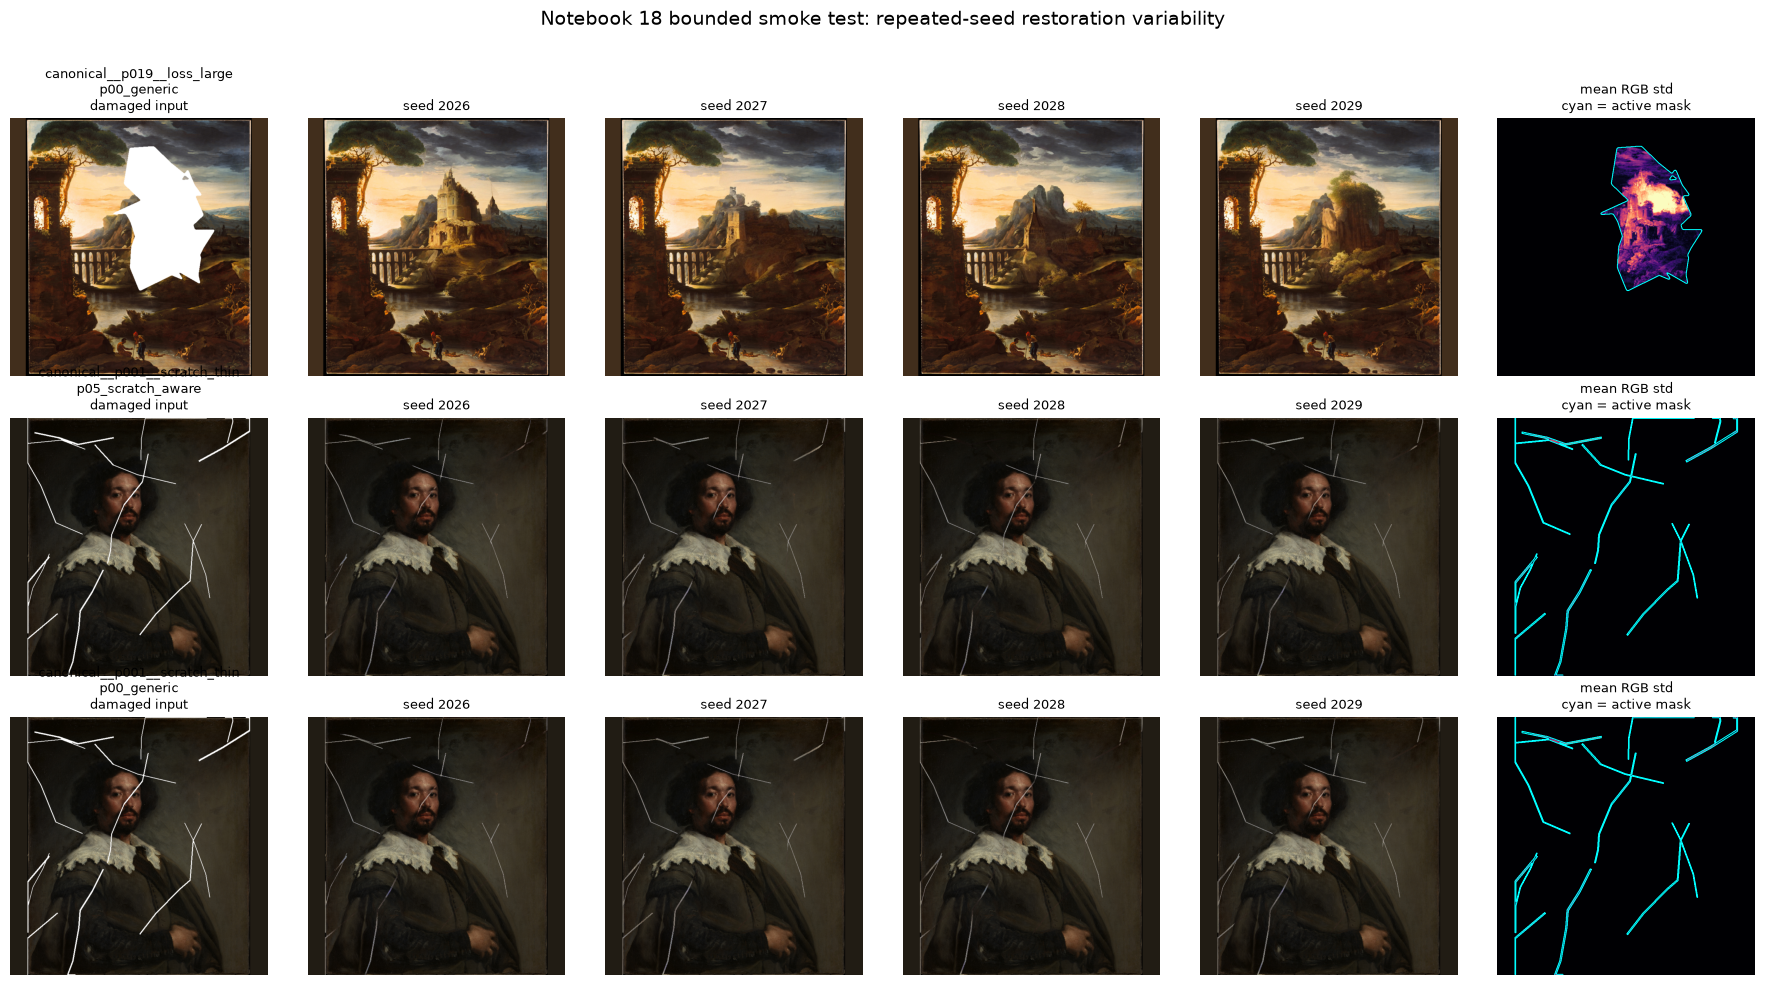

Inline smoke QA rendered for 3 prompt-specific groups.
Shared RGB-standard-deviation vmax: 0.27594
No canonical heatmap was persisted; Notebook 19 retains heatmap ownership.


In [15]:
# ---------------------------------------------------------------------------
# Inline visual QA: damaged input, four seeds, and RGB standard deviation
# ---------------------------------------------------------------------------

import matplotlib.pyplot as plt


smoke_visual_records = []

for (
    uncertainty_group_id,
    smoke_group_df,
) in smoke_population_df.groupby(
    "uncertainty_group_id",
    sort=True,
):
    ordered_group = smoke_group_df.sort_values(
        "seed",
        kind="stable",
    )

    representative_row = ordered_group.iloc[0]

    damaged_image = load_rgb_array(
        representative_row["input_image_path"],
        PROJECT_ROOT,
    )

    raw_mask = load_mask_array(
        representative_row["mask_or_effect_path"],
        PROJECT_ROOT,
    )

    active_mask = (
        raw_mask
        >= int(
            float(
                representative_row[
                    "mask_threshold"
                ]
            )
        )
    )

    restored_images = [
        load_rgb_array(
            row["restored_path"],
            PROJECT_ROOT,
        )
        for _, row in ordered_group.iterrows()
    ]

    restored_stack = np.stack(
        restored_images,
        axis=0,
    )

    rgb_standard_deviation = (
        np.std(
            restored_stack,
            axis=0,
        )
        .mean(axis=2)
    )

    smoke_visual_records.append(
        {
            "group_id": uncertainty_group_id,
            "case_id": str(
                representative_row["case_id"]
            ),
            "prompt_variant_id": str(
                representative_row[
                    "prompt_variant_id"
                ]
            ),
            "damaged_image": damaged_image,
            "restored_images": restored_images,
            "seeds": ordered_group[
                "seed"
            ].astype(int).tolist(),
            "standard_deviation": (
                rgb_standard_deviation
            ),
            "active_mask": active_mask,
        }
    )

smoke_std_vmax = max(
    0.01,
    max(
        float(
            np.percentile(
                record["standard_deviation"],
                99.5,
            )
        )
        for record in smoke_visual_records
    ),
)

figure, axes = plt.subplots(
    nrows=len(smoke_visual_records),
    ncols=6,
    figsize=(18, 10),
    squeeze=False,
)

for row_index, record in enumerate(
    smoke_visual_records
):
    axes[row_index, 0].imshow(
        record["damaged_image"]
    )
    axes[row_index, 0].set_title(
        (
            f"{record['case_id']}\n"
            f"{record['prompt_variant_id']}\n"
            "damaged input"
        ),
        fontsize=9,
    )

    for seed_index, (
        restored_image,
        seed,
    ) in enumerate(
        zip(
            record["restored_images"],
            record["seeds"],
        ),
        start=1,
    ):
        axes[row_index, seed_index].imshow(
            restored_image
        )
        axes[row_index, seed_index].set_title(
            f"seed {seed}",
            fontsize=9,
        )

    standard_deviation_axis = axes[
        row_index,
        5,
    ]

    standard_deviation_axis.imshow(
        record["standard_deviation"],
        cmap="magma",
        vmin=0.0,
        vmax=smoke_std_vmax,
    )

    standard_deviation_axis.contour(
        record["active_mask"].astype(float),
        levels=[0.5],
        colors=["cyan"],
        linewidths=0.7,
    )

    standard_deviation_axis.set_title(
        "mean RGB std\ncyan = active mask",
        fontsize=9,
    )

    for axis in axes[row_index]:
        axis.axis("off")

figure.suptitle(
    (
        "Notebook 18 bounded smoke test: "
        "repeated-seed restoration variability"
    ),
    fontsize=14,
)

figure.tight_layout(
    rect=(0.0, 0.0, 1.0, 0.96)
)

plt.show()
plt.close(figure)

SMOKE_QA_RENDERED = True

print(
    "Inline smoke QA rendered for",
    len(smoke_visual_records),
    "prompt-specific groups.",
)
print(
    "Shared RGB-standard-deviation vmax:",
    round(smoke_std_vmax, 6),
)
print(
    "No canonical heatmap was persisted; "
    "Notebook 19 retains heatmap ownership.",
)

In [16]:
# ---------------------------------------------------------------------------
# Batch 3 validation
# ---------------------------------------------------------------------------

VALIDATION_STAGE = "batch_3_smoke_test"


def add_smoke_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


expected_smoke_family_counts = {
    "feature_pairwise": 72,
    "perceptual_pairwise": 36,
    "pixel_pairwise": 216,
    "pixel_variability": 36,
}

smoke_values = pd.to_numeric(
    smoke_uncertainty_metrics_df["value"],
    errors="coerce",
)

pixel_value_mask = (
    smoke_uncertainty_metrics_df[
        "metric_family"
    ].isin(
        [
            "pixel_variability",
            "pixel_pairwise",
        ]
    )
)

lpips_value_mask = (
    smoke_uncertainty_metrics_df[
        "metric_family"
    ].eq("perceptual_pairwise")
)

feature_value_mask = (
    smoke_uncertainty_metrics_df[
        "metric_family"
    ].eq("feature_pairwise")
)

smoke_seed_coverage = (
    smoke_population_df.groupby(
        "uncertainty_group_id"
    )["seed"]
    .apply(
        lambda values: tuple(
            sorted(
                int(value)
                for value in values
            )
        )
    )
    .to_dict()
)

SMOKE_CANONICAL_FILES_AFTER = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in NOTEBOOK_OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_smoke_check(
    "smoke_group_count",
    "The smoke test contains exactly three prompt-specific groups.",
    3,
    smoke_population_df[
        "uncertainty_group_id"
    ].nunique(),
    smoke_population_df[
        "uncertainty_group_id"
    ].nunique() == 3,
)

add_smoke_check(
    "smoke_group_specification",
    "The selected case and prompt combinations match the approved smoke design.",
    sorted(expected_smoke_specifications),
    sorted(observed_smoke_specifications),
    observed_smoke_specifications
    == expected_smoke_specifications,
)

add_smoke_check(
    "smoke_candidate_count",
    "Each smoke group contains four repeated-seed candidates.",
    12,
    len(smoke_population_df),
    len(smoke_population_df) == 12,
)

add_smoke_check(
    "smoke_pair_count",
    "Each smoke group contains all six unordered seed pairs.",
    18,
    len(smoke_pair_plan_df),
    len(smoke_pair_plan_df) == 18,
)

add_smoke_check(
    "smoke_seed_coverage",
    "Every smoke group uses exactly seeds 2026 through 2029.",
    (2026, 2027, 2028, 2029),
    smoke_seed_coverage,
    all(
        seeds == (2026, 2027, 2028, 2029)
        for seeds in smoke_seed_coverage.values()
    ),
)

add_smoke_check(
    "image_space_row_count",
    "Image-space smoke computation produces 84 rows per group.",
    252,
    len(smoke_image_metrics_df),
    len(smoke_image_metrics_df) == 252,
)

add_smoke_check(
    "lpips_row_count",
    "LPIPS smoke computation produces 12 rows per group.",
    36,
    len(smoke_lpips_metrics_df),
    len(smoke_lpips_metrics_df) == 36,
)

add_smoke_check(
    "feature_row_count",
    "Feature smoke computation produces 24 rows per group.",
    72,
    len(smoke_feature_metrics_df),
    len(smoke_feature_metrics_df) == 72,
)

add_smoke_check(
    "consolidated_smoke_row_count",
    "The consolidated smoke evidence contains the exact expected rows.",
    360,
    len(smoke_uncertainty_metrics_df),
    len(smoke_uncertainty_metrics_df) == 360,
)

add_smoke_check(
    "metric_family_counts",
    "Smoke metric-family counts match the scientific contract.",
    expected_smoke_family_counts,
    smoke_family_counts,
    smoke_family_counts
    == expected_smoke_family_counts,
)

add_smoke_check(
    "smoke_schema",
    "Consolidated smoke evidence satisfies diffusion_uncertainty.v1.",
    True,
    smoke_schema_result.to_dict(),
    smoke_schema_result.passed,
)

add_smoke_check(
    "unique_uncertainty_metric_ids",
    "Smoke evidence contains no duplicate uncertainty metric identifiers.",
    0,
    int(
        smoke_uncertainty_metrics_df[
            "uncertainty_metric_id"
        ].duplicated().sum()
    ),
    not smoke_uncertainty_metrics_df[
        "uncertainty_metric_id"
    ].duplicated().any(),
)

add_smoke_check(
    "finite_metric_values",
    "Every smoke metric value is numeric and finite.",
    True,
    bool(np.isfinite(smoke_values).all()),
    bool(np.isfinite(smoke_values).all()),
)

add_smoke_check(
    "pixel_metric_range",
    "Normalized pixel metrics remain within the valid zero-to-one range.",
    "[0, 1]",
    {
        "minimum": float(
            smoke_values.loc[
                pixel_value_mask
            ].min()
        ),
        "maximum": float(
            smoke_values.loc[
                pixel_value_mask
            ].max()
        ),
    },
    bool(
        smoke_values.loc[
            pixel_value_mask
        ].between(0.0, 1.0).all()
    ),
)

add_smoke_check(
    "lpips_metric_range",
    "LPIPS distances are non-negative within numerical tolerance.",
    ">= -1e-6",
    float(
        smoke_values.loc[
            lpips_value_mask
        ].min()
    ),
    bool(
        (
            smoke_values.loc[
                lpips_value_mask
            ]
            >= -1e-6
        ).all()
    ),
)

add_smoke_check(
    "feature_metric_range",
    "Cosine distances remain within their numerical range.",
    "[-1e-6, 2.000001]",
    {
        "minimum": float(
            smoke_values.loc[
                feature_value_mask
            ].min()
        ),
        "maximum": float(
            smoke_values.loc[
                feature_value_mask
            ].max()
        ),
    },
    bool(
        smoke_values.loc[
            feature_value_mask
        ].between(
            -1e-6,
            2.000001,
        ).all()
    ),
)

add_smoke_check(
    "metric_statuses",
    "All smoke uncertainty rows completed successfully.",
    ["ok"],
    sorted(
        smoke_uncertainty_metrics_df[
            "status"
        ].astype(str).unique()
    ),
    set(
        smoke_uncertainty_metrics_df[
            "status"
        ].astype(str)
    ) == {"ok"},
)

add_smoke_check(
    "empirical_evidence_role",
    "Every smoke metric is explicitly an empirical uncertainty proxy.",
    ["empirical_uncertainty_proxy"],
    sorted(
        smoke_uncertainty_metrics_df[
            "evidence_role"
        ].astype(str).unique()
    ),
    set(
        smoke_uncertainty_metrics_df[
            "evidence_role"
        ].astype(str)
    )
    == {"empirical_uncertainty_proxy"},
)

add_smoke_check(
    "combined_index_absent",
    "No unjustified combined uncertainty index is created.",
    [False],
    sorted(
        smoke_uncertainty_metrics_df[
            "is_combined_index"
        ].unique().tolist()
    ),
    not smoke_uncertainty_metrics_df[
        "is_combined_index"
    ].astype(bool).any(),
)

add_smoke_check(
    "image_checkpoint_resume",
    "Image-space checkpoint resume reproduces the original metric rows.",
    True,
    SMOKE_IMAGE_RESUME_MATCHES,
    SMOKE_IMAGE_RESUME_MATCHES,
)

add_smoke_check(
    "lpips_checkpoint_resume",
    "LPIPS checkpoint resume reproduces the original metric rows.",
    True,
    SMOKE_LPIPS_RESUME_MATCHES,
    SMOKE_LPIPS_RESUME_MATCHES,
)

add_smoke_check(
    "temporary_checkpoint_cleanup",
    "Notebook-owned smoke checkpoints are deleted after validation.",
    True,
    SMOKE_TEMP_DIRECTORY_CLEANED,
    SMOKE_TEMP_DIRECTORY_CLEANED,
)

add_smoke_check(
    "lpips_provenance",
    "The learned perceptual smoke test records its model and runtime provenance.",
    True,
    LPIPS_PROVENANCE,
    bool(
        LPIPS_PROVENANCE.get("network")
        and LPIPS_PROVENANCE.get(
            "lpips_package_version"
        )
        not in {"", "not-installed"}
        and LPIPS_DEVICE in {"cuda", "cpu"}
    ),
)

add_smoke_check(
    "inline_qa_rendered",
    "The three-group candidate variability panel rendered inline.",
    True,
    SMOKE_QA_RENDERED,
    SMOKE_QA_RENDERED,
)

add_smoke_check(
    "no_canonical_smoke_outputs",
    "The smoke test did not persist canonical Notebook 18 artifacts.",
    SMOKE_CANONICAL_FILES_BEFORE,
    SMOKE_CANONICAL_FILES_AFTER,
    SMOKE_CANONICAL_FILES_AFTER
    == SMOKE_CANONICAL_FILES_BEFORE,
)

batch_3_validation_df = (
    VALIDATION.to_dataframe()
)

display(
    batch_3_validation_df.loc[
        batch_3_validation_df[
            "validation_stage"
        ].eq(VALIDATION_STAGE)
    ].reset_index(drop=True)
)

print("Notebook 18 Batch 3 checks assembled.")
print(
    "Batch 3 checks added:",
    int(
        batch_3_validation_df[
            "validation_stage"
        ].eq(VALIDATION_STAGE).sum()
    ),
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_3_smoke_test,smoke_group_count,The smoke test contains exactly three prompt-s...,blocking,3,3,True,
1,batch_3_smoke_test,smoke_group_specification,The selected case and prompt combinations matc...,blocking,"[[""canonical__p001__scratch_thin"", ""p00_generi...","[[""canonical__p001__scratch_thin"", ""p00_generi...",True,
2,batch_3_smoke_test,smoke_candidate_count,Each smoke group contains four repeated-seed c...,blocking,12,12,True,
3,batch_3_smoke_test,smoke_pair_count,Each smoke group contains all six unordered se...,blocking,18,18,True,
4,batch_3_smoke_test,smoke_seed_coverage,Every smoke group uses exactly seeds 2026 thro...,blocking,"[2026, 2027, 2028, 2029]","{""ug_0bcde5e7a6ed71ff16"": [2026, 2027, 2028, 2...",True,
5,batch_3_smoke_test,image_space_row_count,Image-space smoke computation produces 84 rows...,blocking,252,252,True,
6,batch_3_smoke_test,lpips_row_count,LPIPS smoke computation produces 12 rows per g...,blocking,36,36,True,
7,batch_3_smoke_test,feature_row_count,Feature smoke computation produces 24 rows per...,blocking,72,72,True,
8,batch_3_smoke_test,consolidated_smoke_row_count,The consolidated smoke evidence contains the e...,blocking,360,360,True,
9,batch_3_smoke_test,metric_family_counts,Smoke metric-family counts match the scientifi...,blocking,"{""feature_pairwise"": 72, ""perceptual_pairwise""...","{""feature_pairwise"": 72, ""perceptual_pairwise""...",True,


Notebook 18 Batch 3 checks assembled.
Batch 3 checks added: 25


In [17]:
# ---------------------------------------------------------------------------
# Batch 3 gate
# ---------------------------------------------------------------------------

batch_3_summary = VALIDATION.summary()

print("Notebook 18 Batch 3 summary")
print(
    "Total validation checks:",
    batch_3_summary["check_count"],
)
print(
    "Blocking failures across Batches 1–3:",
    batch_3_summary[
        "blocking_failure_count"
    ],
)
print(
    "Smoke uncertainty rows:",
    len(smoke_uncertainty_metrics_df),
)
print(
    "Smoke metric-family counts:",
    smoke_family_counts,
)
print(
    "Canonical Notebook 18 files persisted:",
    len(SMOKE_CANONICAL_FILES_AFTER),
)

if VALIDATION.blocking_failures:
    display(
        batch_3_validation_df.loc[
            (
                batch_3_validation_df[
                    "severity"
                ].eq("blocking")
            )
            & (
                ~batch_3_validation_df[
                    "passed"
                ]
            )
        ].reset_index(drop=True)
    )

    raise RuntimeError(
        "Notebook 18 Batch 3 has blocking "
        "validation failures."
    )

print(
    "Batch 3 passed: image-space, LPIPS, and "
    "feature-space uncertainty computations work "
    "on the bounded three-group smoke population; "
    "checkpoint resume is reproducible and no "
    "canonical outputs were written."
)

Notebook 18 Batch 3 summary
Total validation checks: 80
Blocking failures across Batches 1–3: 0
Smoke uncertainty rows: 360
Smoke metric-family counts: {'feature_pairwise': 72, 'perceptual_pairwise': 36, 'pixel_pairwise': 216, 'pixel_variability': 36}
Canonical Notebook 18 files persisted: 0
Batch 3 passed: image-space, LPIPS, and feature-space uncertainty computations work on the bounded three-group smoke population; checkpoint resume is reproducible and no canonical outputs were written.


## Batch 4 — Full empirical uncertainty execution

This batch executes the validated uncertainty workflow over all 780 eligible
prompt-specific Stable Diffusion groups:

- 3120 candidates;
- four seeds per group;
- 4680 unordered within-group candidate pairs;
- six canonical pixel regions;
- two learned-metric regions.

The batch computes image-space variability, pairwise LPIPS, and pairwise
CLIP/DINOv2 distances. Image-space and LPIPS computations use resumable
Notebook 18 work checkpoints with progress reporting every 10 groups.

No restoration inference occurs. Canonical metrics are not persisted until
the subsequent scientific-validation and calibration stages succeed.

In [18]:
# ---------------------------------------------------------------------------
# Full-execution preflight
# ---------------------------------------------------------------------------

import time

from restoration_eval.diffusion_uncertainty import (
    find_latest_checkpoint,
)


if VALIDATION.blocking_failures:
    raise RuntimeError(
        "Full execution cannot begin while an "
        "earlier batch has blocking failures."
    )

if len(uncertainty_population_df) != 3120:
    raise ValueError(
        "Full execution requires exactly 3120 candidates."
    )

if (
    uncertainty_population_df[
        "uncertainty_group_id"
    ].nunique()
    != 780
):
    raise ValueError(
        "Full execution requires exactly 780 "
        "prompt-specific groups."
    )

if len(uncertainty_pair_plan_df) != 4680:
    raise ValueError(
        "Full execution requires exactly 4680 "
        "unordered candidate pairs."
    )

FULL_EXECUTION_STARTED_AT_UTC = utc_now_iso()
FULL_EXECUTION_RUNTIME_RECORDS = []

non_work_files_before_full_execution = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in NOTEBOOK_OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and OUTPUT_DIRECTORIES["work"]
        not in path.parents
    )
)

print("Notebook 18 full execution preflight passed.")
print(
    "Groups:",
    uncertainty_population_df[
        "uncertainty_group_id"
    ].nunique(),
)
print("Candidates:", len(uncertainty_population_df))
print("Pairs:", len(uncertainty_pair_plan_df))
print(
    "Progress interval:",
    EXECUTION_POLICY[
        "progress_interval_groups"
    ],
    "groups",
)
print(
    "Full execution started at UTC:",
    FULL_EXECUTION_STARTED_AT_UTC,
)

Notebook 18 full execution preflight passed.
Groups: 780
Candidates: 3120
Pairs: 4680
Progress interval: 10 groups
Full execution started at UTC: 2026-09-17T22:43:37.359029Z


In [19]:
# ---------------------------------------------------------------------------
# Full image-space uncertainty
# ---------------------------------------------------------------------------

image_stage_started = time.perf_counter()

full_image_metrics_df = (
    run_image_space_uncertainty(
        uncertainty_population_df,
        project_root=PROJECT_ROOT,
        config=UNCERTAINTY_CONFIG_DOCUMENT,
        checkpoint_path=(
            WORK_PATHS["image_checkpoint"]
        ),
        progress_callback=print,
    )
)

image_stage_seconds = (
    time.perf_counter()
    - image_stage_started
)

FULL_EXECUTION_RUNTIME_RECORDS.append(
    {
        "stage": "image_space_uncertainty",
        "rows": len(full_image_metrics_df),
        "groups": full_image_metrics_df[
            "uncertainty_group_id"
        ].nunique(),
        "wall_seconds_this_invocation": (
            image_stage_seconds
        ),
    }
)

print("Full image-space computation complete.")
print("Rows:", len(full_image_metrics_df))
print(
    "Metric-family counts:",
    full_image_metrics_df[
        "metric_family"
    ].value_counts().to_dict(),
)
print(
    "Wall seconds for this invocation:",
    round(image_stage_seconds, 3),
)

Image-space uncertainty: 0 complete groups resumed from no checkpoint; 780 pending
Image-space uncertainty: 10/780 groups; latest=ug_044fcbbfa6309a5a2f
Image-space uncertainty: 20/780 groups; latest=ug_07d11ef5d77db341b4
Image-space uncertainty: 30/780 groups; latest=ug_0bed68bad80f79e254
Image-space uncertainty: 40/780 groups; latest=ug_0e4fb838c94f161f04
Image-space uncertainty: 50/780 groups; latest=ug_1139a53b3f84da9904
Image-space uncertainty: 60/780 groups; latest=ug_13ca7d7c1d391a529a
Image-space uncertainty: 70/780 groups; latest=ug_16b074590573c88f55
Image-space uncertainty: 80/780 groups; latest=ug_193495aa10cb9c9d8e
Image-space uncertainty: 90/780 groups; latest=ug_1bf3fbbeda6b928691
Image-space uncertainty: 100/780 groups; latest=ug_1ec72ebeb28a10f379
Image-space uncertainty: 110/780 groups; latest=ug_2382752867358bdbe3
Image-space uncertainty: 120/780 groups; latest=ug_268441e0d1d9fbe4f5
Image-space uncertainty: 130/780 groups; latest=ug_28aba7f369c713b4d6
Image-space unce

In [20]:
# ---------------------------------------------------------------------------
# Full pairwise LPIPS uncertainty
# ---------------------------------------------------------------------------

lpips_stage_started = time.perf_counter()

full_lpips_metrics_df = (
    run_lpips_pairwise_uncertainty(
        uncertainty_population_df,
        model=LPIPS_MODEL,
        device=LPIPS_DEVICE,
        project_root=PROJECT_ROOT,
        config=UNCERTAINTY_CONFIG_DOCUMENT,
        lpips_config=LPIPS_CONFIG_DOCUMENT,
        checkpoint_path=(
            WORK_PATHS["lpips_checkpoint"]
        ),
        progress_callback=print,
    )
)

lpips_stage_seconds = (
    time.perf_counter()
    - lpips_stage_started
)

FULL_EXECUTION_RUNTIME_RECORDS.append(
    {
        "stage": "lpips_pairwise_uncertainty",
        "rows": len(full_lpips_metrics_df),
        "groups": full_lpips_metrics_df[
            "uncertainty_group_id"
        ].nunique(),
        "wall_seconds_this_invocation": (
            lpips_stage_seconds
        ),
    }
)

print("Full LPIPS computation complete.")
print("Rows:", len(full_lpips_metrics_df))
print("Device:", LPIPS_DEVICE)
print(
    "Wall seconds for this invocation:",
    round(lpips_stage_seconds, 3),
)

Pairwise LPIPS uncertainty: 0 complete groups resumed from no checkpoint; 780 pending
Pairwise LPIPS uncertainty: 10/780 groups; latest=ug_044fcbbfa6309a5a2f
Pairwise LPIPS uncertainty: 20/780 groups; latest=ug_07d11ef5d77db341b4
Pairwise LPIPS uncertainty: 30/780 groups; latest=ug_0bed68bad80f79e254
Pairwise LPIPS uncertainty: 40/780 groups; latest=ug_0e4fb838c94f161f04
Pairwise LPIPS uncertainty: 50/780 groups; latest=ug_1139a53b3f84da9904
Pairwise LPIPS uncertainty: 60/780 groups; latest=ug_13ca7d7c1d391a529a
Pairwise LPIPS uncertainty: 70/780 groups; latest=ug_16b074590573c88f55
Pairwise LPIPS uncertainty: 80/780 groups; latest=ug_193495aa10cb9c9d8e
Pairwise LPIPS uncertainty: 90/780 groups; latest=ug_1bf3fbbeda6b928691
Pairwise LPIPS uncertainty: 100/780 groups; latest=ug_1ec72ebeb28a10f379
Pairwise LPIPS uncertainty: 110/780 groups; latest=ug_2382752867358bdbe3
Pairwise LPIPS uncertainty: 120/780 groups; latest=ug_268441e0d1d9fbe4f5
Pairwise LPIPS uncertainty: 130/780 groups; lat

In [21]:
# ---------------------------------------------------------------------------
# Full feature-space uncertainty and empirical consolidation
# ---------------------------------------------------------------------------

feature_stage_started = time.perf_counter()

full_feature_metrics_df = (
    compute_feature_pairwise_uncertainty(
        uncertainty_population_df,
        embedding_manifest=(
            feature_embedding_manifest_df
        ),
        embedding_arrays=(
            feature_embedding_arrays
        ),
        config=UNCERTAINTY_CONFIG_DOCUMENT,
        progress_callback=print,
    )
)

feature_stage_seconds = (
    time.perf_counter()
    - feature_stage_started
)

FULL_EXECUTION_RUNTIME_RECORDS.append(
    {
        "stage": "feature_pairwise_uncertainty",
        "rows": len(full_feature_metrics_df),
        "groups": full_feature_metrics_df[
            "uncertainty_group_id"
        ].nunique(),
        "wall_seconds_this_invocation": (
            feature_stage_seconds
        ),
    }
)

full_empirical_metrics_df = pd.concat(
    [
        full_image_metrics_df,
        full_lpips_metrics_df,
        full_feature_metrics_df,
    ],
    ignore_index=True,
)

full_empirical_metrics_df[
    "value"
] = pd.to_numeric(
    full_empirical_metrics_df["value"],
    errors="raise",
)

full_empirical_schema_result = (
    validate_dataframe(
        full_empirical_metrics_df,
        DIFFUSION_UNCERTAINTY_SCHEMA,
    )
)

FULL_EXECUTION_COMPLETED_AT_UTC = utc_now_iso()

full_execution_runtime_df = pd.DataFrame(
    FULL_EXECUTION_RUNTIME_RECORDS
)

full_metric_summary_df = (
    full_empirical_metrics_df.groupby(
        [
            "metric_family",
            "metric_name",
            "region_id",
        ],
        as_index=False,
        sort=True,
    )
    .agg(
        rows=(
            "uncertainty_metric_id",
            "size",
        ),
        groups=(
            "uncertainty_group_id",
            "nunique",
        ),
        value_min=("value", "min"),
        value_median=("value", "median"),
        value_mean=("value", "mean"),
        value_max=("value", "max"),
    )
)

print("Full feature computation complete.")
print(
    "Feature rows:",
    len(full_feature_metrics_df),
)
print(
    "Consolidated empirical rows:",
    len(full_empirical_metrics_df),
)
print(
    "Metric-family counts:",
    full_empirical_metrics_df[
        "metric_family"
    ].value_counts().to_dict(),
)
print(
    "Empirical schema passed:",
    full_empirical_schema_result.passed,
)
print(
    "Full execution completed at UTC:",
    FULL_EXECUTION_COMPLETED_AT_UTC,
)

display(full_execution_runtime_df)
display(full_metric_summary_df)

Feature uncertainty: 10/780 groups; latest=ug_044fcbbfa6309a5a2f
Feature uncertainty: 20/780 groups; latest=ug_07d11ef5d77db341b4
Feature uncertainty: 30/780 groups; latest=ug_0bed68bad80f79e254
Feature uncertainty: 40/780 groups; latest=ug_0e4fb838c94f161f04
Feature uncertainty: 50/780 groups; latest=ug_1139a53b3f84da9904
Feature uncertainty: 60/780 groups; latest=ug_13ca7d7c1d391a529a
Feature uncertainty: 70/780 groups; latest=ug_16b074590573c88f55
Feature uncertainty: 80/780 groups; latest=ug_193495aa10cb9c9d8e
Feature uncertainty: 90/780 groups; latest=ug_1bf3fbbeda6b928691
Feature uncertainty: 100/780 groups; latest=ug_1ec72ebeb28a10f379
Feature uncertainty: 110/780 groups; latest=ug_2382752867358bdbe3
Feature uncertainty: 120/780 groups; latest=ug_268441e0d1d9fbe4f5
Feature uncertainty: 130/780 groups; latest=ug_28aba7f369c713b4d6
Feature uncertainty: 140/780 groups; latest=ug_2c7abb8f7708426dee
Feature uncertainty: 150/780 groups; latest=ug_2fa99039e9788c0f36
Feature uncertainty

,stage,rows,groups,wall_seconds_this_invocation
0,image_space_uncertainty,65520,780,1366.240743
1,lpips_pairwise_uncertainty,9360,780,724.747867
2,feature_pairwise_uncertainty,18720,780,5.364763


,metric_family,metric_name,region_id,rows,groups,value_min,value_median,value_mean,value_max
0,feature_pairwise,pairwise_clip_cosine_distance,content_region,4680,780,8.547306e-05,0.003191,0.006977,0.142459
1,feature_pairwise,pairwise_clip_cosine_distance,mask_bbox_crop,4680,780,-1.192093e-07,0.003348,0.009865,0.226328
2,feature_pairwise,pairwise_dinov2_cosine_distance,content_region,4680,780,1.037121e-05,0.007757,0.020536,0.510582
3,feature_pairwise,pairwise_dinov2_cosine_distance,mask_bbox_crop,4680,780,0.000000e+00,0.008133,0.029946,0.693340
4,perceptual_pairwise,pairwise_lpips_distance,content_region,4680,780,4.041218e-04,0.015928,0.024960,0.184458
5,perceptual_pairwise,pairwise_lpips_distance,mask_bbox_crop,4680,780,6.966273e-04,0.017315,0.043824,0.619005
6,pixel_pairwise,pairwise_rgb_mae,boundary_ring,4680,780,8.815201e-03,0.027217,0.027917,0.072559
7,pixel_pairwise,pairwise_rgb_mae,content_region,4680,780,4.288422e-04,0.001875,0.003436,0.041786
8,pixel_pairwise,pairwise_rgb_mae,full_image,4680,780,3.233067e-04,0.001429,0.002598,0.031340
9,pixel_pairwise,pairwise_rgb_mae,mask_bbox_crop,4680,780,4.288422e-04,0.001989,0.007740,0.166754


In [22]:
# ---------------------------------------------------------------------------
# Batch 4 validation
# ---------------------------------------------------------------------------

VALIDATION_STAGE = "batch_4_full_execution"


def add_full_execution_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


expected_full_family_counts = {
    "feature_pairwise": int(
        EXPECTED_COUNTS["feature_pair_rows"]
    ),
    "perceptual_pairwise": int(
        EXPECTED_COUNTS["lpips_pair_rows"]
    ),
    "pixel_pairwise": int(
        EXPECTED_COUNTS["pixel_pair_rows"]
    ),
    "pixel_variability": int(
        EXPECTED_COUNTS[
            "pixel_group_summary_rows"
        ]
    ),
}

observed_full_family_counts = (
    full_empirical_metrics_df[
        "metric_family"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)

observed_family_group_counts = (
    full_empirical_metrics_df.groupby(
        "metric_family"
    )["uncertainty_group_id"]
    .nunique()
    .sort_index()
    .to_dict()
)

expected_family_group_counts = {
    family: int(
        EXPECTED_COUNTS[
            "uncertainty_groups"
        ]
    )
    for family in expected_full_family_counts
}

full_empirical_values = pd.to_numeric(
    full_empirical_metrics_df["value"],
    errors="coerce",
)

full_image_checkpoint_path = (
    find_latest_checkpoint(
        WORK_PATHS["image_checkpoint"]
    )
)

full_lpips_checkpoint_path = (
    find_latest_checkpoint(
        WORK_PATHS["lpips_checkpoint"]
    )
)

non_work_files_after_full_execution = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in NOTEBOOK_OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and OUTPUT_DIRECTORIES["work"]
        not in path.parents
    )
)

add_full_execution_check(
    "image_metric_rows",
    "Full image-space uncertainty has the exact expected row count.",
    65520,
    len(full_image_metrics_df),
    len(full_image_metrics_df) == 65520,
)

add_full_execution_check(
    "lpips_metric_rows",
    "Full LPIPS uncertainty has the exact expected row count.",
    9360,
    len(full_lpips_metrics_df),
    len(full_lpips_metrics_df) == 9360,
)

add_full_execution_check(
    "feature_metric_rows",
    "Full feature uncertainty has the exact expected row count.",
    18720,
    len(full_feature_metrics_df),
    len(full_feature_metrics_df) == 18720,
)

add_full_execution_check(
    "empirical_metric_rows",
    "The complete empirical uncertainty table has 93600 rows.",
    93600,
    len(full_empirical_metrics_df),
    len(full_empirical_metrics_df) == 93600,
)

add_full_execution_check(
    "metric_family_counts",
    "Full empirical metric-family counts match the contract.",
    expected_full_family_counts,
    observed_full_family_counts,
    observed_full_family_counts
    == expected_full_family_counts,
)

add_full_execution_check(
    "family_group_coverage",
    "Every empirical metric family covers all 780 groups.",
    expected_family_group_counts,
    observed_family_group_counts,
    observed_family_group_counts
    == expected_family_group_counts,
)

add_full_execution_check(
    "full_empirical_schema",
    "Full empirical evidence satisfies diffusion_uncertainty.v1.",
    True,
    full_empirical_schema_result.to_dict(),
    full_empirical_schema_result.passed,
)

add_full_execution_check(
    "unique_full_metric_ids",
    "Full empirical evidence has unique metric identifiers.",
    0,
    int(
        full_empirical_metrics_df[
            "uncertainty_metric_id"
        ].duplicated().sum()
    ),
    not full_empirical_metrics_df[
        "uncertainty_metric_id"
    ].duplicated().any(),
)

add_full_execution_check(
    "finite_full_metric_values",
    "Every full-execution metric value is numeric and finite.",
    True,
    bool(
        np.isfinite(
            full_empirical_values
        ).all()
    ),
    bool(
        np.isfinite(
            full_empirical_values
        ).all()
    ),
)

add_full_execution_check(
    "full_metric_statuses",
    "All full-execution metric rows completed successfully.",
    ["ok"],
    sorted(
        full_empirical_metrics_df[
            "status"
        ].astype(str).unique()
    ),
    set(
        full_empirical_metrics_df[
            "status"
        ].astype(str)
    ) == {"ok"},
)

add_full_execution_check(
    "full_evidence_role",
    "All full-execution rows remain empirical uncertainty proxies.",
    ["empirical_uncertainty_proxy"],
    sorted(
        full_empirical_metrics_df[
            "evidence_role"
        ].astype(str).unique()
    ),
    set(
        full_empirical_metrics_df[
            "evidence_role"
        ].astype(str)
    )
    == {"empirical_uncertainty_proxy"},
)

add_full_execution_check(
    "full_combined_index_absent",
    "Full execution does not create a combined uncertainty index.",
    [False],
    sorted(
        full_empirical_metrics_df[
            "is_combined_index"
        ].unique().tolist()
    ),
    not full_empirical_metrics_df[
        "is_combined_index"
    ].astype(bool).any(),
)

add_full_execution_check(
    "full_observation_levels",
    "Full execution contains only group summaries and candidate pairs.",
    [
        "candidate_pair",
        "group_summary",
    ],
    sorted(
        full_empirical_metrics_df[
            "observation_level"
        ].astype(str).unique()
    ),
    set(
        full_empirical_metrics_df[
            "observation_level"
        ].astype(str)
    )
    == {
        "candidate_pair",
        "group_summary",
    },
)

add_full_execution_check(
    "full_seed_coverage",
    "Every empirical metric row belongs to a complete four-seed group.",
    {
        "seed_count": [4],
        "coverage": ["complete"],
    },
    {
        "seed_count": sorted(
            full_empirical_metrics_df[
                "seed_count"
            ].astype(int).unique().tolist()
        ),
        "coverage": sorted(
            full_empirical_metrics_df[
                "seed_coverage_status"
            ].astype(str).unique().tolist()
        ),
    },
    (
        set(
            full_empirical_metrics_df[
                "seed_count"
            ].astype(int)
        )
        == {4}
        and set(
            full_empirical_metrics_df[
                "seed_coverage_status"
            ].astype(str)
        )
        == {"complete"}
    ),
)

add_full_execution_check(
    "image_checkpoint_available",
    "A resumable image-space checkpoint exists.",
    True,
    (
        str(full_image_checkpoint_path)
        if full_image_checkpoint_path
        else ""
    ),
    (
        full_image_checkpoint_path
        is not None
        and full_image_checkpoint_path.is_file()
    ),
)

add_full_execution_check(
    "lpips_checkpoint_available",
    "A resumable LPIPS checkpoint exists.",
    True,
    (
        str(full_lpips_checkpoint_path)
        if full_lpips_checkpoint_path
        else ""
    ),
    (
        full_lpips_checkpoint_path
        is not None
        and full_lpips_checkpoint_path.is_file()
    ),
)

add_full_execution_check(
    "no_premature_canonical_outputs",
    "Full execution has not persisted canonical non-work artifacts.",
    non_work_files_before_full_execution,
    non_work_files_after_full_execution,
    (
        non_work_files_after_full_execution
        == non_work_files_before_full_execution
    ),
)

add_full_execution_check(
    "positive_stage_runtimes",
    "Every full-execution stage records a positive invocation runtime.",
    True,
    full_execution_runtime_df[
        [
            "stage",
            "wall_seconds_this_invocation",
        ]
    ].to_dict("records"),
    bool(
        (
            full_execution_runtime_df[
                "wall_seconds_this_invocation"
            ]
            > 0.0
        ).all()
    ),
)

batch_4_validation_df = (
    VALIDATION.to_dataframe()
)

display(
    batch_4_validation_df.loc[
        batch_4_validation_df[
            "validation_stage"
        ].eq(VALIDATION_STAGE)
    ].reset_index(drop=True)
)

print("Notebook 18 Batch 4 checks assembled.")
print(
    "Batch 4 checks added:",
    int(
        batch_4_validation_df[
            "validation_stage"
        ].eq(VALIDATION_STAGE).sum()
    ),
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_4_full_execution,image_metric_rows,Full image-space uncertainty has the exact exp...,blocking,65520,65520,True,
1,batch_4_full_execution,lpips_metric_rows,Full LPIPS uncertainty has the exact expected ...,blocking,9360,9360,True,
2,batch_4_full_execution,feature_metric_rows,Full feature uncertainty has the exact expecte...,blocking,18720,18720,True,
3,batch_4_full_execution,empirical_metric_rows,The complete empirical uncertainty table has 9...,blocking,93600,93600,True,
4,batch_4_full_execution,metric_family_counts,Full empirical metric-family counts match the ...,blocking,"{""feature_pairwise"": 18720, ""perceptual_pairwi...","{""feature_pairwise"": 18720, ""perceptual_pairwi...",True,
5,batch_4_full_execution,family_group_coverage,Every empirical metric family covers all 780 g...,blocking,"{""feature_pairwise"": 780, ""perceptual_pairwise...","{""feature_pairwise"": 780, ""perceptual_pairwise...",True,
6,batch_4_full_execution,full_empirical_schema,Full empirical evidence satisfies diffusion_un...,blocking,True,"{""column_count"": 40, ""duplicate_primary_key_ro...",True,
7,batch_4_full_execution,unique_full_metric_ids,Full empirical evidence has unique metric iden...,blocking,0,0,True,
8,batch_4_full_execution,finite_full_metric_values,Every full-execution metric value is numeric a...,blocking,True,True,True,
9,batch_4_full_execution,full_metric_statuses,All full-execution metric rows completed succe...,blocking,"[""ok""]","[""ok""]",True,


Notebook 18 Batch 4 checks assembled.
Batch 4 checks added: 18


In [23]:
# ---------------------------------------------------------------------------
# Batch 4 gate
# ---------------------------------------------------------------------------

batch_4_summary = VALIDATION.summary()

print("Notebook 18 Batch 4 summary")
print(
    "Total validation checks:",
    batch_4_summary["check_count"],
)
print(
    "Blocking failures across Batches 1–4:",
    batch_4_summary[
        "blocking_failure_count"
    ],
)
print(
    "Empirical uncertainty rows:",
    len(full_empirical_metrics_df),
)
print(
    "Covered uncertainty groups:",
    full_empirical_metrics_df[
        "uncertainty_group_id"
    ].nunique(),
)
print(
    "Image checkpoint:",
    full_image_checkpoint_path,
)
print(
    "LPIPS checkpoint:",
    full_lpips_checkpoint_path,
)
print(
    "Canonical non-work files persisted:",
    len(
        non_work_files_after_full_execution
    ),
)

if VALIDATION.blocking_failures:
    display(
        batch_4_validation_df.loc[
            (
                batch_4_validation_df[
                    "severity"
                ].eq("blocking")
            )
            & (
                ~batch_4_validation_df[
                    "passed"
                ]
            )
        ].reset_index(drop=True)
    )

    raise RuntimeError(
        "Notebook 18 Batch 4 has blocking "
        "validation failures."
    )

print(
    "Batch 4 passed: all 780 prompt-specific "
    "groups have complete image-space, LPIPS, "
    "and feature-space empirical uncertainty "
    "evidence with resumable checkpoints."
)

Notebook 18 Batch 4 summary
Total validation checks: 98
Blocking failures across Batches 1–4: 0
Empirical uncertainty rows: 93600
Covered uncertainty groups: 780
Image checkpoint: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\18_diffusion_uncertainty_analysis\work\image_uncertainty_checkpoint.csv
LPIPS checkpoint: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\18_diffusion_uncertainty_analysis\work\lpips_uncertainty_checkpoint.csv
Canonical non-work files persisted: 0
Batch 4 passed: all 780 prompt-specific groups have complete image-space, LPIPS, and feature-space empirical uncertainty evidence with resumable checkpoints.


## Batch 5 — Reference evidence and calibration-ready table

This batch combines the empirical repeated-seed uncertainty evidence with
selected candidate-to-reference evidence produced by Notebooks 13–15 and 17.

Ten reference metrics are retained for each of the 3120 Stable Diffusion
candidates, producing 31200 seed-reference rows. These are calibration
references rather than uncertainty measurements.

The resulting 124800-row evidence table is then summarized into one
calibration-ready row per prompt-specific uncertainty group. The 780
calibration rows retain separate uncertainty components and reference
performance statistics without constructing a combined uncertainty index.

Semantic evidence, human-review flags, and failure categories remain
explicitly unavailable because they belong to later notebooks.

In [24]:
# ---------------------------------------------------------------------------
# Seed-level reference evidence
# ---------------------------------------------------------------------------

from restoration_eval.diffusion_uncertainty import (
    build_seed_reference_rows,
    build_uncertainty_calibration_inputs,
    validate_uncertainty_calibration_inputs,
    validate_uncertainty_metrics,
)


seed_reference_metrics_df = (
    build_seed_reference_rows(
        uncertainty_population_df,
        REFERENCE_SOURCE_TABLES,
        config=UNCERTAINTY_CONFIG_DOCUMENT,
    )
)

seed_reference_metrics_df[
    "value"
] = pd.to_numeric(
    seed_reference_metrics_df["value"],
    errors="raise",
)

full_uncertainty_metrics_df = pd.concat(
    [
        full_empirical_metrics_df,
        seed_reference_metrics_df,
    ],
    ignore_index=True,
)

full_uncertainty_metrics_df[
    "value"
] = pd.to_numeric(
    full_uncertainty_metrics_df["value"],
    errors="raise",
)

seed_reference_alias_counts = (
    seed_reference_metrics_df[
        "metric_name"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)

seed_reference_family_counts = (
    seed_reference_metrics_df[
        "metric_family"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)

print("Seed-reference evidence constructed.")
print(
    "Reference aliases:",
    len(seed_reference_alias_counts),
)
print(
    "Seed-reference rows:",
    len(seed_reference_metrics_df),
)
print(
    "Reference family counts:",
    seed_reference_family_counts,
)
print(
    "Complete uncertainty table rows:",
    len(full_uncertainty_metrics_df),
)

display(
    pd.DataFrame(
        [
            {
                "metric_name": metric_name,
                "rows": rows,
            }
            for metric_name, rows
            in seed_reference_alias_counts.items()
        ]
    )
)

Seed-reference evidence constructed.
Reference aliases: 10
Seed-reference rows: 31200
Reference family counts: {'classical_reference': 9360, 'feature_reference': 6240, 'local_consistency_reference': 12480, 'perceptual_reference': 3120}
Complete uncertainty table rows: 124800


,metric_name,rows
0,colour_delta_e_masked,3120
1,reference_clip_crop,3120
2,reference_dino_crop,3120
3,reference_lpips_crop,3120
4,reference_mae_masked,3120
5,reference_psnr_content,3120
6,reference_ssim_crop,3120
7,seam_gradient_mismatch,3120
8,seam_ssim_error,3120
9,texture_error_p95_crop,3120


In [25]:
# ---------------------------------------------------------------------------
# One calibration-ready row per independent uncertainty group
# ---------------------------------------------------------------------------

uncertainty_calibration_inputs_df = (
    build_uncertainty_calibration_inputs(
        uncertainty_population_df,
        full_uncertainty_metrics_df,
        config=UNCERTAINTY_CONFIG_DOCUMENT,
    )
)

calibration_prompt_counts = (
    uncertainty_calibration_inputs_df[
        "prompt_variant_id"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)

calibration_category_counts = (
    uncertainty_calibration_inputs_df[
        "category"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)

calibration_style_counts = (
    uncertainty_calibration_inputs_df[
        "style_or_period"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)

calibration_component_columns = [
    "rgb_std_mean_masked",
    "rgb_std_p95_masked",
    "rgb_pair_mae_mean_masked",
    "rgb_pair_rmse_mean_masked",
    "lpips_pair_mean_content",
    "lpips_pair_mean_crop",
    "clip_pair_distance_mean_content",
    "clip_pair_distance_mean_crop",
    "dino_pair_distance_mean_content",
    "dino_pair_distance_mean_crop",
]

reference_summary_columns = [
    column
    for column in (
        uncertainty_calibration_inputs_df.columns
    )
    if column.endswith(
        (
            "_mean",
            "_std",
            "_worst",
        )
    )
    and column
    not in calibration_component_columns
]

calibration_preview_columns = [
    "uncertainty_group_id",
    "case_id",
    "painting_id",
    "category",
    "style_or_period",
    "prompt_variant_id",
    "seeds",
    *calibration_component_columns,
]

print("Calibration-ready table constructed.")
print(
    "Calibration rows:",
    len(uncertainty_calibration_inputs_df),
)
print(
    "Prompt-specific groups:",
    calibration_prompt_counts,
)
print(
    "Categories:",
    calibration_category_counts,
)
print(
    "Explicit unclassified groups:",
    calibration_style_counts.get(
        "unclassified",
        0,
    ),
)
print(
    "Uncertainty component columns:",
    len(calibration_component_columns),
)
print(
    "Reference summary columns:",
    len(reference_summary_columns),
)

display(
    uncertainty_calibration_inputs_df[
        calibration_preview_columns
    ].head(12)
)

Calibration-ready table constructed.
Calibration rows: 780
Prompt-specific groups: {'p00_generic': 480, 'p05_scratch_aware': 300}
Categories: {'abstraction_surrealism': 156, 'architecture_structured': 156, 'high_texture_brushwork': 156, 'landscape_natural': 156, 'portrait_figure': 156}
Explicit unclassified groups: 91
Uncertainty component columns: 10
Reference summary columns: 30


,uncertainty_group_id,case_id,painting_id,category,style_or_period,prompt_variant_id,seeds,rgb_std_mean_masked,rgb_std_p95_masked,rgb_pair_mae_mean_masked,rgb_pair_rmse_mean_masked,lpips_pair_mean_content,lpips_pair_mean_crop,clip_pair_distance_mean_content,clip_pair_distance_mean_crop,dino_pair_distance_mean_content,dino_pair_distance_mean_crop
0,ug_000c16351fa4ceac6d,canonical__p297__scratch_thin,p297,portrait_figure,18th-century German painting,p00_generic,2026|2027|2028|2029,0.055852,0.178850,0.077200,0.126964,0.037281,0.037281,0.005441,0.005441,0.006392,0.006392
1,ug_01185508d3c0206599,canonical__p181__loss_small,p181,landscape_natural,Romantic-era / early 19th-century painting (Fr...,p00_generic,2026|2027|2028|2029,0.056240,0.155349,0.078004,0.123656,0.031142,0.039982,0.006833,0.011560,0.082248,0.054531
2,ug_0123839b6aaf7c3d02,canonical__p240__scratch_thin,p240,high_texture_brushwork,Mid-19th-century painting,p05_scratch_aware,2026|2027|2028|2029,0.072613,0.187064,0.101532,0.151861,0.027014,0.027014,0.009810,0.009810,0.012149,0.012149
3,ug_01eed5857bc63ea5d2,canonical__p057__loss_large,p057,abstraction_surrealism,Cubism / Early abstraction,p00_generic,2026|2027|2028|2029,0.117083,0.249827,0.162843,0.224432,0.059027,0.238229,0.006140,0.019363,0.021562,0.056365
4,ug_025c04951d371d9b90,canonical__p130__scratch_thin,p130,architecture_structured,"19th-century France, 19th century painting",p00_generic,2026|2027|2028|2029,0.067308,0.176052,0.093723,0.141293,0.033648,0.033918,0.012960,0.015616,0.018175,0.019079
5,ug_02691ab42d9ccf28ea,canonical__p037__scratch_thin,p037,abstraction_surrealism,unclassified,p00_generic,2026|2027|2028|2029,0.047624,0.133730,0.066562,0.104835,0.017017,0.017017,0.003623,0.003623,0.009702,0.009702
6,ug_035a4749f1e9c85b9f,canonical__p071__scratch_thin,p071,abstraction_surrealism,Early abstract art / Symbolism,p05_scratch_aware,2026|2027|2028|2029,0.047636,0.125824,0.067009,0.099671,0.004682,0.004682,0.001771,0.001771,0.005652,0.005652
7,ug_03c8f7fff975f51939,canonical__p050__scratch_thin,p050,high_texture_brushwork,unclassified,p00_generic,2026|2027|2028|2029,0.057195,0.160194,0.080253,0.122540,0.023834,0.028618,0.002707,0.002552,0.013307,0.015273
8,ug_03f53bd70f7fdadac3,canonical__p294__scratch_thin,p294,portrait_figure,15th-century German painting,p05_scratch_aware,2026|2027|2028|2029,0.056007,0.167073,0.077307,0.123863,0.014572,0.014411,0.003279,0.000668,0.002075,0.001687
9,ug_044fcbbfa6309a5a2f,canonical__p068__scratch_thin,p068,abstraction_surrealism,Early abstract art / Symbolism,p05_scratch_aware,2026|2027|2028|2029,0.077393,0.166923,0.108331,0.157005,0.004531,0.004531,0.001137,0.001137,0.007304,0.007304


In [26]:
# ---------------------------------------------------------------------------
# Canonical helper-level scientific validation
# ---------------------------------------------------------------------------

uncertainty_metric_validation = (
    validate_uncertainty_metrics(
        full_uncertainty_metrics_df,
        uncertainty_population_df,
        config=UNCERTAINTY_CONFIG_DOCUMENT,
    )
)

calibration_input_validation = (
    validate_uncertainty_calibration_inputs(
        uncertainty_calibration_inputs_df,
        config=UNCERTAINTY_CONFIG_DOCUMENT,
    )
)

reference_rows_per_group_and_alias = (
    seed_reference_metrics_df.groupby(
        [
            "uncertainty_group_id",
            "metric_name",
        ],
        sort=True,
    )
    .size()
)

reference_seed_sets = (
    seed_reference_metrics_df.groupby(
        [
            "uncertainty_group_id",
            "metric_name",
        ],
        sort=True,
    )["seed"]
    .apply(
        lambda values: tuple(
            sorted(
                int(value)
                for value in values
            )
        )
    )
)

calibration_numeric_columns = [
    *calibration_component_columns,
    *reference_summary_columns,
]

calibration_numeric_values = (
    uncertainty_calibration_inputs_df[
        calibration_numeric_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
)

print("Full uncertainty validation:")
print(
    json.dumps(
        uncertainty_metric_validation,
        indent=2,
        sort_keys=True,
    )
)

print("Calibration-input validation:")
print(
    json.dumps(
        calibration_input_validation,
        indent=2,
        sort_keys=True,
    )
)

print(
    "Reference rows per group/alias:",
    sorted(
        reference_rows_per_group_and_alias
        .unique()
        .tolist()
    ),
)
print(
    "Calibration numeric evidence finite:",
    bool(
        np.isfinite(
            calibration_numeric_values.to_numpy(
                dtype=float
            )
        ).all()
    ),
)

Full uncertainty validation:
{
  "all_values_finite": true,
  "candidates": 3120,
  "combined_index_absent": true,
  "cosine_distance_range_ok": true,
  "family_counts": {
    "classical_reference": 9360,
    "feature_pairwise": 18720,
    "feature_reference": 6240,
    "local_consistency_reference": 12480,
    "perceptual_pairwise": 9360,
    "perceptual_reference": 3120,
    "pixel_pairwise": 56160,
    "pixel_variability": 9360
  },
  "family_counts_match": true,
  "metric_rows": 124800,
  "pair_order_ok": true,
  "passed": true,
  "schema": {
    "column_count": 40,
    "duplicate_primary_key_rows": 0,
    "invalid_value_counts": {
      "evidence_role": 0,
      "is_combined_index": 0,
      "metric_family": 0,
      "observation_level": 0,
      "seed_coverage_status": 0,
      "status": 0
    },
    "missing_columns": [],
    "null_counts": {
      "case_id": 0,
      "case_label": 0,
      "category": 0,
      "configuration_id": 0,
      "damage_or_degradation_type": 0,
      

In [27]:
# ---------------------------------------------------------------------------
# Batch 5 validation
# ---------------------------------------------------------------------------

VALIDATION_STAGE = "batch_5_scientific_validation"


def add_scientific_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


expected_reference_alias_counts = {
    str(specification["alias"]): int(
        EXPECTED_COUNTS["candidates"]
    )
    for specification in CALIBRATION_POLICY[
        "reference_metrics"
    ]
}

expected_reference_family_counts = {
    "classical_reference": 9360,
    "feature_reference": 6240,
    "local_consistency_reference": 12480,
    "perceptual_reference": 3120,
}

expected_complete_family_counts = {
    "classical_reference": 9360,
    "feature_pairwise": 18720,
    "feature_reference": 6240,
    "local_consistency_reference": 12480,
    "perceptual_pairwise": 9360,
    "perceptual_reference": 3120,
    "pixel_pairwise": 56160,
    "pixel_variability": 9360,
}

observed_complete_family_counts = (
    full_uncertainty_metrics_df[
        "metric_family"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)

expected_calibration_prompt_counts = {
    "p00_generic": 480,
    "p05_scratch_aware": 300,
}

availability_columns = [
    "semantic_evidence_available",
    "human_review_flag_available",
    "failure_category_available",
    "combined_uncertainty_index_available",
]

availability_values = (
    uncertainty_calibration_inputs_df[
        availability_columns
    ].astype(bool)
)

scratch_aware_calibration_df = (
    uncertainty_calibration_inputs_df.loc[
        uncertainty_calibration_inputs_df[
            "prompt_variant_id"
        ].astype(str).eq(
            "p05_scratch_aware"
        )
    ]
)

add_scientific_check(
    "seed_reference_rows",
    "Ten reference metrics are retained for every eligible candidate.",
    31200,
    len(seed_reference_metrics_df),
    len(seed_reference_metrics_df) == 31200,
)

add_scientific_check(
    "reference_alias_counts",
    "Every reference alias covers all 3120 candidates.",
    expected_reference_alias_counts,
    seed_reference_alias_counts,
    seed_reference_alias_counts
    == expected_reference_alias_counts,
)

add_scientific_check(
    "reference_family_counts",
    "Reference evidence has the exact family composition.",
    expected_reference_family_counts,
    seed_reference_family_counts,
    seed_reference_family_counts
    == expected_reference_family_counts,
)

add_scientific_check(
    "reference_rows_per_group_alias",
    "Every group and reference alias contains four seed observations.",
    [4],
    sorted(
        reference_rows_per_group_and_alias
        .unique()
        .tolist()
    ),
    bool(
        reference_rows_per_group_and_alias
        .eq(4)
        .all()
    ),
)

add_scientific_check(
    "reference_seed_sets",
    "Every reference summary uses exactly seeds 2026 through 2029.",
    (2026, 2027, 2028, 2029),
    sorted(
        set(
            reference_seed_sets.tolist()
        )
    ),
    all(
        seeds
        == (2026, 2027, 2028, 2029)
        for seeds in reference_seed_sets
    ),
)

add_scientific_check(
    "complete_uncertainty_rows",
    "Empirical and reference evidence produce the contracted 20,800 rows.",
    124800,
    len(full_uncertainty_metrics_df),
    len(full_uncertainty_metrics_df)
    == 124800,
)

add_scientific_check(
    "complete_metric_family_counts",
    "The complete evidence table has the exact metric-family composition.",
    expected_complete_family_counts,
    observed_complete_family_counts,
    observed_complete_family_counts
    == expected_complete_family_counts,
)

add_scientific_check(
    "uncertainty_helper_validation",
    "The canonical uncertainty validator accepts the complete table.",
    True,
    uncertainty_metric_validation,
    uncertainty_metric_validation[
        "passed"
    ],
)

add_scientific_check(
    "complete_metric_ids_unique",
    "The complete evidence table contains unique metric identifiers.",
    0,
    int(
        full_uncertainty_metrics_df[
            "uncertainty_metric_id"
        ].duplicated().sum()
    ),
    not full_uncertainty_metrics_df[
        "uncertainty_metric_id"
    ].duplicated().any(),
)

add_scientific_check(
    "calibration_rows",
    "Calibration inputs contain one row per prompt-specific uncertainty group.",
    780,
    len(uncertainty_calibration_inputs_df),
    len(uncertainty_calibration_inputs_df)
    == 780,
)

add_scientific_check(
    "calibration_group_ids_unique",
    "Calibration uncertainty-group identifiers are unique.",
    0,
    int(
        uncertainty_calibration_inputs_df[
            "uncertainty_group_id"
        ].duplicated().sum()
    ),
    not uncertainty_calibration_inputs_df[
        "uncertainty_group_id"
    ].duplicated().any(),
)

add_scientific_check(
    "calibration_helper_validation",
    "The canonical calibration-input validator accepts all rows.",
    True,
    calibration_input_validation,
    calibration_input_validation[
        "passed"
    ],
)

add_scientific_check(
    "calibration_numeric_evidence",
    "Every uncertainty and reference summary value is finite.",
    True,
    bool(
        np.isfinite(
            calibration_numeric_values.to_numpy(
                dtype=float
            )
        ).all()
    ),
    bool(
        np.isfinite(
            calibration_numeric_values.to_numpy(
                dtype=float
            )
        ).all()
    ),
)

add_scientific_check(
    "calibration_seed_strings",
    "Every calibration row records the exact repeated seeds.",
    ["2026|2027|2028|2029"],
    sorted(
        uncertainty_calibration_inputs_df[
            "seeds"
        ].astype(str).unique()
    ),
    set(
        uncertainty_calibration_inputs_df[
            "seeds"
        ].astype(str)
    )
    == {"2026|2027|2028|2029"},
)

add_scientific_check(
    "calibration_prompt_counts",
    "Generic and scratch-aware prompt groups remain separate.",
    expected_calibration_prompt_counts,
    calibration_prompt_counts,
    calibration_prompt_counts
    == expected_calibration_prompt_counts,
)

add_scientific_check(
    "scratch_aware_scope",
    "Scratch-aware prompt evidence is restricted to scratch-thin cases.",
    ["scratch_thin"],
    sorted(
        scratch_aware_calibration_df[
            "case_label"
        ].astype(str).unique()
    ),
    (
        len(scratch_aware_calibration_df)
        == 300
        and scratch_aware_calibration_df[
            "case_label"
        ].astype(str).eq(
            "scratch_thin"
        ).all()
    ),
)

add_scientific_check(
    "downstream_evidence_unavailable",
    "Semantic and human-review evidence remains explicitly unavailable.",
    {
        column: False
        for column in availability_columns
    },
    {
        column: bool(
            availability_values[column].any()
        )
        for column in availability_columns
    },
    not availability_values.any().any(),
)

add_scientific_check(
    "calibration_scope",
    "Calibration rows are explicitly labelled pre-semantic and pre-human.",
    ["pre_semantic_pre_human_partial"],
    sorted(
        uncertainty_calibration_inputs_df[
            "calibration_scope"
        ].astype(str).unique()
    ),
    set(
        uncertainty_calibration_inputs_df[
            "calibration_scope"
        ].astype(str)
    )
    == {"pre_semantic_pre_human_partial"},
)

add_scientific_check(
    "no_blank_style_metadata",
    "Missing style metadata remains an explicit unclassified value.",
    0,
    int(
        uncertainty_calibration_inputs_df[
            "style_or_period"
        ]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    ),
    not uncertainty_calibration_inputs_df[
        "style_or_period"
    ].fillna("").astype(str).str.strip().eq(
        ""
    ).any(),
)

add_scientific_check(
    "combined_index_still_absent",
    "Neither the evidence table nor calibration table contains a combined index.",
    False,
    {
        "metric_rows_marked_combined": int(
            full_uncertainty_metrics_df[
                "is_combined_index"
            ].astype(bool).sum()
        ),
        "calibration_combined_available": bool(
            uncertainty_calibration_inputs_df[
                "combined_uncertainty_index_available"
            ].astype(bool).any()
        ),
    },
    (
        not full_uncertainty_metrics_df[
            "is_combined_index"
        ].astype(bool).any()
        and not uncertainty_calibration_inputs_df[
            "combined_uncertainty_index_available"
        ].astype(bool).any()
    ),
)

add_scientific_check(
    "no_premature_metric_persistence",
    "Canonical metric files are not written before final validation.",
    {
        "uncertainty_metrics": False,
        "calibration_inputs": False,
    },
    {
        "uncertainty_metrics": OUTPUTS[
            "uncertainty_metrics"
        ].exists(),
        "calibration_inputs": OUTPUTS[
            "calibration_inputs"
        ].exists(),
    },
    (
        not OUTPUTS[
            "uncertainty_metrics"
        ].exists()
        and not OUTPUTS[
            "calibration_inputs"
        ].exists()
    ),
)

batch_5_validation_df = (
    VALIDATION.to_dataframe()
)

display(
    batch_5_validation_df.loc[
        batch_5_validation_df[
            "validation_stage"
        ].eq(VALIDATION_STAGE)
    ].reset_index(drop=True)
)

print("Notebook 18 Batch 5 checks assembled.")
print(
    "Batch 5 checks added:",
    int(
        batch_5_validation_df[
            "validation_stage"
        ].eq(VALIDATION_STAGE).sum()
    ),
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_5_scientific_validation,seed_reference_rows,Ten reference metrics are retained for every e...,blocking,31200,31200,True,
1,batch_5_scientific_validation,reference_alias_counts,Every reference alias covers all 3120 candidates.,blocking,"{""colour_delta_e_masked"": 3120, ""reference_cli...","{""colour_delta_e_masked"": 3120, ""reference_cli...",True,
2,batch_5_scientific_validation,reference_family_counts,Reference evidence has the exact family compos...,blocking,"{""classical_reference"": 9360, ""feature_referen...","{""classical_reference"": 9360, ""feature_referen...",True,
3,batch_5_scientific_validation,reference_rows_per_group_alias,Every group and reference alias contains four ...,blocking,[4],[4],True,
4,batch_5_scientific_validation,reference_seed_sets,Every reference summary uses exactly seeds 202...,blocking,"[2026, 2027, 2028, 2029]","[[2026, 2027, 2028, 2029]]",True,
5,batch_5_scientific_validation,complete_uncertainty_rows,Empirical and reference evidence produce the c...,blocking,124800,124800,True,
6,batch_5_scientific_validation,complete_metric_family_counts,The complete evidence table has the exact metr...,blocking,"{""classical_reference"": 9360, ""feature_pairwis...","{""classical_reference"": 9360, ""feature_pairwis...",True,
7,batch_5_scientific_validation,uncertainty_helper_validation,The canonical uncertainty validator accepts th...,blocking,True,"{""all_values_finite"": true, ""candidates"": 3120...",True,
8,batch_5_scientific_validation,complete_metric_ids_unique,The complete evidence table contains unique me...,blocking,0,0,True,
9,batch_5_scientific_validation,calibration_rows,Calibration inputs contain one row per prompt-...,blocking,780,780,True,


Notebook 18 Batch 5 checks assembled.
Batch 5 checks added: 21


In [28]:
# ---------------------------------------------------------------------------
# Batch 5 gate
# ---------------------------------------------------------------------------

batch_5_summary = VALIDATION.summary()

print("Notebook 18 Batch 5 summary")
print(
    "Total validation checks:",
    batch_5_summary["check_count"],
)
print(
    "Blocking failures across Batches 1–5:",
    batch_5_summary[
        "blocking_failure_count"
    ],
)
print(
    "Complete uncertainty rows:",
    len(full_uncertainty_metrics_df),
)
print(
    "Calibration-ready rows:",
    len(uncertainty_calibration_inputs_df),
)
print(
    "Reference metric aliases:",
    len(seed_reference_alias_counts),
)
print(
    "Prompt-specific calibration groups:",
    calibration_prompt_counts,
)
print(
    "Downstream evidence available:",
    {
        column: bool(
            availability_values[column].any()
        )
        for column in availability_columns
    },
)

if VALIDATION.blocking_failures:
    display(
        batch_5_validation_df.loc[
            (
                batch_5_validation_df[
                    "severity"
                ].eq("blocking")
            )
            & (
                ~batch_5_validation_df[
                    "passed"
                ]
            )
        ].reset_index(drop=True)
    )

    raise RuntimeError(
        "Notebook 18 Batch 5 has blocking "
        "validation failures."
    )

print(
    "Batch 5 passed: 124800 validated evidence "
    "rows and 780 calibration-ready group rows "
    "retain separate uncertainty and performance "
    "components without an unjustified combined index."
)

Notebook 18 Batch 5 summary
Total validation checks: 119
Blocking failures across Batches 1–5: 0
Complete uncertainty rows: 124800
Calibration-ready rows: 780
Reference metric aliases: 10
Prompt-specific calibration groups: {'p00_generic': 480, 'p05_scratch_aware': 300}
Downstream evidence available: {'semantic_evidence_available': False, 'human_review_flag_available': False, 'failure_category_available': False, 'combined_uncertainty_index_available': False}
Batch 5 passed: 124800 validated evidence rows and 780 calibration-ready group rows retain separate uncertainty and performance components without an unjustified combined index.


## Batch 6 — Descriptive analysis and canonical figures

This batch summarizes the validated calibration-ready evidence without
constructing a composite uncertainty score or making calibrated-confidence
claims.

The analysis covers model, damage type, target damage fraction,
artwork category, style or period, experiment, and seed coverage.

A controlled paired analysis compares the generic and scratch-aware prompts
only within the same 300 scratch-thin cases. Lower seed variability is
reported descriptively and is not interpreted as better restoration quality.

The distribution figure uses the controlled 600-row scratch-prompt subset.
The uncertainty-versus-performance figure uses all 780 eligible groups and
is explicitly descriptive rather than a confidence-calibration result.

SDXL remains not applicable because its retained candidates provide only one
seed per case. Deterministic methods remain outside diffusion uncertainty.

In [29]:
# ---------------------------------------------------------------------------
# Required in-memory descriptive summaries
# ---------------------------------------------------------------------------

from restoration_eval.diffusion_uncertainty import (
    render_uncertainty_distributions,
    render_uncertainty_vs_performance,
    summarize_uncertainty,
)


ANALYSIS_VALUE_COLUMNS = (
    "rgb_std_mean_masked",
    "rgb_pair_mae_mean_masked",
    "lpips_pair_mean_crop",
    "clip_pair_distance_mean_crop",
    "dino_pair_distance_mean_crop",
)

ANALYSIS_GROUPINGS = {
    "model": ("model_id",),
    "damage_type": (
        "damage_or_degradation_type",
        "case_label",
    ),
    "target_damage_fraction": (
        "target_damage_fraction",
    ),
    "category": ("category",),
    "style_or_period": (
        "style_or_period",
    ),
    "experiment": ("experiment_id",),
    "seed_coverage": (
        "seed_coverage_status",
    ),
}

uncertainty_summary_tables = {}

for (
    summary_name,
    group_columns,
) in ANALYSIS_GROUPINGS.items():
    uncertainty_summary_tables[
        summary_name
    ] = summarize_uncertainty(
        uncertainty_calibration_inputs_df,
        group_columns=group_columns,
        value_columns=(
            ANALYSIS_VALUE_COLUMNS
        ),
    )

summary_inventory_df = pd.DataFrame(
    [
        {
            "summary_name": summary_name,
            "group_columns": "|".join(
                ANALYSIS_GROUPINGS[
                    summary_name
                ]
            ),
            "rows": len(summary_df),
            "numeric_summary_columns": (
                len(summary_df.columns)
                - len(
                    ANALYSIS_GROUPINGS[
                        summary_name
                    ]
                )
            ),
        }
        for summary_name, summary_df
        in uncertainty_summary_tables.items()
    ]
)

print("Required descriptive summaries constructed.")
print(
    "Summary scopes:",
    len(uncertainty_summary_tables),
)
print(
    "Damage-type summary includes case_label "
    "to distinguish the four restoration case types."
)
print(
    "No additional summary CSVs were created."
)

display(summary_inventory_df)

display(
    uncertainty_summary_tables[
        "damage_type"
    ]
)

display(
    uncertainty_summary_tables[
        "category"
    ]
)

display(model_seed_coverage_df)

Required descriptive summaries constructed.
Summary scopes: 7
Damage-type summary includes case_label to distinguish the four restoration case types.
No additional summary CSVs were created.


,summary_name,group_columns,rows,numeric_summary_columns
0,model,model_id,1,20
1,damage_type,damage_or_degradation_type|case_label,4,20
2,target_damage_fraction,target_damage_fraction,4,20
3,category,category,5,20
4,style_or_period,style_or_period,120,20
5,experiment,experiment_id,1,20
6,seed_coverage,seed_coverage_status,1,20


,damage_or_degradation_type,case_label,rgb_std_mean_masked_count,rgb_std_mean_masked_mean,rgb_std_mean_masked_median,rgb_std_mean_masked_std,rgb_pair_mae_mean_masked_count,rgb_pair_mae_mean_masked_mean,rgb_pair_mae_mean_masked_median,rgb_pair_mae_mean_masked_std,...,lpips_pair_mean_crop_median,lpips_pair_mean_crop_std,clip_pair_distance_mean_crop_count,clip_pair_distance_mean_crop_mean,clip_pair_distance_mean_crop_median,clip_pair_distance_mean_crop_std,dino_pair_distance_mean_crop_count,dino_pair_distance_mean_crop_mean,dino_pair_distance_mean_crop_median,dino_pair_distance_mean_crop_std
0,binary_missing_region,loss_large,60,0.095916,0.094883,0.032504,60,0.132974,0.132218,0.045336,...,0.311366,0.071812,60,0.062770,0.056851,0.037536,60,0.213236,0.186457,0.112809
1,binary_missing_region,loss_small,60,0.056173,0.054426,0.023413,60,0.078007,0.076212,0.032809,...,0.030751,0.025909,60,0.010228,0.005052,0.011618,60,0.034235,0.012247,0.054907
2,binary_missing_region,mixed_damage,60,0.060936,0.056759,0.024540,60,0.084463,0.078226,0.034157,...,0.047024,0.025485,60,0.016949,0.012619,0.016041,60,0.049463,0.036033,0.047902
3,binary_missing_region,scratch_thin,600,0.053159,0.052265,0.011401,600,0.073960,0.073072,0.015633,...,0.013822,0.014520,600,0.003829,0.002838,0.003450,600,0.009236,0.006926,0.007924


,category,rgb_std_mean_masked_count,rgb_std_mean_masked_mean,rgb_std_mean_masked_median,rgb_std_mean_masked_std,rgb_pair_mae_mean_masked_count,rgb_pair_mae_mean_masked_mean,rgb_pair_mae_mean_masked_median,rgb_pair_mae_mean_masked_std,lpips_pair_mean_crop_count,...,lpips_pair_mean_crop_median,lpips_pair_mean_crop_std,clip_pair_distance_mean_crop_count,clip_pair_distance_mean_crop_mean,clip_pair_distance_mean_crop_median,clip_pair_distance_mean_crop_std,dino_pair_distance_mean_crop_count,dino_pair_distance_mean_crop_mean,dino_pair_distance_mean_crop_median,dino_pair_distance_mean_crop_std
0,abstraction_surrealism,156,0.065267,0.060392,0.024596,156,0.090635,0.084389,0.034102,156,...,0.012086,0.069996,156,0.005643,0.002260,0.010351,156,0.022410,0.008503,0.046986
1,architecture_structured,156,0.055522,0.052872,0.017378,156,0.077329,0.073563,0.024297,156,...,0.022761,0.077767,156,0.011586,0.004959,0.018319,156,0.029519,0.007215,0.068861
2,high_texture_brushwork,156,0.056634,0.052959,0.018104,156,0.078945,0.074196,0.025077,156,...,0.017562,0.084783,156,0.011455,0.003355,0.024422,156,0.038447,0.008741,0.083174
3,landscape_natural,156,0.053093,0.050899,0.018290,156,0.073856,0.070990,0.025486,156,...,0.019904,0.086227,156,0.011516,0.004764,0.022538,156,0.038386,0.013840,0.077237
4,portrait_figure,156,0.055876,0.053491,0.018303,156,0.077327,0.074332,0.024867,156,...,0.019894,0.071956,156,0.009123,0.003915,0.020044,156,0.020966,0.006845,0.042558


,model_id,candidate_rows,unique_cases,distinct_seeds,uncertainty_groups,uncertainty_status,reason
0,stable_diffusion_inpainting,3120,480,4,780,eligible,exact repeated-seed coverage
1,sdxl_inpainting,24,24,1,0,not_applicable_insufficient_seed_coverage,one completed seed per case


In [30]:
# ---------------------------------------------------------------------------
# Controlled paired scratch-prompt analysis
# ---------------------------------------------------------------------------

scratch_prompt_ablation_df = (
    uncertainty_calibration_inputs_df.loc[
        uncertainty_calibration_inputs_df[
            "case_label"
        ].astype(str).eq(
            "scratch_thin"
        )
        & uncertainty_calibration_inputs_df[
            "prompt_variant_id"
        ].astype(str).isin(
            [
                "p00_generic",
                "p05_scratch_aware",
            ]
        )
    ]
    .copy()
    .sort_values(
        [
            "case_id",
            "prompt_variant_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

generic_scratch_df = (
    scratch_prompt_ablation_df.loc[
        scratch_prompt_ablation_df[
            "prompt_variant_id"
        ].astype(str).eq(
            "p00_generic"
        )
    ]
    .copy()
)

scratch_aware_df = (
    scratch_prompt_ablation_df.loc[
        scratch_prompt_ablation_df[
            "prompt_variant_id"
        ].astype(str).eq(
            "p05_scratch_aware"
        )
    ]
    .copy()
)

PAIRING_METADATA_COLUMNS = [
    "case_id",
    "painting_id",
    "category",
    "style_or_period",
]

PAIR_ABLATION_SPECIFICATIONS = (
    (
        "rgb_std_mean_masked",
        "uncertainty",
        "descriptive_only",
    ),
    (
        "rgb_pair_mae_mean_masked",
        "uncertainty",
        "descriptive_only",
    ),
    (
        "lpips_pair_mean_crop",
        "uncertainty",
        "descriptive_only",
    ),
    (
        "clip_pair_distance_mean_crop",
        "uncertainty",
        "descriptive_only",
    ),
    (
        "dino_pair_distance_mean_crop",
        "uncertainty",
        "descriptive_only",
    ),
    (
        "reference_mae_masked_mean",
        "reference_performance",
        "lower",
    ),
    (
        "reference_psnr_content_mean",
        "reference_performance",
        "higher",
    ),
    (
        "reference_ssim_crop_mean",
        "reference_performance",
        "higher",
    ),
    (
        "reference_lpips_crop_mean",
        "reference_performance",
        "lower",
    ),
    (
        "reference_clip_crop_mean",
        "reference_performance",
        "higher",
    ),
    (
        "reference_dino_crop_mean",
        "reference_performance",
        "higher",
    ),
    (
        "texture_error_p95_crop_mean",
        "reference_performance",
        "lower",
    ),
    (
        "colour_delta_e_masked_mean",
        "reference_performance",
        "lower",
    ),
    (
        "seam_gradient_mismatch_mean",
        "reference_performance",
        "lower",
    ),
    (
        "seam_ssim_error_mean",
        "reference_performance",
        "lower",
    ),
)

paired_value_columns = [
    specification[0]
    for specification
    in PAIR_ABLATION_SPECIFICATIONS
]

paired_scratch_prompt_df = (
    generic_scratch_df[
        [
            *PAIRING_METADATA_COLUMNS,
            "uncertainty_group_id",
            *paired_value_columns,
        ]
    ]
    .merge(
        scratch_aware_df[
            [
                "case_id",
                "uncertainty_group_id",
                *paired_value_columns,
            ]
        ],
        on="case_id",
        how="inner",
        validate="one_to_one",
        suffixes=(
            "_generic",
            "_scratch_aware",
        ),
    )
)

paired_ablation_records = []

for (
    metric_name,
    metric_domain,
    preferred_direction,
) in PAIR_ABLATION_SPECIFICATIONS:
    generic_values = pd.to_numeric(
        paired_scratch_prompt_df[
            f"{metric_name}_generic"
        ],
        errors="raise",
    ).to_numpy(dtype=float)

    scratch_aware_values = pd.to_numeric(
        paired_scratch_prompt_df[
            f"{metric_name}_scratch_aware"
        ],
        errors="raise",
    ).to_numpy(dtype=float)

    paired_difference = (
        scratch_aware_values
        - generic_values
    )

    if preferred_direction == "lower":
        improvement_fraction = float(
            np.mean(paired_difference < 0.0)
        )
        interpretation = (
            "Lower values are preferable for this "
            "reference-performance component."
        )
    elif preferred_direction == "higher":
        improvement_fraction = float(
            np.mean(paired_difference > 0.0)
        )
        interpretation = (
            "Higher values are preferable for this "
            "reference-performance component."
        )
    else:
        improvement_fraction = np.nan
        interpretation = (
            "The sign describes a change in seed "
            "variability only; it is not a restoration-"
            "quality improvement direction."
        )

    paired_ablation_records.append(
        {
            "metric_name": metric_name,
            "metric_domain": metric_domain,
            "preferred_direction": (
                preferred_direction
            ),
            "paired_cases": len(
                paired_difference
            ),
            "generic_mean": float(
                np.mean(generic_values)
            ),
            "scratch_aware_mean": float(
                np.mean(
                    scratch_aware_values
                )
            ),
            "aware_minus_generic_mean": float(
                np.mean(paired_difference)
            ),
            "aware_minus_generic_median": float(
                np.median(paired_difference)
            ),
            "aware_minus_generic_q25": float(
                np.percentile(
                    paired_difference,
                    25,
                )
            ),
            "aware_minus_generic_q75": float(
                np.percentile(
                    paired_difference,
                    75,
                )
            ),
            "aware_lower_fraction": float(
                np.mean(
                    paired_difference < 0.0
                )
            ),
            "aware_higher_fraction": float(
                np.mean(
                    paired_difference > 0.0
                )
            ),
            "quality_improvement_fraction": (
                improvement_fraction
            ),
            "interpretation": interpretation,
        }
    )

paired_prompt_ablation_summary_df = (
    pd.DataFrame(
        paired_ablation_records
    )
)

paired_category_counts = (
    paired_scratch_prompt_df[
        "category"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)

print("Controlled prompt ablation assembled.")
print(
    "Scratch-prompt rows:",
    len(scratch_prompt_ablation_df),
)
print(
    "Paired paintings:",
    len(paired_scratch_prompt_df),
)
print(
    "Paired category counts:",
    paired_category_counts,
)
print(
    "This table is descriptive; no multiple-testing "
    "or calibrated-confidence claim is made."
)

display(paired_prompt_ablation_summary_df)

Controlled prompt ablation assembled.
Scratch-prompt rows: 600
Paired paintings: 300
Paired category counts: {'abstraction_surrealism': 60, 'architecture_structured': 60, 'high_texture_brushwork': 60, 'landscape_natural': 60, 'portrait_figure': 60}
This table is descriptive; no multiple-testing or calibrated-confidence claim is made.


,metric_name,metric_domain,preferred_direction,paired_cases,generic_mean,scratch_aware_mean,aware_minus_generic_mean,aware_minus_generic_median,aware_minus_generic_q25,aware_minus_generic_q75,aware_lower_fraction,aware_higher_fraction,quality_improvement_fraction,interpretation
0,rgb_std_mean_masked,uncertainty,descriptive_only,300,0.052883,0.053435,0.000552,0.000467,-0.000956,0.001891,0.406667,0.593333,NaN,The sign describes a change in seed variabilit...
1,rgb_pair_mae_mean_masked,uncertainty,descriptive_only,300,0.073585,0.074334,0.000748,0.000596,-0.001242,0.002518,0.410000,0.590000,NaN,The sign describes a change in seed variabilit...
2,lpips_pair_mean_crop,uncertainty,descriptive_only,300,0.017921,0.017751,-0.000169,0.000087,-0.001450,0.001310,0.476667,0.523333,NaN,The sign describes a change in seed variabilit...
3,clip_pair_distance_mean_crop,uncertainty,descriptive_only,300,0.003857,0.003801,-0.000056,0.000018,-0.000312,0.000334,0.460000,0.540000,NaN,The sign describes a change in seed variabilit...
4,dino_pair_distance_mean_crop,uncertainty,descriptive_only,300,0.009171,0.009301,0.000131,-0.000048,-0.000752,0.000771,0.526667,0.473333,NaN,The sign describes a change in seed variabilit...
5,reference_mae_masked_mean,reference_performance,lower,300,37.468040,38.091326,0.623285,0.401001,-0.079529,1.172066,0.276667,0.723333,0.276667,Lower values are preferable for this reference...
6,reference_psnr_content_mean,reference_performance,higher,300,30.864756,30.792383,-0.072372,-0.057482,-0.174510,0.020599,0.683333,0.316667,0.316667,Higher values are preferable for this referenc...
7,reference_ssim_crop_mean,reference_performance,higher,300,0.963140,0.962697,-0.000444,-0.000327,-0.000790,0.000083,0.716667,0.283333,0.283333,Higher values are preferable for this referenc...
8,reference_lpips_crop_mean,reference_performance,lower,300,0.094832,0.096534,0.001702,0.000720,-0.000350,0.002790,0.310000,0.690000,0.310000,Lower values are preferable for this reference...
9,reference_clip_crop_mean,reference_performance,higher,300,0.968924,0.968474,-0.000451,-0.000146,-0.000945,0.000169,0.643333,0.356667,0.356667,Higher values are preferable for this referenc...


Reloaded diffusion-uncertainty helper: 1.0.3
Canonical Notebook 18 figures rendered.


,figure_id,path,analysis_scope,format,mode,width,height,size_bytes,sha256
0,uncertainty_distributions,outputs/18_diffusion_uncertainty_analysis/figu...,paired scratch-thin prompt ablation; 600 group...,PNG,RGBA,2900,1640,206441,d6b2f20bf72e84fc72e3cef82161a42da5a523acb2190f...
1,uncertainty_vs_performance,outputs/18_diffusion_uncertainty_analysis/figu...,all eligible Stable Diffusion groups; 780 grou...,PNG,RGBA,1962,1688,526972,d904a8a7b21bc898e8f58fecd88bc680de1a99769d3cd6...


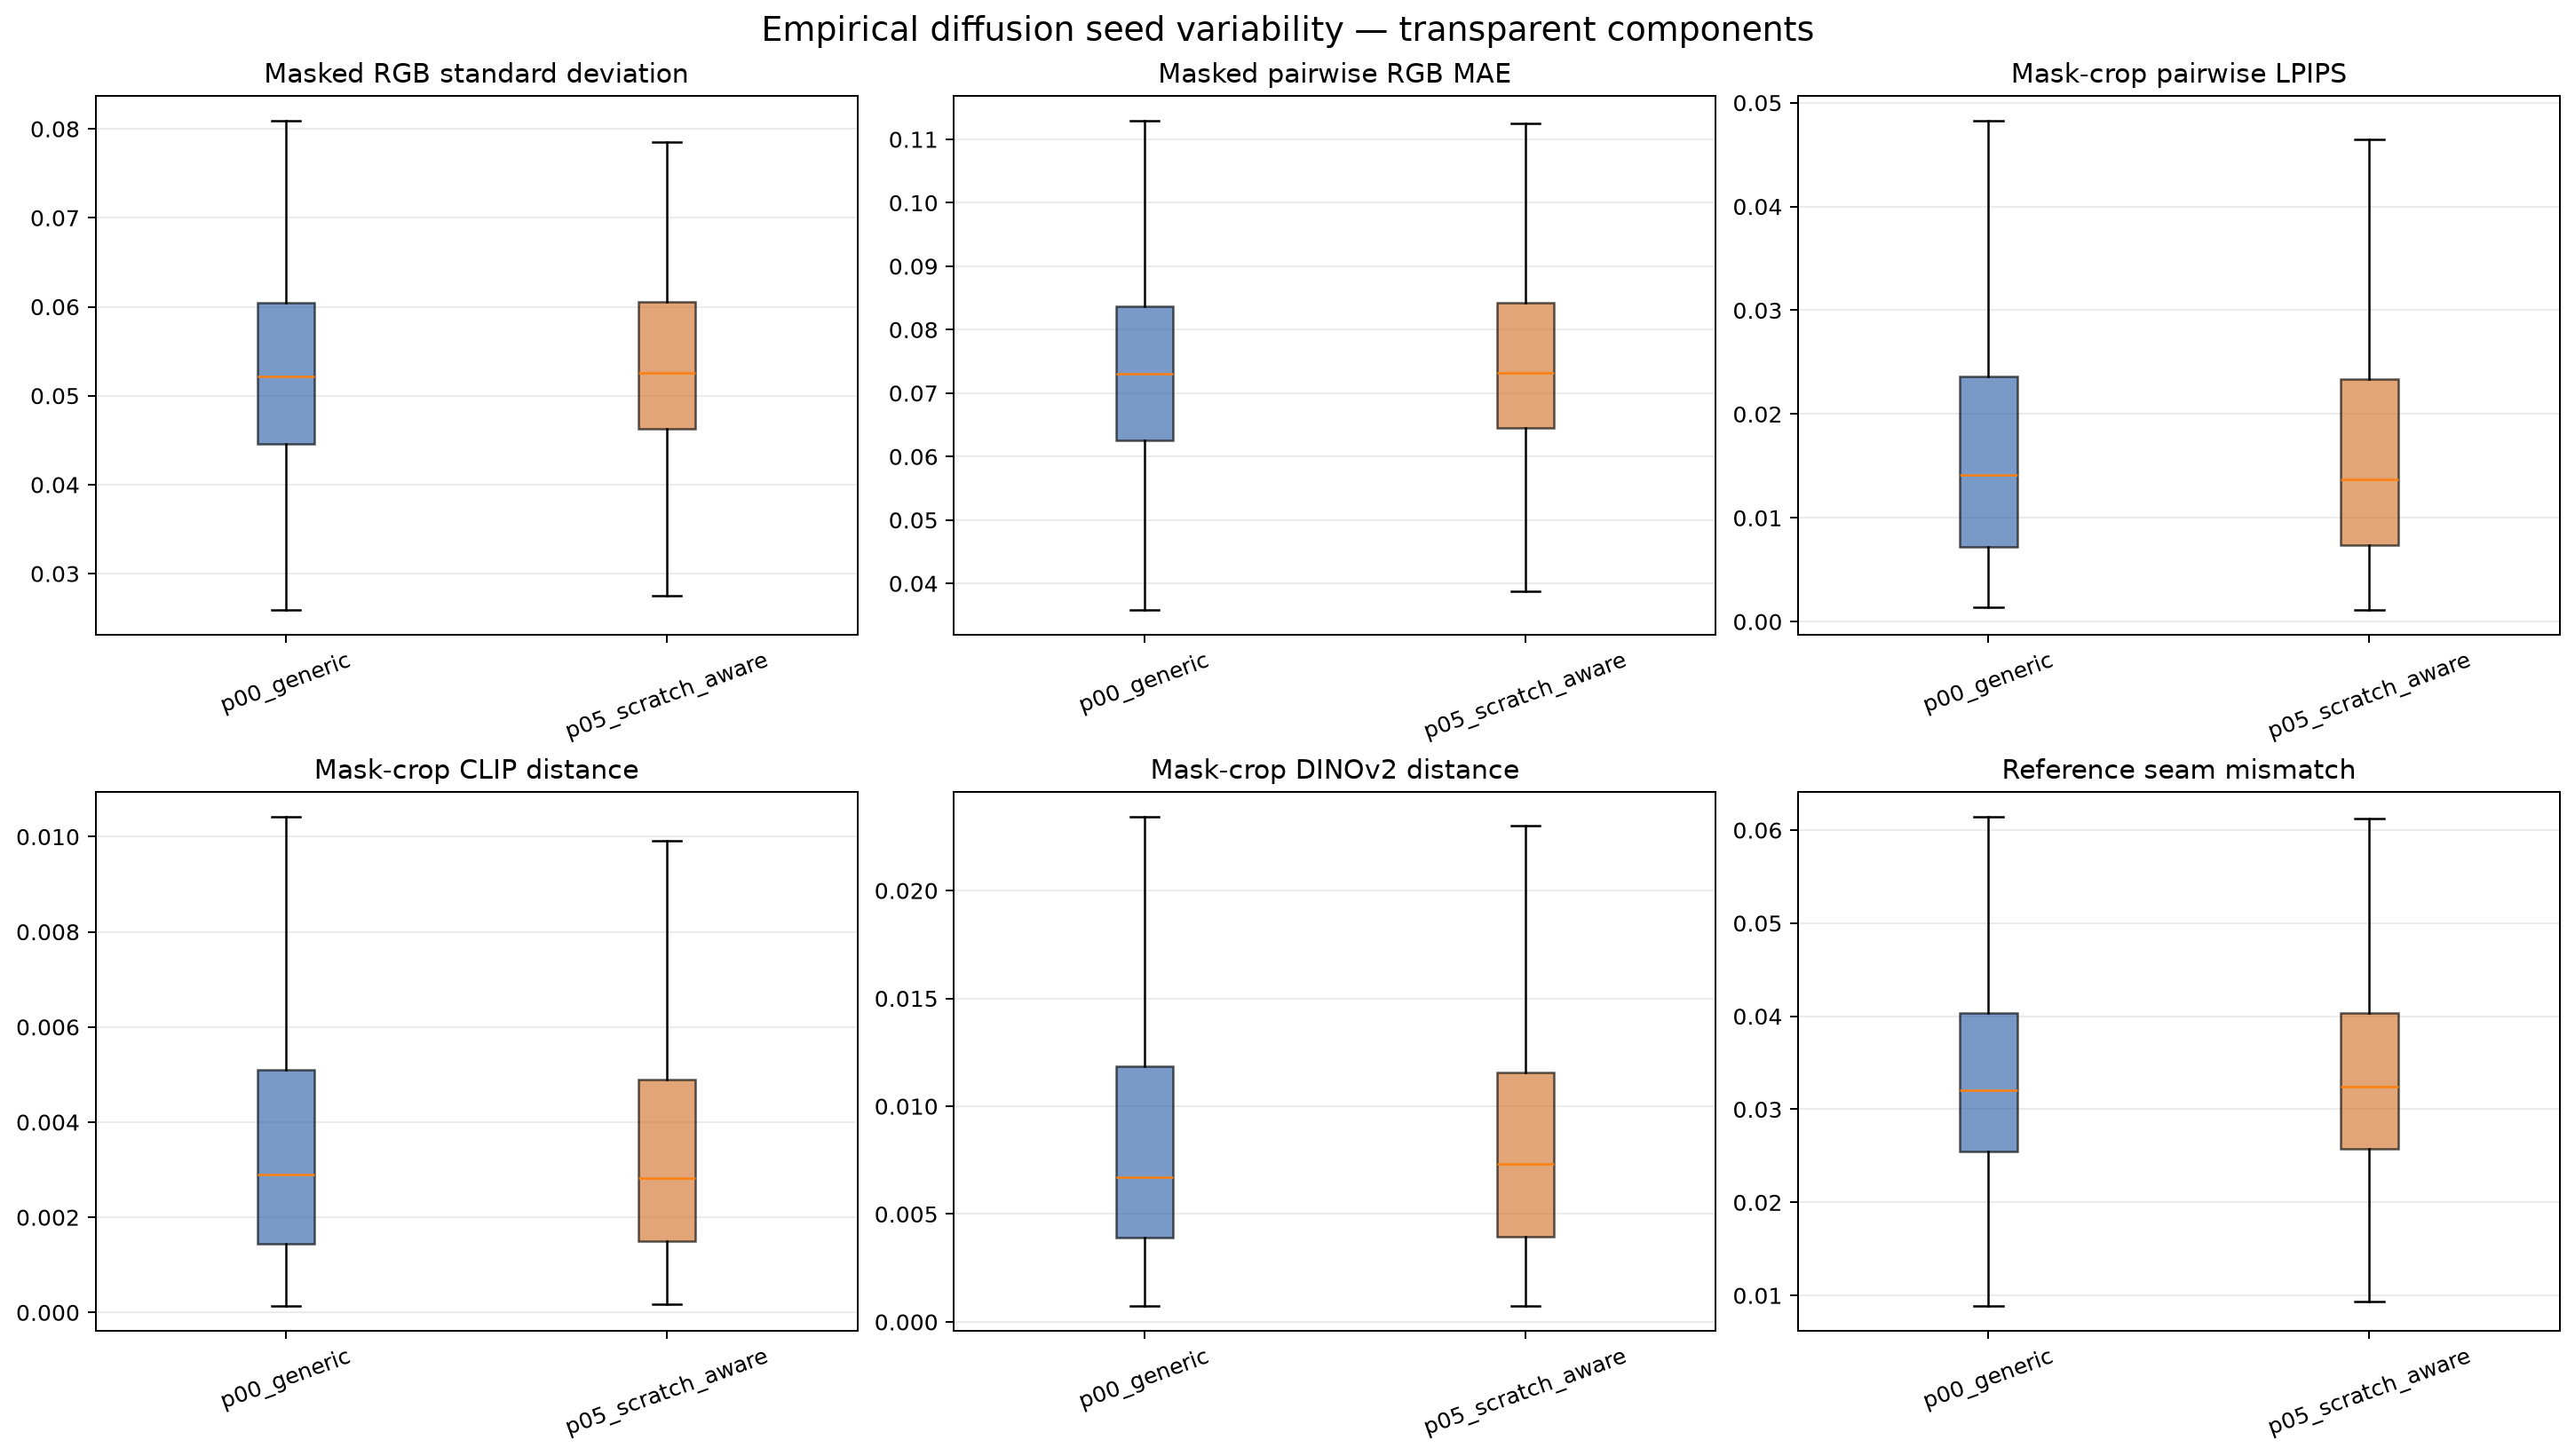

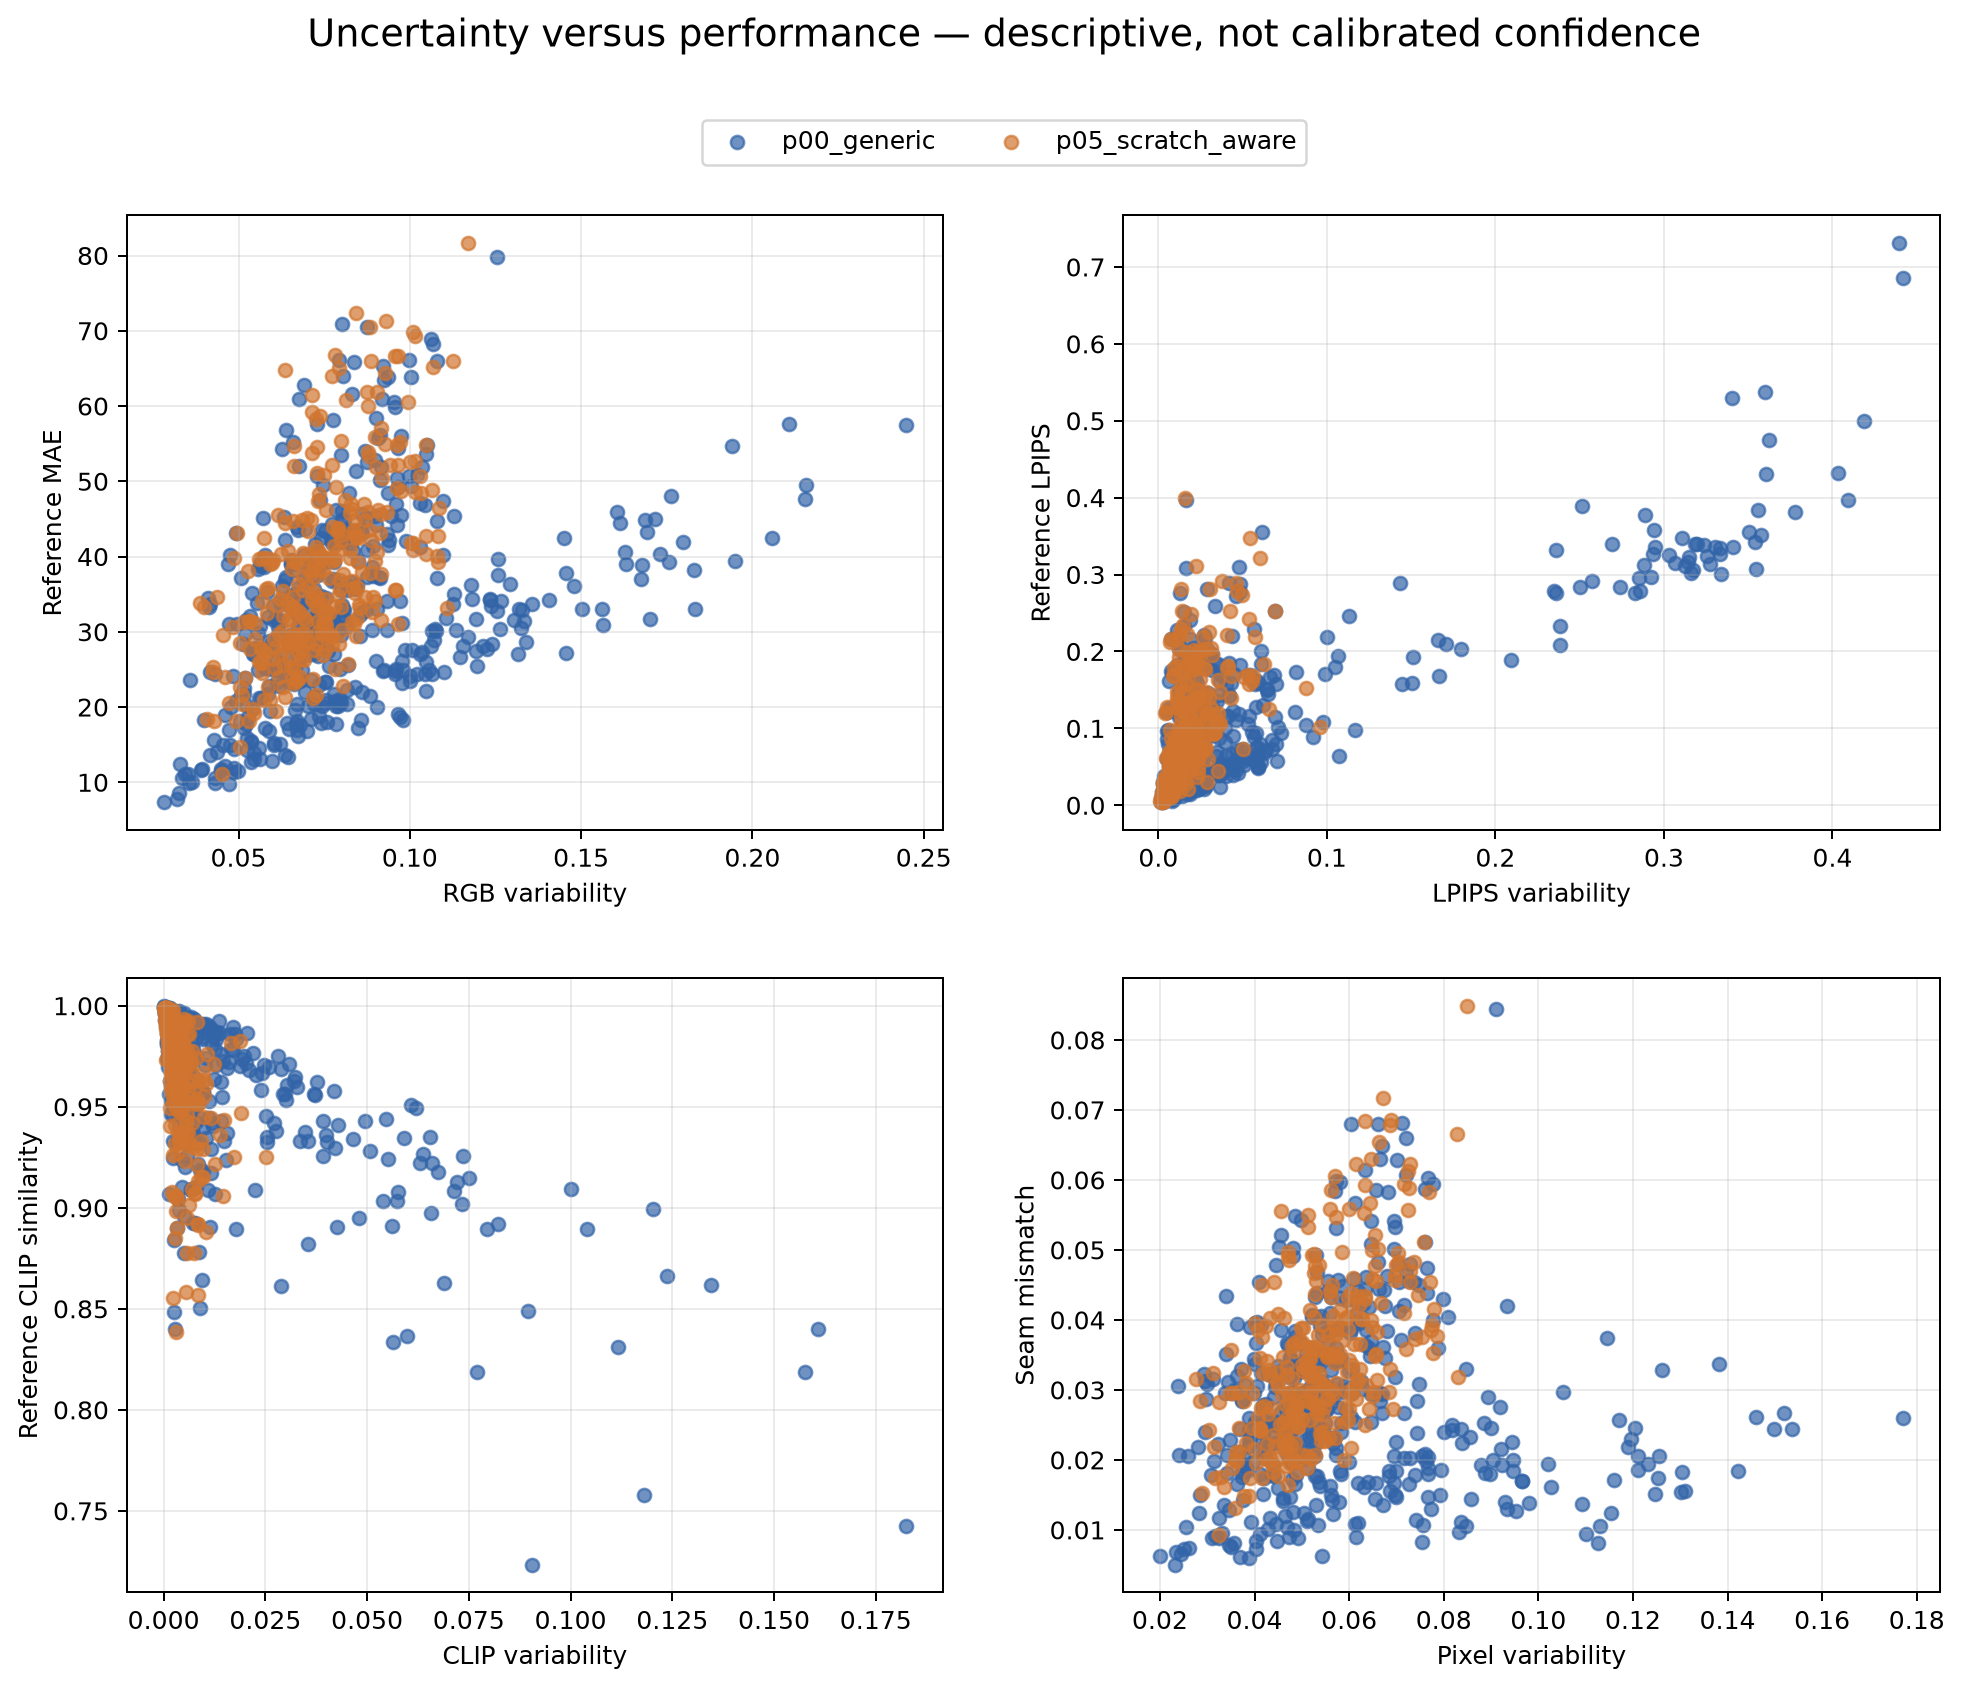

In [31]:
# ---------------------------------------------------------------------------
# Canonical descriptive figures
# ---------------------------------------------------------------------------

import importlib

from PIL import Image as PILImage
from IPython.display import Image as NotebookImage

import restoration_eval.diffusion_uncertainty as diffusion_uncertainty_helper


# Reload the helper because it was corrected after
# this notebook kernel originally imported it.
diffusion_uncertainty_helper = (
    importlib.reload(
        diffusion_uncertainty_helper
    )
)

DIFFUSION_UNCERTAINTY_MODULE_VERSION = (
    diffusion_uncertainty_helper
    .DIFFUSION_UNCERTAINTY_MODULE_VERSION
)

render_uncertainty_distributions = (
    diffusion_uncertainty_helper
    .render_uncertainty_distributions
)

render_uncertainty_vs_performance = (
    diffusion_uncertainty_helper
    .render_uncertainty_vs_performance
)

# Refresh helper checksums so the final manifest records
# the corrected helper rather than its pre-fix checksum.
HELPER_CHECKSUMS = {
    key: sha256_file(path)
    for key, path in HELPER_PATHS.items()
}


uncertainty_distributions_path = (
    render_uncertainty_distributions(
        scratch_prompt_ablation_df,
        OUTPUTS[
            "uncertainty_distributions"
        ],
    )
)

uncertainty_performance_path = (
    render_uncertainty_vs_performance(
        uncertainty_calibration_inputs_df,
        OUTPUTS[
            "uncertainty_vs_performance"
        ],
    )
)

figure_audit_records = []

for (
    figure_id,
    figure_path,
    analysis_scope,
) in (
    (
        "uncertainty_distributions",
        uncertainty_distributions_path,
        (
            "paired scratch-thin prompt "
            "ablation; 600 group rows"
        ),
    ),
    (
        "uncertainty_vs_performance",
        uncertainty_performance_path,
        (
            "all eligible Stable Diffusion "
            "groups; 780 group rows"
        ),
    ),
):
    with PILImage.open(
        figure_path
    ) as image:
        image.load()

        figure_audit_records.append(
            {
                "figure_id": figure_id,
                "path": to_repo_relative(
                    figure_path,
                    PROJECT_ROOT,
                ),
                "analysis_scope": (
                    analysis_scope
                ),
                "format": image.format,
                "mode": image.mode,
                "width": image.width,
                "height": image.height,
                "size_bytes": (
                    figure_path.stat().st_size
                ),
                "sha256": sha256_file(
                    figure_path
                ),
            }
        )

figure_audit_df = pd.DataFrame(
    figure_audit_records
)

print(
    "Reloaded diffusion-uncertainty helper:",
    DIFFUSION_UNCERTAINTY_MODULE_VERSION,
)
print("Canonical Notebook 18 figures rendered.")

display(figure_audit_df)

display(
    NotebookImage(
        filename=str(
            uncertainty_distributions_path
        )
    )
)

display(
    NotebookImage(
        filename=str(
            uncertainty_performance_path
        )
    )
)

In [32]:
# ---------------------------------------------------------------------------
# Batch 6 validation
# ---------------------------------------------------------------------------

VALIDATION_STAGE = (
    "batch_6_analysis_visualization"
)


def add_analysis_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


expected_summary_scopes = {
    "model",
    "damage_type",
    "target_damage_fraction",
    "category",
    "style_or_period",
    "experiment",
    "seed_coverage",
}

observed_summary_scopes = set(
    uncertainty_summary_tables
)

scratch_prompt_counts = (
    scratch_prompt_ablation_df[
        "prompt_variant_id"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)

expected_paired_category_counts = {
    category: 60
    for category in sorted(
        uncertainty_population_df[
            "category"
        ].astype(str).unique()
    )
}

sdxl_scope_row = (
    model_seed_coverage_df.loc[
        model_seed_coverage_df[
            "model_id"
        ].astype(str).eq(
            "sdxl_inpainting"
        )
    ]
    .iloc[0]
)

figure_files_valid = bool(
    figure_audit_df["format"].eq(
        "PNG"
    ).all()
    and (
        figure_audit_df[
            "width"
        ]
        >= 1200
    ).all()
    and (
        figure_audit_df[
            "height"
        ]
        >= 800
    ).all()
    and (
        figure_audit_df[
            "size_bytes"
        ]
        > 50_000
    ).all()
    and figure_audit_df[
        "sha256"
    ].astype(str).str.len().eq(
        64
    ).all()
)

paired_ablation_numeric_columns = [
    "generic_mean",
    "scratch_aware_mean",
    "aware_minus_generic_mean",
    "aware_minus_generic_median",
    "aware_minus_generic_q25",
    "aware_minus_generic_q75",
    "aware_lower_fraction",
    "aware_higher_fraction",
]

paired_ablation_numeric_values = (
    paired_prompt_ablation_summary_df[
        paired_ablation_numeric_columns
    ].to_numpy(dtype=float)
)

add_analysis_check(
    "required_summary_scopes",
    "All roadmap-required descriptive summary scopes are present.",
    sorted(expected_summary_scopes),
    sorted(observed_summary_scopes),
    observed_summary_scopes
    == expected_summary_scopes,
)

add_analysis_check(
    "summary_tables_nonempty",
    "Every required descriptive summary contains rows.",
    True,
    {
        name: len(frame)
        for name, frame
        in uncertainty_summary_tables.items()
    },
    all(
        len(frame) > 0
        for frame
        in uncertainty_summary_tables.values()
    ),
)

add_analysis_check(
    "scratch_ablation_rows",
    "The controlled scratch-prompt subset contains both prompts for 300 cases.",
    {
        "rows": 600,
        "prompt_counts": {
            "p00_generic": 300,
            "p05_scratch_aware": 300,
        },
    },
    {
        "rows": len(
            scratch_prompt_ablation_df
        ),
        "prompt_counts": (
            scratch_prompt_counts
        ),
    },
    (
        len(scratch_prompt_ablation_df)
        == 600
        and scratch_prompt_counts
        == {
            "p00_generic": 300,
            "p05_scratch_aware": 300,
        }
    ),
)

add_analysis_check(
    "paired_scratch_cases",
    "The prompt ablation contains exactly 300 one-to-one case pairs.",
    300,
    len(paired_scratch_prompt_df),
    len(paired_scratch_prompt_df) == 300,
)

add_analysis_check(
    "paired_category_balance",
    "The controlled prompt comparison retains 60 paintings per category.",
    expected_paired_category_counts,
    paired_category_counts,
    paired_category_counts
    == expected_paired_category_counts,
)

add_analysis_check(
    "paired_metric_count",
    "The paired analysis covers five uncertainty and ten reference components.",
    15,
    len(
        paired_prompt_ablation_summary_df
    ),
    len(
        paired_prompt_ablation_summary_df
    ) == 15,
)

add_analysis_check(
    "paired_statistics_finite",
    "All required paired descriptive statistics are finite.",
    True,
    bool(
        np.isfinite(
            paired_ablation_numeric_values
        ).all()
    ),
    bool(
        np.isfinite(
            paired_ablation_numeric_values
        ).all()
    ),
)

add_analysis_check(
    "uncertainty_direction_not_quality",
    "Uncertainty-component changes have no assigned quality-improvement direction.",
    ["descriptive_only"],
    sorted(
        paired_prompt_ablation_summary_df.loc[
            paired_prompt_ablation_summary_df[
                "metric_domain"
            ].eq("uncertainty"),
            "preferred_direction",
        ].astype(str).unique()
    ),
    set(
        paired_prompt_ablation_summary_df.loc[
            paired_prompt_ablation_summary_df[
                "metric_domain"
            ].eq("uncertainty"),
            "preferred_direction",
        ].astype(str)
    )
    == {"descriptive_only"},
)

add_analysis_check(
    "sdxl_not_applicable",
    "SDXL remains excluded because it has only one distinct seed per case.",
    {
        "distinct_seeds": 1,
        "status": (
            "not_applicable_"
            "insufficient_seed_coverage"
        ),
    },
    {
        "distinct_seeds": int(
            sdxl_scope_row[
                "distinct_seeds"
            ]
        ),
        "status": str(
            sdxl_scope_row[
                "uncertainty_status"
            ]
        ),
    },
    (
        int(
            sdxl_scope_row[
                "distinct_seeds"
            ]
        )
        == 1
        and str(
            sdxl_scope_row[
                "uncertainty_status"
            ]
        )
        == (
            "not_applicable_"
            "insufficient_seed_coverage"
        )
    ),
)

add_analysis_check(
    "diffusion_only_scope",
    "The empirical uncertainty population contains only the eligible diffusion model.",
    ["stable_diffusion_inpainting"],
    sorted(
        uncertainty_calibration_inputs_df[
            "model_id"
        ].astype(str).unique()
    ),
    set(
        uncertainty_calibration_inputs_df[
            "model_id"
        ].astype(str)
    )
    == {"stable_diffusion_inpainting"},
)

add_analysis_check(
    "canonical_figure_count",
    "Exactly two canonical Notebook 18 figures are produced.",
    2,
    len(figure_audit_df),
    len(figure_audit_df) == 2,
)

add_analysis_check(
    "canonical_figures_valid",
    "Both canonical figures are readable, sufficiently sized PNG artifacts.",
    True,
    figure_audit_df.to_dict(
        "records"
    ),
    figure_files_valid,
)

add_analysis_check(
    "distribution_figure_scope",
    "The distribution figure uses the controlled paired scratch subset.",
    (
        "paired scratch-thin prompt "
        "ablation; 600 group rows"
    ),
    str(
        figure_audit_df.set_index(
            "figure_id"
        ).loc[
            "uncertainty_distributions",
            "analysis_scope",
        ]
    ),
    str(
        figure_audit_df.set_index(
            "figure_id"
        ).loc[
            "uncertainty_distributions",
            "analysis_scope",
        ]
    )
    == (
        "paired scratch-thin prompt "
        "ablation; 600 group rows"
    ),
)

add_analysis_check(
    "performance_figure_scope",
    "The performance figure uses all 780 eligible groups.",
    (
        "all eligible Stable Diffusion "
        "groups; 780 group rows"
    ),
    str(
        figure_audit_df.set_index(
            "figure_id"
        ).loc[
            "uncertainty_vs_performance",
            "analysis_scope",
        ]
    ),
    str(
        figure_audit_df.set_index(
            "figure_id"
        ).loc[
            "uncertainty_vs_performance",
            "analysis_scope",
        ]
    )
    == (
        "all eligible Stable Diffusion "
        "groups; 780 group rows"
    ),
)

add_analysis_check(
    "combined_index_absent_in_analysis",
    "Analysis retains transparent components and no combined index.",
    False,
    bool(
        uncertainty_calibration_inputs_df[
            "combined_uncertainty_index_available"
        ].astype(bool).any()
    ),
    not uncertainty_calibration_inputs_df[
        "combined_uncertainty_index_available"
    ].astype(bool).any(),
)

add_analysis_check(
    "no_extra_summary_csvs",
    "Required subgroup summaries remain in memory rather than creating redundant CSVs.",
    False,
    any(
        OUTPUT_DIRECTORIES[
            "metrics"
        ].glob("*summary*.csv")
    ),
    not any(
        OUTPUT_DIRECTORIES[
            "metrics"
        ].glob("*summary*.csv")
    ),
)

batch_6_validation_df = (
    VALIDATION.to_dataframe()
)

display(
    batch_6_validation_df.loc[
        batch_6_validation_df[
            "validation_stage"
        ].eq(VALIDATION_STAGE)
    ].reset_index(drop=True)
)

print("Notebook 18 Batch 6 checks assembled.")
print(
    "Batch 6 checks added:",
    int(
        batch_6_validation_df[
            "validation_stage"
        ].eq(VALIDATION_STAGE).sum()
    ),
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_6_analysis_visualization,required_summary_scopes,All roadmap-required descriptive summary scope...,blocking,"[""category"", ""damage_type"", ""experiment"", ""mod...","[""category"", ""damage_type"", ""experiment"", ""mod...",True,
1,batch_6_analysis_visualization,summary_tables_nonempty,Every required descriptive summary contains rows.,blocking,True,"{""category"": 5, ""damage_type"": 4, ""experiment""...",True,
2,batch_6_analysis_visualization,scratch_ablation_rows,The controlled scratch-prompt subset contains ...,blocking,"{""prompt_counts"": {""p00_generic"": 300, ""p05_sc...","{""prompt_counts"": {""p00_generic"": 300, ""p05_sc...",True,
3,batch_6_analysis_visualization,paired_scratch_cases,The prompt ablation contains exactly 300 one-t...,blocking,300,300,True,
4,batch_6_analysis_visualization,paired_category_balance,The controlled prompt comparison retains 60 pa...,blocking,"{""abstraction_surrealism"": 60, ""architecture_s...","{""abstraction_surrealism"": 60, ""architecture_s...",True,
5,batch_6_analysis_visualization,paired_metric_count,The paired analysis covers five uncertainty an...,blocking,15,15,True,
6,batch_6_analysis_visualization,paired_statistics_finite,All required paired descriptive statistics are...,blocking,True,True,True,
7,batch_6_analysis_visualization,uncertainty_direction_not_quality,Uncertainty-component changes have no assigned...,blocking,"[""descriptive_only""]","[""descriptive_only""]",True,
8,batch_6_analysis_visualization,sdxl_not_applicable,SDXL remains excluded because it has only one ...,blocking,"{""distinct_seeds"": 1, ""status"": ""not_applicabl...","{""distinct_seeds"": 1, ""status"": ""not_applicabl...",True,
9,batch_6_analysis_visualization,diffusion_only_scope,The empirical uncertainty population contains ...,blocking,"[""stable_diffusion_inpainting""]","[""stable_diffusion_inpainting""]",True,


Notebook 18 Batch 6 checks assembled.
Batch 6 checks added: 16


In [33]:
# ---------------------------------------------------------------------------
# Batch 6 gate
# ---------------------------------------------------------------------------

batch_6_summary = VALIDATION.summary()

print("Notebook 18 Batch 6 summary")
print(
    "Total validation checks:",
    batch_6_summary["check_count"],
)
print(
    "Blocking failures across Batches 1–6:",
    batch_6_summary[
        "blocking_failure_count"
    ],
)
print(
    "Controlled scratch prompt pairs:",
    len(paired_scratch_prompt_df),
)
print(
    "Descriptive comparison metrics:",
    len(
        paired_prompt_ablation_summary_df
    ),
)
print(
    "Canonical figures:",
    figure_audit_df[
        "path"
    ].tolist(),
)
print(
    "Combined uncertainty index retained:",
    False,
)

if VALIDATION.blocking_failures:
    display(
        batch_6_validation_df.loc[
            (
                batch_6_validation_df[
                    "severity"
                ].eq("blocking")
            )
            & (
                ~batch_6_validation_df[
                    "passed"
                ]
            )
        ].reset_index(drop=True)
    )

    raise RuntimeError(
        "Notebook 18 Batch 6 has blocking "
        "validation failures."
    )

print(
    "Batch 6 passed: required subgroup summaries, "
    "a controlled 300-painting prompt ablation, "
    "the SDXL coverage limitation, and two "
    "transparent canonical figures are validated "
    "without a composite uncertainty score."
)

Notebook 18 Batch 6 summary
Total validation checks: 135
Blocking failures across Batches 1–6: 0
Controlled scratch prompt pairs: 300
Descriptive comparison metrics: 15
Canonical figures: ['outputs/18_diffusion_uncertainty_analysis/figures/uncertainty_distributions.png', 'outputs/18_diffusion_uncertainty_analysis/figures/uncertainty_vs_performance.png']
Combined uncertainty index retained: False
Batch 6 passed: required subgroup summaries, a controlled 300-painting prompt ablation, the SDXL coverage limitation, and two transparent canonical figures are validated without a composite uncertainty score.


## Batch 7 — Canonical persistence and completion gate

This batch persists the two canonical metric tables, independently reloads
and validates them, removes only the validated Notebook 18 work checkpoints,
and writes the consolidated validation table, normalized artifact manifest,
universal run manifest, and project-path registry entries.

The completion gate verifies exact output ownership, schema compliance,
scientific row counts, artifact checksums, roadmap traceability, downstream
evidence limitations, and completed/refactored status.

Notebook 18 deliberately produces no standalone report and no persisted
per-case heatmaps. Notebook 19 owns spatial uncertainty maps.

In [34]:
# Batch 7 — completion utilities and roadmap traceability
import time

from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    sha256_path,
    write_run_manifest,
)
from restoration_eval.paths import (
    upsert_project_path_artifacts,
    write_project_paths_registry,
)
from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    VALIDATION_CHECKS_SCHEMA,
)

FINAL_ARTIFACT_RECORD_COUNT = 5
FINAL_CANONICAL_FILE_COUNT = 7


def persist_canonical_csv(dataframe, destination):
    result = diffusion_uncertainty_helper.write_dataframe_checkpoint(
        dataframe,
        destination,
        attempts=int(EXECUTION_POLICY["atomic_replace_attempts"]),
        retry_delay_seconds=float(
            EXECUTION_POLICY["atomic_replace_retry_seconds"]
        ),
    )
    if result["status"] != "canonical":
        raise PermissionError(
            "Canonical CSV remained locked; recovery file: "
            f"{result['path']}. Close the viewer and rerun this cell."
        )
    return result


def call_with_permission_retry(
    function, *args, attempts=8, initial_retry_seconds=0.125, **kwargs
):
    delay = float(initial_retry_seconds)
    for attempt in range(1, int(attempts) + 1):
        try:
            return {
                "result": function(*args, **kwargs),
                "attempts": attempt,
            }
        except PermissionError:
            if attempt == attempts:
                raise
            time.sleep(delay)
            delay = min(delay * 2.0, 2.0)


def complete_validation_summary():
    frame = VALIDATION.to_dataframe()
    summary = VALIDATION.summary()
    stages = []
    for stage, rows in frame.groupby("validation_stage", sort=False):
        passed = rows["passed"].astype(bool)
        stages.append({
            "validation_stage": str(stage),
            "check_count": int(len(rows)),
            "passed_count": int(passed.sum()),
            "failed_count": int((~passed).sum()),
            "blocking_failure_count": int(
                ((~passed) & rows["severity"].eq("blocking")).sum()
            ),
            "warning_failure_count": int(
                ((~passed) & rows["severity"].eq("warning")).sum()
            ),
        })
    return {
        **summary,
        "warning_failure_count": int(
            ((~frame["passed"].astype(bool))
             & frame["severity"].eq("warning")).sum()
        ),
        "stages": stages,
    }


requirement_traceability_records = []


def record_requirement(requirement, implemented, evidence):
    requirement_traceability_records.append({
        "requirement": requirement,
        "implemented": bool(implemented),
        "evidence": evidence,
    })


seeds_by_group = uncertainty_population_df.groupby(
    "uncertainty_group_id"
)["seed"].apply(lambda values: tuple(sorted(values.astype(int))))

record_requirement(
    "Consume repeated-seed candidates without restoration inference",
    len(uncertainty_population_df) == EXPECTED_COUNTS["candidates"],
    "3,120 completed Notebook 11 candidates; no restoration inference",
)
record_requirement(
    "Validate exact seed coverage",
    set(seeds_by_group) == {(2026, 2027, 2028, 2029)},
    "780 prompt-specific groups, each with seeds 2026-2029",
)
record_requirement(
    "Candidate-to-candidate image variation",
    len(full_image_metrics_df)
    == EXPECTED_COUNTS["pixel_group_summary_rows"]
    + EXPECTED_COUNTS["pixel_pair_rows"],
    "RGB standard deviation and pairwise differences",
)
record_requirement(
    "Per-pixel variability",
    observed_complete_family_counts.get("pixel_variability")
    == EXPECTED_COUNTS["pixel_group_summary_rows"],
    "Mean and p95 per-pixel RGB standard deviation",
)
record_requirement(
    "Six canonical scalar regions",
    set(full_image_metrics_df["region_id"].astype(str))
    == set(REGION_POLICY["pixel_regions"]),
    "|".join(REGION_POLICY["pixel_regions"]),
)
record_requirement(
    "Pairwise LPIPS variation",
    len(full_lpips_metrics_df) == EXPECTED_COUNTS["lpips_pair_rows"],
    "Content and mask-bounding-box crops",
)
record_requirement(
    "Pairwise CLIP and DINOv2 variation",
    len(full_feature_metrics_df) == EXPECTED_COUNTS["feature_pair_rows"],
    "Saved Notebook 15 embeddings",
)
record_requirement(
    "Seed-level reference metrics",
    len(seed_reference_metrics_df) == EXPECTED_COUNTS["seed_reference_rows"],
    "Ten reference components per eligible candidate",
)
record_requirement(
    "Transparent components without a combined index",
    not full_uncertainty_metrics_df["is_combined_index"].astype(bool).any(),
    "No combined uncertainty score",
)
record_requirement(
    "Required subgroup summaries",
    set(uncertainty_summary_tables) == {
        "model", "damage_type", "target_damage_fraction",
        "category", "style_or_period", "experiment", "seed_coverage",
    },
    "Seven in-memory summary scopes",
)
record_requirement(
    "Controlled prompt ablation",
    len(paired_scratch_prompt_df) == 300,
    "Generic and scratch-aware prompts paired across 300 paintings",
)
record_requirement(
    "Conditional SDXL comparison",
    len(completed_sdxl_df) == EXPECTED_COUNTS["sdxl_candidates"]
    and int(sdxl_scope_row["distinct_seeds"]) == 1
    and sdxl_scope_row["uncertainty_status"]
    == POPULATION_POLICY["sdxl_policy"],
    "24 completed single-seed candidates; uncertainty not applicable",
)
record_requirement(
    "Reference-metric association inputs",
    len(uncertainty_calibration_inputs_df)
    == EXPECTED_COUNTS["calibration_rows"],
    "MAE, PSNR, SSIM, LPIPS, CLIP and DINOv2 summaries",
)
record_requirement(
    "Texture, colour and seam association inputs",
    all(column in uncertainty_calibration_inputs_df for column in (
        "texture_error_p95_crop_mean",
        "colour_delta_e_masked_mean",
        "seam_gradient_mismatch_mean",
        "seam_ssim_error_mean",
    )),
    "Notebook 17 local-consistency components",
)
record_requirement(
    "Downstream semantic and review evidence availability",
    not availability_values.any().any(),
    "Unavailable pending downstream producers",
)
record_requirement(
    "Empirical proxy, not calibrated confidence",
    EVIDENCE_POLICY["interpretation"]
    == "empirical_seed_variability_proxy_not_calibrated_confidence",
    "Interpretation policy and figure wording",
)
record_requirement(
    "Low uncertainty does not prove correctness",
    not bool(EVIDENCE_POLICY["low_uncertainty_proves_correctness"]),
    "Scientific limitation retained",
)
record_requirement(
    "Deterministic models use robustness or sensitivity terminology",
    set(uncertainty_calibration_inputs_df["model_id"].astype(str))
    == {"stable_diffusion_inpainting"},
    "Telea, LaMa and HINT excluded from diffusion uncertainty",
)
record_requirement(
    "Notebook 19 owns persisted spatial maps",
    not bool(EVIDENCE_POLICY["persisted_heatmaps"])
    and EVIDENCE_POLICY["spatial_map_owner"] == "Notebook 19",
    "Notebook 18 persists scalar evidence only",
)
record_requirement(
    "No standalone Notebook 18 report",
    "report" not in OUTPUTS,
    "Canonical output contract has no report",
)

requirement_traceability_df = pd.DataFrame(requirement_traceability_records)
traceability_failures_df = requirement_traceability_df.loc[
    ~requirement_traceability_df["implemented"]
].copy()

print(
    "Roadmap responsibilities:",
    len(requirement_traceability_df),
    "| missing:",
    len(traceability_failures_df),
)
display(requirement_traceability_df)

Roadmap responsibilities: 20 | missing: 0


,requirement,implemented,evidence
0,Consume repeated-seed candidates without resto...,True,"3,120 completed Notebook 11 candidates; no res..."
1,Validate exact seed coverage,True,"780 prompt-specific groups, each with seeds 20..."
2,Candidate-to-candidate image variation,True,RGB standard deviation and pairwise differences
3,Per-pixel variability,True,Mean and p95 per-pixel RGB standard deviation
4,Six canonical scalar regions,True,full_image|content_region|masked_region|mask_b...
5,Pairwise LPIPS variation,True,Content and mask-bounding-box crops
6,Pairwise CLIP and DINOv2 variation,True,Saved Notebook 15 embeddings
7,Seed-level reference metrics,True,Ten reference components per eligible candidate
8,Transparent components without a combined index,True,No combined uncertainty score
9,Required subgroup summaries,True,Seven in-memory summary scopes


In [35]:
# ---------------------------------------------------------------------------
# Reload the serialization-corrected helper
# ---------------------------------------------------------------------------

import importlib

diffusion_uncertainty_helper = (
    importlib.reload(
        diffusion_uncertainty_helper
    )
)

DIFFUSION_UNCERTAINTY_MODULE_VERSION = (
    diffusion_uncertainty_helper
    .DIFFUSION_UNCERTAINTY_MODULE_VERSION
)

validate_uncertainty_metrics = (
    diffusion_uncertainty_helper
    .validate_uncertainty_metrics
)

validate_uncertainty_calibration_inputs = (
    diffusion_uncertainty_helper
    .validate_uncertainty_calibration_inputs
)

HELPER_CHECKSUMS = {
    key: sha256_file(path)
    for key, path in HELPER_PATHS.items()
}

if (
    DIFFUSION_UNCERTAINTY_MODULE_VERSION
    != "1.0.3"
):
    raise RuntimeError(
        "Expected diffusion-uncertainty helper "
        "version 1.0.3, observed "
        f"{DIFFUSION_UNCERTAINTY_MODULE_VERSION}."
    )


# ---------------------------------------------------------------------------
# Deterministic canonical tables
# ---------------------------------------------------------------------------

canonical_uncertainty_metrics_df = (
    full_uncertainty_metrics_df.loc[
        :,
        DIFFUSION_UNCERTAINTY_SCHEMA
        .required_columns,
    ]
    .sort_values(
        [
            "uncertainty_group_id",
            "observation_level",
            "metric_family",
            "metric_name",
            "region_id",
            "candidate_id",
            "candidate_id_a",
            "candidate_id_b",
            "summary_statistic",
        ],
        kind="stable",
        na_position="first",
    )
    .reset_index(drop=True)
)

canonical_calibration_inputs_df = (
    uncertainty_calibration_inputs_df.loc[
        :,
        UNCERTAINTY_CALIBRATION_INPUTS_SCHEMA
        .required_columns,
    ]
    .sort_values(
        [
            "case_id",
            "prompt_variant_id",
            "configuration_id",
            "uncertainty_group_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Validate before persistence
# ---------------------------------------------------------------------------

canonical_metric_validation = (
    validate_uncertainty_metrics(
        canonical_uncertainty_metrics_df,
        uncertainty_population_df,
        config=UNCERTAINTY_CONFIG_DOCUMENT,
    )
)

canonical_calibration_validation = (
    validate_uncertainty_calibration_inputs(
        canonical_calibration_inputs_df,
        config=UNCERTAINTY_CONFIG_DOCUMENT,
    )
)

print(
    "Pre-persistence metric validation:",
    canonical_metric_validation["passed"],
)
print(
    "Pre-persistence calibration validation:",
    canonical_calibration_validation[
        "passed"
    ],
)

if not (
    canonical_metric_validation["passed"]
    and canonical_calibration_validation[
        "passed"
    ]
):
    raise RuntimeError(
        "Canonical tables failed validation "
        "before persistence."
    )


# ---------------------------------------------------------------------------
# Persist canonical CSVs
# ---------------------------------------------------------------------------

metric_write_result = persist_canonical_csv(
    canonical_uncertainty_metrics_df,
    OUTPUTS["uncertainty_metrics"],
)

calibration_write_result = (
    persist_canonical_csv(
        canonical_calibration_inputs_df,
        OUTPUTS["calibration_inputs"],
    )
)


# ---------------------------------------------------------------------------
# Independent CSV reload
#
# keep_default_na=False preserves intentionally blank
# optional issue and candidate-reference fields.
# ---------------------------------------------------------------------------

reloaded_uncertainty_metrics_df = (
    pd.read_csv(
        OUTPUTS["uncertainty_metrics"],
        low_memory=False,
        keep_default_na=False,
    )
)

reloaded_calibration_inputs_df = (
    pd.read_csv(
        OUTPUTS["calibration_inputs"],
        low_memory=False,
        keep_default_na=False,
    )
)

reloaded_metric_validation = (
    validate_uncertainty_metrics(
        reloaded_uncertainty_metrics_df,
        uncertainty_population_df,
        config=UNCERTAINTY_CONFIG_DOCUMENT,
    )
)

reloaded_calibration_validation = (
    validate_uncertainty_calibration_inputs(
        reloaded_calibration_inputs_df,
        config=UNCERTAINTY_CONFIG_DOCUMENT,
    )
)

print(
    "Reloaded metric validation:",
    reloaded_metric_validation["passed"],
)
print(
    "Reloaded calibration validation:",
    reloaded_calibration_validation[
        "passed"
    ],
)

if not reloaded_metric_validation[
    "passed"
]:
    print(
        json.dumps(
            reloaded_metric_validation,
            indent=2,
            sort_keys=True,
        )
    )

if not reloaded_calibration_validation[
    "passed"
]:
    print(
        json.dumps(
            reloaded_calibration_validation,
            indent=2,
            sort_keys=True,
        )
    )

if not (
    reloaded_metric_validation["passed"]
    and reloaded_calibration_validation[
        "passed"
    ]
):
    raise RuntimeError(
        "Persisted canonical tables failed "
        "independent reload validation."
    )


# ---------------------------------------------------------------------------
# Remove only validated Notebook 18 work checkpoints
# ---------------------------------------------------------------------------

work_root = NOTEBOOK_OUTPUT_ROOT / "work"

approved_work_files = set()

for checkpoint_path in WORK_PATHS.values():
    if checkpoint_path.is_file():
        approved_work_files.add(
            checkpoint_path.resolve()
        )

    approved_work_files.update(
        path.resolve()
        for path
        in checkpoint_path.parent.glob(
            (
                checkpoint_path.stem
                + ".recovery-*"
                + checkpoint_path.suffix
            )
        )
        if path.is_file()
    )

observed_work_files = (
    {
        path.resolve()
        for path in work_root.rglob("*")
        if path.is_file()
    }
    if work_root.exists()
    else set()
)

unexpected_work_files = (
    observed_work_files
    - approved_work_files
)

if unexpected_work_files:
    raise RuntimeError(
        "Unexpected work files prevent cleanup: "
        + ", ".join(
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in sorted(
                unexpected_work_files
            )
        )
    )

for work_file in sorted(
    approved_work_files
):
    work_file.unlink(
        missing_ok=True
    )

if (
    work_root.exists()
    and not any(work_root.iterdir())
):
    work_root.rmdir()


# ---------------------------------------------------------------------------
# Re-audit final figures
# ---------------------------------------------------------------------------

final_figure_audit_records = []

for figure_key in (
    "uncertainty_distributions",
    "uncertainty_vs_performance",
):
    figure_path = OUTPUTS[figure_key]

    with PILImage.open(
        figure_path
    ) as image:
        image.load()

        final_figure_audit_records.append(
            {
                "figure_key": figure_key,
                "path": to_repo_relative(
                    figure_path,
                    PROJECT_ROOT,
                ),
                "format": image.format,
                "mode": image.mode,
                "width": image.width,
                "height": image.height,
                "size_bytes": (
                    figure_path.stat().st_size
                ),
                "sha256": sha256_file(
                    figure_path
                ),
            }
        )

final_figure_audit_df = pd.DataFrame(
    final_figure_audit_records
)

print("Canonical tables persisted and reloaded.")
print(
    "Active helper version:",
    DIFFUSION_UNCERTAINTY_MODULE_VERSION,
)
print(
    "Uncertainty metric rows:",
    len(reloaded_uncertainty_metrics_df),
)
print(
    "Calibration rows:",
    len(reloaded_calibration_inputs_df),
)
print(
    "Metric write status:",
    metric_write_result["status"],
)
print(
    "Calibration write status:",
    calibration_write_result["status"],
)
print(
    "Temporary work directory exists:",
    work_root.exists(),
)

display(final_figure_audit_df)

Pre-persistence metric validation: True
Pre-persistence calibration validation: True
Reloaded metric validation: True
Reloaded calibration validation: True
Canonical tables persisted and reloaded.
Active helper version: 1.0.3
Uncertainty metric rows: 124800
Calibration rows: 780
Metric write status: canonical
Calibration write status: canonical
Temporary work directory exists: False


,figure_key,path,format,mode,width,height,size_bytes,sha256
0,uncertainty_distributions,outputs/18_diffusion_uncertainty_analysis/figu...,PNG,RGBA,2900,1640,206441,d6b2f20bf72e84fc72e3cef82161a42da5a523acb2190f...
1,uncertainty_vs_performance,outputs/18_diffusion_uncertainty_analysis/figu...,PNG,RGBA,1962,1688,526972,d904a8a7b21bc898e8f58fecd88bc680de1a99769d3cd6...


In [36]:
# Batch 7 — safely rerunnable completion validation
FINAL_VALIDATION_STAGE = "batch_7_completion_gate"
retained_checks = [
    check for check in VALIDATION.checks
    if check.validation_stage != FINAL_VALIDATION_STAGE
]
VALIDATION = ValidationCollector()
VALIDATION.extend(retained_checks)


def add_completion_check(
    check_id, description, expected, observed, passed,
    details="", severity="blocking"
):
    VALIDATION.add(
        validation_stage=FINAL_VALIDATION_STAGE,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


current_helper_checksums = {
    key: sha256_file(path) for key, path in HELPER_PATHS.items()
}
owned_files = {
    path.resolve() for path in NOTEBOOK_OUTPUT_ROOT.rglob("*")
    if path.is_file()
}
scientific_files = {
    OUTPUTS[key].resolve() for key in (
        "uncertainty_metrics",
        "calibration_inputs",
        "uncertainty_distributions",
        "uncertainty_vs_performance",
    )
}
handoff_files = {
    OUTPUTS[key].resolve() for key in (
        "validation", "artifacts", "run_manifest"
    )
}
allowed_files = scientific_files | handoff_files
figures_valid = bool(
    len(final_figure_audit_df) == 2
    and final_figure_audit_df["format"].eq("PNG").all()
    and final_figure_audit_df["width"].ge(1200).all()
    and final_figure_audit_df["height"].ge(800).all()
    and final_figure_audit_df["size_bytes"].gt(50_000).all()
    and final_figure_audit_df["sha256"].astype(str).str.len().eq(64).all()
)

add_completion_check(
    "persisted_uncertainty_validation",
    "Reloaded uncertainty metrics pass canonical validation.",
    True, reloaded_metric_validation,
    reloaded_metric_validation["passed"],
)
add_completion_check(
    "persisted_calibration_validation",
    "Reloaded calibration inputs pass canonical validation.",
    True, reloaded_calibration_validation,
    reloaded_calibration_validation["passed"],
)
observed_rows = {
    "uncertainty_metrics": len(reloaded_uncertainty_metrics_df),
    "calibration_inputs": len(reloaded_calibration_inputs_df),
}
expected_rows = {
    "uncertainty_metrics": EXPECTED_COUNTS["uncertainty_metric_rows"],
    "calibration_inputs": EXPECTED_COUNTS["calibration_rows"],
}
add_completion_check(
    "persisted_row_counts",
    "Both canonical tables have their contracted row counts.",
    expected_rows, observed_rows, observed_rows == expected_rows,
)
add_completion_check(
    "canonical_figures",
    "Both canonical figures are readable thesis-scale PNGs.",
    True, final_figure_audit_df.to_dict("records"), figures_valid,
)
add_completion_check(
    "roadmap_traceability",
    "Every Notebook 18 responsibility has implementation evidence.",
    0, len(traceability_failures_df),
    traceability_failures_df.empty,
    details=traceability_failures_df.to_dict("records"),
)
add_completion_check(
    "pre_manifest_output_contract",
    "The four scientific outputs exist, with no unapproved file; "
    "prior handoff files are allowed when this stage is rerun.",
    {
        "required": sorted(to_repo_relative(p, PROJECT_ROOT)
                           for p in scientific_files),
        "allowed": sorted(to_repo_relative(p, PROJECT_ROOT)
                          for p in allowed_files),
    },
    sorted(to_repo_relative(p, PROJECT_ROOT) for p in owned_files),
    scientific_files.issubset(owned_files)
    and owned_files.issubset(allowed_files),
)
add_completion_check(
    "temporary_work_cleanup",
    "Notebook 18 work checkpoints and directory are removed.",
    False, work_root.exists(), not work_root.exists(),
)
add_completion_check(
    "helper_version",
    "The approved diffusion-uncertainty helper is active.",
    "1.0.3", DIFFUSION_UNCERTAINTY_MODULE_VERSION,
    DIFFUSION_UNCERTAINTY_MODULE_VERSION == "1.0.3",
)
add_completion_check(
    "helper_checksums_current",
    "Helper checksums match the current repository files.",
    current_helper_checksums, HELPER_CHECKSUMS,
    current_helper_checksums == HELPER_CHECKSUMS,
)
combined_index_observed = {
    "metric_rows": int(
        reloaded_uncertainty_metrics_df["is_combined_index"]
        .astype(bool).sum()
    ),
    "calibration_available": bool(
        reloaded_calibration_inputs_df[
            "combined_uncertainty_index_available"
        ].astype(bool).any()
    ),
}
add_completion_check(
    "combined_index_absent",
    "No combined uncertainty index exists in either table.",
    {"metric_rows": 0, "calibration_available": False},
    combined_index_observed,
    combined_index_observed
    == {"metric_rows": 0, "calibration_available": False},
)
downstream_flags = {
    column: bool(
        reloaded_calibration_inputs_df[column].astype(bool).any()
    )
    for column in availability_columns
}
add_completion_check(
    "downstream_evidence_flags",
    "Downstream semantic, human-review and failure evidence "
    "remains explicitly unavailable.",
    {column: False for column in availability_columns},
    downstream_flags,
    not any(downstream_flags.values()),
)
sdxl_status = str(sdxl_scope_row["uncertainty_status"])
add_completion_check(
    "sdxl_limitation_retained",
    "Single-seed SDXL evidence is excluded from uncertainty.",
    {
        "completed": EXPECTED_COUNTS["sdxl_candidates"],
        "distinct_seeds": 1,
        "status": POPULATION_POLICY["sdxl_policy"],
    },
    {
        "completed": len(completed_sdxl_df),
        "distinct_seeds": int(sdxl_scope_row["distinct_seeds"]),
        "status": sdxl_status,
    },
    len(completed_sdxl_df) == EXPECTED_COUNTS["sdxl_candidates"]
    and int(sdxl_scope_row["distinct_seeds"]) == 1
    and sdxl_status == POPULATION_POLICY["sdxl_policy"],
)
add_completion_check(
    "no_report_or_heatmaps",
    "Notebook 18 creates neither a standalone report "
    "nor persisted heatmaps.",
    {"report_declared": False, "persisted_heatmaps": False},
    {
        "report_declared": "report" in OUTPUTS,
        "persisted_heatmaps": bool(EVIDENCE_POLICY["persisted_heatmaps"]),
    },
    "report" not in OUTPUTS
    and not bool(EVIDENCE_POLICY["persisted_heatmaps"]),
)

validation_frame = VALIDATION.to_dataframe()
warning_failures = int(
    ((~validation_frame["passed"].astype(bool))
     & validation_frame["severity"].eq("warning")).sum()
)
add_completion_check(
    "zero_warning_failures",
    "No warning-level validation failure remains.",
    0, warning_failures, warning_failures == 0,
)
add_completion_check(
    "zero_blocking_failures",
    "No blocking failure remains before final persistence.",
    0, len(VALIDATION.blocking_failures),
    not VALIDATION.blocking_failures,
)
VALIDATION.raise_for_blocking()
completion_validation_df = VALIDATION.to_dataframe()
display(
    completion_validation_df.loc[
        completion_validation_df["validation_stage"]
        .eq(FINAL_VALIDATION_STAGE)
    ].reset_index(drop=True)
)
print(
    "Notebook 18 completion checks:",
    int(completion_validation_df["validation_stage"]
        .eq(FINAL_VALIDATION_STAGE).sum()),
    "| total:",
    len(completion_validation_df),
    "| blocking failures:",
    len(VALIDATION.blocking_failures),
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_7_completion_gate,persisted_uncertainty_validation,Reloaded uncertainty metrics pass canonical va...,blocking,True,"{""all_values_finite"": true, ""candidates"": 3120...",True,
1,batch_7_completion_gate,persisted_calibration_validation,Reloaded calibration inputs pass canonical val...,blocking,True,"{""all_numeric_evidence_finite"": true, ""downstr...",True,
2,batch_7_completion_gate,persisted_row_counts,Both canonical tables have their contracted ro...,blocking,"{""calibration_inputs"": 780, ""uncertainty_metri...","{""calibration_inputs"": 780, ""uncertainty_metri...",True,
3,batch_7_completion_gate,canonical_figures,Both canonical figures are readable thesis-sca...,blocking,True,"[{""figure_key"": ""uncertainty_distributions"", ""...",True,
4,batch_7_completion_gate,roadmap_traceability,Every Notebook 18 responsibility has implement...,blocking,0,0,True,[]
5,batch_7_completion_gate,pre_manifest_output_contract,"The four scientific outputs exist, with no una...",blocking,"{""allowed"": [""outputs/18_diffusion_uncertainty...","[""outputs/18_diffusion_uncertainty_analysis/fi...",True,
6,batch_7_completion_gate,temporary_work_cleanup,Notebook 18 work checkpoints and directory are...,blocking,False,False,True,
7,batch_7_completion_gate,helper_version,The approved diffusion-uncertainty helper is a...,blocking,1.0.3,1.0.3,True,
8,batch_7_completion_gate,helper_checksums_current,Helper checksums match the current repository ...,blocking,"{""diffusion_uncertainty_helper"": ""34837b12a5b8...","{""diffusion_uncertainty_helper"": ""34837b12a5b8...",True,
9,batch_7_completion_gate,combined_index_absent,No combined uncertainty index exists in either...,blocking,"{""calibration_available"": false, ""metric_rows""...","{""calibration_available"": false, ""metric_rows""...",True,


Notebook 18 completion checks: 15 | total: 150 | blocking failures: 0


In [37]:
# Batch 7 — canonical artifacts, run manifest, and registry handoff
validation_write_result = persist_canonical_csv(
    completion_validation_df, OUTPUTS["validation"]
)

artifact_specifications = [
    {
        "artifact_key": "diffusion_uncertainty.metrics",
        "path": OUTPUTS["uncertainty_metrics"],
        "artifact_type": "table",
        "artifact_role": "primary_downstream_evidence",
        "schema_version": DIFFUSION_UNCERTAINTY_SCHEMA.version,
        "row_count": EXPECTED_COUNTS["uncertainty_metric_rows"],
    },
    {
        "artifact_key": "diffusion_uncertainty.calibration_inputs",
        "path": OUTPUTS["calibration_inputs"],
        "artifact_type": "table",
        "artifact_role": "calibration_ready_evidence",
        "schema_version": UNCERTAINTY_CALIBRATION_INPUTS_SCHEMA.version,
        "row_count": EXPECTED_COUNTS["calibration_rows"],
    },
    {
        "artifact_key": "diffusion_uncertainty.distributions_figure",
        "path": OUTPUTS["uncertainty_distributions"],
        "artifact_type": "figure",
        "artifact_role": "thesis_facing_summary",
        "schema_version": "diffusion_uncertainty_figure.v1",
        "row_count": 1,
    },
    {
        "artifact_key": "diffusion_uncertainty.performance_figure",
        "path": OUTPUTS["uncertainty_vs_performance"],
        "artifact_type": "figure",
        "artifact_role": "thesis_facing_summary",
        "schema_version": "diffusion_uncertainty_figure.v1",
        "row_count": 1,
    },
    {
        "artifact_key": "validation.18_diffusion_uncertainty_analysis",
        "path": OUTPUTS["validation"],
        "artifact_type": "validation_table",
        "artifact_role": "validation_evidence",
        "schema_version": VALIDATION_CHECKS_SCHEMA.version,
        "row_count": len(completion_validation_df),
    },
]
assert len(artifact_specifications) == FINAL_ARTIFACT_RECORD_COUNT

final_artifact_records = []
for number, specification in enumerate(artifact_specifications, start=1):
    print(
        f"[{number}/{len(artifact_specifications)}] Registering "
        f"{specification['artifact_key']}..."
    )
    final_artifact_records.append(
        build_artifact_record(
            artifact_key=specification["artifact_key"],
            producer_notebook=NOTEBOOK_STEM,
            path=specification["path"],
            artifact_type=specification["artifact_type"],
            artifact_role=specification["artifact_role"],
            schema_version=specification["schema_version"],
            dataset_scope="controlled_300",
            experiment_id="diffusion_seed_uncertainty",
            validation_status="passed",
            row_count=specification["row_count"],
            project_root=PROJECT_ROOT,
        )
    )

final_artifacts_df = artifact_records_dataframe(final_artifact_records)
artifact_schema_result = validate_dataframe(
    final_artifacts_df,
    ARTIFACT_MANIFEST_SCHEMA,
    allow_extra_columns=False,
)
if not artifact_schema_result.passed:
    raise RuntimeError(
        "Final artifact manifest violates artifact_manifest.v1"
    )
artifact_write_result = persist_canonical_csv(
    final_artifacts_df, OUTPUTS["artifacts"]
)

configuration_paths_for_manifest = [
    to_repo_relative(path, PROJECT_ROOT)
    for path in CONFIGURATION_PATHS.values()
]
configuration_checksums_for_manifest = {
    to_repo_relative(path, PROJECT_ROOT): sha256_file(path)
    for path in CONFIGURATION_PATHS.values()
}
helper_versions_for_manifest = {
    "diffusion_uncertainty": DIFFUSION_UNCERTAINTY_MODULE_VERSION,
    "evaluation_inputs": EVALUATION_INPUTS_MODULE_VERSION,
    "feature_similarity": FEATURE_SIMILARITY_MODULE_VERSION,
    "lpips": LPIPS_MODULE_VERSION,
    "regions": REGIONS_MODULE_VERSION,
    "schemas": SCHEMAS_MODULE_VERSION,
    "paths": PATHS_MODULE_VERSION,
    "manifests": MANIFESTS_MODULE_VERSION,
    "validation": VALIDATION_MODULE_VERSION,
}
manifest_outputs = [
    {
        "artifact_key": specification["artifact_key"],
        "relative_path": to_repo_relative(
            specification["path"], PROJECT_ROOT
        ),
        "artifact_type": specification["artifact_type"],
        "artifact_role": specification["artifact_role"],
        "schema_version": specification["schema_version"],
        "expected_row_count": specification["row_count"],
    }
    for specification in artifact_specifications
]
manifest_outputs.extend([
    {
        "artifact_key": "diffusion_uncertainty.artifacts",
        "relative_path": to_repo_relative(
            OUTPUTS["artifacts"], PROJECT_ROOT
        ),
        "artifact_type": "manifest",
        "artifact_role": "artifact_discovery",
        "schema_version": ARTIFACT_MANIFEST_SCHEMA.version,
        "expected_row_count": FINAL_ARTIFACT_RECORD_COUNT,
    },
    {
        "artifact_key": "diffusion_uncertainty.run_manifest",
        "relative_path": to_repo_relative(
            OUTPUTS["run_manifest"], PROJECT_ROOT
        ),
        "artifact_type": "manifest",
        "artifact_role": "run_provenance",
        "schema_version": "run_manifest.v1",
        "expected_row_count": 1,
    },
])
assert len(manifest_outputs) == FINAL_CANONICAL_FILE_COUNT

dataset_versions_for_manifest = {
    key: {
        "run_id": str(manifest.get("run_id", "")),
        "run_status": str(manifest.get("run_status", "")),
    }
    for key, manifest in upstream_manifests.items()
}
observed_counts = {
    "uncertainty_groups": int(
        uncertainty_population_df["uncertainty_group_id"].nunique()
    ),
    "unique_cases": int(uncertainty_population_df["case_id"].nunique()),
    "candidates": len(uncertainty_population_df),
    "unordered_candidate_pairs": len(uncertainty_pair_plan_df),
    "pixel_group_summary_rows": int(
        observed_complete_family_counts["pixel_variability"]
    ),
    "pixel_pair_rows": int(
        observed_complete_family_counts["pixel_pairwise"]
    ),
    "lpips_pair_rows": int(
        observed_complete_family_counts["perceptual_pairwise"]
    ),
    "feature_pair_rows": int(
        observed_complete_family_counts["feature_pairwise"]
    ),
    "seed_reference_rows": len(seed_reference_metrics_df),
    "uncertainty_metric_rows": len(reloaded_uncertainty_metrics_df),
    "calibration_rows": len(reloaded_calibration_inputs_df),
    "generic_prompt_groups": int(
        prompt_group_counts["p00_generic"]
    ),
    "scratch_aware_prompt_groups": int(
        prompt_group_counts["p05_scratch_aware"]
    ),
    "sdxl_attempts": len(sdxl_candidates_df),
    "sdxl_candidates": len(completed_sdxl_df),
    "sdxl_distinct_seeds": int(completed_sdxl_df["seed"].nunique()),
    "canonical_figure_count": len(final_figure_audit_df),
    "artifact_record_count": len(final_artifacts_df),
    "validation_row_count": len(completion_validation_df),
    "temporary_work_file_count": 0,
}
for key, expected in EXPECTED_COUNTS.items():
    if key in observed_counts and observed_counts[key] != expected:
        raise RuntimeError(
            f"Manifest count mismatch: {key}: "
            f"expected {expected}, observed {observed_counts[key]}"
        )

final_run_manifest = build_run_manifest(
    notebook_id=NOTEBOOK_ID,
    notebook_name=NOTEBOOK_STEM,
    origin=UNCERTAINTY_CONFIG["origin"],
    run_status="completed",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc=utc_now_iso(),
    inventory_run_id=str(inventory_run["inventory_run_id"]),
    dataset_versions=dataset_versions_for_manifest,
    configuration_paths=configuration_paths_for_manifest,
    configuration_checksums_by_path=configuration_checksums_for_manifest,
    helper_versions=helper_versions_for_manifest,
    inputs=json.loads(input_contract_df.to_json(orient="records")),
    outputs=manifest_outputs,
    expected_counts={
        **EXPECTED_COUNTS,
        "canonical_file_count": FINAL_CANONICAL_FILE_COUNT,
        "artifact_record_count": FINAL_ARTIFACT_RECORD_COUNT,
        "validation_row_count": len(completion_validation_df),
        "temporary_work_file_count": 0,
        "blocking_validation_failures": 0,
        "warning_validation_failures": 0,
    },
    observed_counts=observed_counts,
    validation_summary=complete_validation_summary(),
    known_limitations=list(UNCERTAINTY_CONFIG["known_limitations"]),
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy", "pandas", "Pillow", "matplotlib", "torch",
        "lpips", "scipy", "scikit-learn",
    ),
    hardware={
        "torch_cuda_available": bool(torch.cuda.is_available()),
        "cuda_device_name": (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available() else ""
        ),
        "lpips_device": LPIPS_DEVICE,
    },
)
final_run_manifest.update({
    "validation_status": "passed",
    "refactor_status": "refactored",
    "completion_gate_passed": True,
    "helper_checksums": dict(HELPER_CHECKSUMS),
    "scientific_interpretation": EVIDENCE_POLICY["interpretation"],
    "combined_uncertainty_index_retained": False,
    "spatial_map_owner": "Notebook 19",
    "semantic_evidence_owner": "Notebook 20",
    "human_and_failure_evidence_owner": "Notebook 26",
    "artifact_manifest_checksum": sha256_file(OUTPUTS["artifacts"]),
})
run_manifest_write_result = call_with_permission_retry(
    write_run_manifest, OUTPUTS["run_manifest"], final_run_manifest
)

final_project_paths_registry = upsert_project_path_artifacts(
    project_paths_registry, final_artifact_records
)
registry_errors = validate_project_paths_registry(
    final_project_paths_registry
)
if registry_errors:
    raise RuntimeError(
        "Proposed project-path registry is invalid: "
        + "; ".join(registry_errors)
    )
registry_write_result = call_with_permission_retry(
    write_project_paths_registry,
    final_project_paths_registry,
    PROJECT_ROOT,
)
print(
    "Notebook 18 handoff complete.",
    "Validation rows:", len(completion_validation_df),
    "Artifact records:", len(final_artifacts_df),
    "Run-manifest write attempts:", run_manifest_write_result["attempts"],
    "Registry write attempts:", registry_write_result["attempts"],
)

[1/5] Registering diffusion_uncertainty.metrics...
[2/5] Registering diffusion_uncertainty.calibration_inputs...
[3/5] Registering diffusion_uncertainty.distributions_figure...
[4/5] Registering diffusion_uncertainty.performance_figure...
[5/5] Registering validation.18_diffusion_uncertainty_analysis...
Notebook 18 handoff complete. Validation rows: 150 Artifact records: 5 Run-manifest write attempts: 1 Registry write attempts: 1


In [38]:
# ---------------------------------------------------------------------------
# Independent final reload
# ---------------------------------------------------------------------------

persisted_uncertainty_metrics_df = (
    pd.read_csv(
        OUTPUTS["uncertainty_metrics"],
        low_memory=False,
    )
)

persisted_calibration_inputs_df = (
    pd.read_csv(
        OUTPUTS["calibration_inputs"],
        low_memory=False,
    )
)

persisted_validation_df = pd.read_csv(
    OUTPUTS["validation"],
    keep_default_na=False,
)

persisted_artifacts_df = pd.read_csv(
    OUTPUTS["artifacts"],
    keep_default_na=False,
)

with OUTPUTS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as handle:
    persisted_run_manifest = json.load(
        handle
    )

persisted_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)


# ---------------------------------------------------------------------------
# Independent schema and scientific validation
# ---------------------------------------------------------------------------

persisted_metric_validation = (
    validate_uncertainty_metrics(
        persisted_uncertainty_metrics_df,
        uncertainty_population_df,
        config=UNCERTAINTY_CONFIG_DOCUMENT,
    )
)

persisted_calibration_validation = (
    validate_uncertainty_calibration_inputs(
        persisted_calibration_inputs_df,
        config=UNCERTAINTY_CONFIG_DOCUMENT,
    )
)

persisted_validation_schema = (
    validate_dataframe(
        persisted_validation_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

persisted_artifact_schema = (
    validate_dataframe(
        persisted_artifacts_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

persisted_registry_errors = (
    validate_project_paths_registry(
        persisted_project_paths_registry
    )
)

persisted_registry_records = {
    record["artifact_key"]: record
    for record
    in persisted_project_paths_registry[
        "artifacts"
    ]
}


# ---------------------------------------------------------------------------
# Artifact checksums and registry records
# ---------------------------------------------------------------------------

artifact_checksum_failures = []
registry_record_failures = []

for record in persisted_artifacts_df.to_dict(
    "records"
):
    artifact_path = resolve_repo_path(
        record["relative_path"],
        PROJECT_ROOT,
        must_exist=True,
    )

    if (
        sha256_path(artifact_path)
        != record["checksum"]
    ):
        artifact_checksum_failures.append(
            record["artifact_key"]
        )

    registry_record = (
        persisted_registry_records.get(
            record["artifact_key"]
        )
    )

    if (
        registry_record is None
        or registry_record[
            "relative_path"
        ]
        != record["relative_path"]
        or registry_record[
            "validation_status"
        ]
        != "passed"
        or registry_record[
            "checksum"
        ]
        != record["checksum"]
    ):
        registry_record_failures.append(
            record["artifact_key"]
        )


# ---------------------------------------------------------------------------
# Exact owned-file and validation state
# ---------------------------------------------------------------------------

expected_final_owned_files = {
    path.resolve()
    for path in OUTPUTS.values()
}

observed_final_owned_files = {
    path.resolve()
    for path in NOTEBOOK_OUTPUT_ROOT.rglob(
        "*"
    )
    if path.is_file()
}

persisted_passed_values = (
    persisted_validation_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

persisted_blocking_failures = int(
    (
        ~persisted_passed_values
        & persisted_validation_df[
            "severity"
        ].eq("blocking")
    ).sum()
)

persisted_warning_failures = int(
    (
        ~persisted_passed_values
        & persisted_validation_df[
            "severity"
        ].eq("warning")
    ).sum()
)


# ---------------------------------------------------------------------------
# Final assertions
# ---------------------------------------------------------------------------

final_failures = []

if not persisted_metric_validation[
    "passed"
]:
    final_failures.append(
        "uncertainty metrics"
    )

if not persisted_calibration_validation[
    "passed"
]:
    final_failures.append(
        "calibration inputs"
    )

if not persisted_validation_schema.passed:
    final_failures.append(
        "validation schema"
    )

if not persisted_artifact_schema.passed:
    final_failures.append(
        "artifact schema"
    )

if len(
    persisted_uncertainty_metrics_df
) != 124800:
    final_failures.append(
        "uncertainty row count"
    )

if len(
    persisted_calibration_inputs_df
) != 780:
    final_failures.append(
        "calibration row count"
    )

if len(
    persisted_artifacts_df
) != FINAL_ARTIFACT_RECORD_COUNT:
    final_failures.append(
        "artifact record count"
    )

if (
    observed_final_owned_files
    != expected_final_owned_files
    or len(
        observed_final_owned_files
    )
    != FINAL_CANONICAL_FILE_COUNT
):
    final_failures.append(
        "canonical output contract"
    )

if artifact_checksum_failures:
    final_failures.append(
        "artifact checksums"
    )

if registry_record_failures:
    final_failures.append(
        "project-path registry records"
    )

if persisted_registry_errors:
    final_failures.append(
        "project-path registry schema"
    )

if persisted_blocking_failures:
    final_failures.append(
        "blocking validation failures"
    )

if persisted_warning_failures:
    final_failures.append(
        "warning validation failures"
    )

if not traceability_failures_df.empty:
    final_failures.append(
        "roadmap traceability"
    )

if (
    persisted_run_manifest[
        "run_status"
    ]
    != "completed"
    or persisted_run_manifest[
        "validation_status"
    ]
    != "passed"
    or persisted_run_manifest[
        "refactor_status"
    ]
    != "refactored"
    or not persisted_run_manifest[
        "completion_gate_passed"
    ]
):
    final_failures.append(
        "run-manifest completion status"
    )

if (
    int(
        persisted_run_manifest[
            "validation_summary"
        ]["check_count"]
    )
    != len(persisted_validation_df)
):
    final_failures.append(
        "run-manifest validation count"
    )

if work_root.exists():
    final_failures.append(
        "temporary work directory"
    )

if final_failures:
    raise RuntimeError(
        "Notebook 18 final completion "
        "assertion failed: "
        + ", ".join(final_failures)
    )


# ---------------------------------------------------------------------------
# Final human-readable handoff
# ---------------------------------------------------------------------------

final_validation_stage_summary_df = (
    persisted_validation_df.groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=("check_id", "size"),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.strip()
                .str.lower()
                .eq("true")
                .sum()
            ),
        ),
    )
)

registered_notebook_18_artifacts_df = (
    pd.DataFrame(
        [
            persisted_registry_records[
                record["artifact_key"]
            ]
            for record
            in final_artifact_records
        ]
    )
)

display(final_validation_stage_summary_df)
display(persisted_artifacts_df)
display(registered_notebook_18_artifacts_df)
display(requirement_traceability_df)

print("Notebook 18 completion gate passed.")
print(
    "Uncertainty metric rows:",
    len(
        persisted_uncertainty_metrics_df
    ),
)
print(
    "Calibration rows:",
    len(
        persisted_calibration_inputs_df
    ),
)
print(
    "Validation rows:",
    len(persisted_validation_df),
)
print(
    "Blocking failures:",
    persisted_blocking_failures,
)
print(
    "Warning failures:",
    persisted_warning_failures,
)
print(
    "Canonical files:",
    len(observed_final_owned_files),
)
print(
    "Registered downstream artifacts:",
    len(
        registered_notebook_18_artifacts_df
    ),
)
print(
    "Roadmap responsibilities:",
    len(requirement_traceability_df),
)
print(
    "Missing roadmap responsibilities:",
    len(traceability_failures_df),
)
print(
    "Artifact checksum failures:",
    artifact_checksum_failures,
)
print(
    "Registry failures:",
    registry_record_failures,
)
print(
    "Run status:",
    persisted_run_manifest[
        "run_status"
    ],
)
print(
    "Validation status:",
    persisted_run_manifest[
        "validation_status"
    ],
)
print(
    "Refactor status:",
    persisted_run_manifest[
        "refactor_status"
    ],
)
print(
    "Completion gate:",
    persisted_run_manifest[
        "completion_gate_passed"
    ],
)
print(
    "Temporary work directory exists:",
    work_root.exists(),
)

,validation_stage,checks,passed
0,batch_1_preflight,29,29
1,batch_2_input_loading,26,26
2,batch_3_smoke_test,25,25
3,batch_4_full_execution,18,18
4,batch_5_scientific_validation,21,21
5,batch_6_analysis_visualization,16,16
6,batch_7_completion_gate,15,15


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_c8f8939ef4b171e5b1e5,diffusion_uncertainty.metrics,18_diffusion_uncertainty_analysis,table,primary_downstream_evidence,outputs/18_diffusion_uncertainty_analysis/metr...,csv,controlled_300,diffusion_seed_uncertainty,diffusion_uncertainty.v1,124800,1,81414282,0adb83c77a6cc66b585b2f7168e718cba340e3f0c0af0d...,passed
1,artifact_e33d46252b55ca06000a,diffusion_uncertainty.calibration_inputs,18_diffusion_uncertainty_analysis,table,calibration_ready_evidence,outputs/18_diffusion_uncertainty_analysis/metr...,csv,controlled_300,diffusion_seed_uncertainty,uncertainty_calibration_inputs.v1,780,1,981315,7b86dd9dc59914ffa6ecbca93405b9b8358048bbd47e06...,passed
2,artifact_5f1dd637ee188f979a7a,diffusion_uncertainty.distributions_figure,18_diffusion_uncertainty_analysis,figure,thesis_facing_summary,outputs/18_diffusion_uncertainty_analysis/figu...,png,controlled_300,diffusion_seed_uncertainty,diffusion_uncertainty_figure.v1,1,1,206441,d6b2f20bf72e84fc72e3cef82161a42da5a523acb2190f...,passed
3,artifact_5c4d63d173972eabe9fc,diffusion_uncertainty.performance_figure,18_diffusion_uncertainty_analysis,figure,thesis_facing_summary,outputs/18_diffusion_uncertainty_analysis/figu...,png,controlled_300,diffusion_seed_uncertainty,diffusion_uncertainty_figure.v1,1,1,526972,d904a8a7b21bc898e8f58fecd88bc680de1a99769d3cd6...,passed
4,artifact_ec4cdc5aeb15fade9a6d,validation.18_diffusion_uncertainty_analysis,18_diffusion_uncertainty_analysis,validation_table,validation_evidence,outputs/18_diffusion_uncertainty_analysis/vali...,csv,controlled_300,diffusion_seed_uncertainty,validation_checks.v1,150,1,49376,a727bab3e9dd79462aa39d68aac1fb3a9f67c708659df6...,passed


,artifact_key,producer_notebook,relative_path,artifact_type,artifact_role,schema_version,dataset_scope,experiment_scope,validation_status,row_count,file_count,checksum
0,diffusion_uncertainty.metrics,18_diffusion_uncertainty_analysis,outputs/18_diffusion_uncertainty_analysis/metr...,table,primary_downstream_evidence,diffusion_uncertainty.v1,controlled_300,diffusion_seed_uncertainty,passed,124800,1,0adb83c77a6cc66b585b2f7168e718cba340e3f0c0af0d...
1,diffusion_uncertainty.calibration_inputs,18_diffusion_uncertainty_analysis,outputs/18_diffusion_uncertainty_analysis/metr...,table,calibration_ready_evidence,uncertainty_calibration_inputs.v1,controlled_300,diffusion_seed_uncertainty,passed,780,1,7b86dd9dc59914ffa6ecbca93405b9b8358048bbd47e06...
2,diffusion_uncertainty.distributions_figure,18_diffusion_uncertainty_analysis,outputs/18_diffusion_uncertainty_analysis/figu...,figure,thesis_facing_summary,diffusion_uncertainty_figure.v1,controlled_300,diffusion_seed_uncertainty,passed,1,1,d6b2f20bf72e84fc72e3cef82161a42da5a523acb2190f...
3,diffusion_uncertainty.performance_figure,18_diffusion_uncertainty_analysis,outputs/18_diffusion_uncertainty_analysis/figu...,figure,thesis_facing_summary,diffusion_uncertainty_figure.v1,controlled_300,diffusion_seed_uncertainty,passed,1,1,d904a8a7b21bc898e8f58fecd88bc680de1a99769d3cd6...
4,validation.18_diffusion_uncertainty_analysis,18_diffusion_uncertainty_analysis,outputs/18_diffusion_uncertainty_analysis/vali...,validation_table,validation_evidence,validation_checks.v1,controlled_300,diffusion_seed_uncertainty,passed,150,1,a727bab3e9dd79462aa39d68aac1fb3a9f67c708659df6...


,requirement,implemented,evidence
0,Consume repeated-seed candidates without resto...,True,"3,120 completed Notebook 11 candidates; no res..."
1,Validate exact seed coverage,True,"780 prompt-specific groups, each with seeds 20..."
2,Candidate-to-candidate image variation,True,RGB standard deviation and pairwise differences
3,Per-pixel variability,True,Mean and p95 per-pixel RGB standard deviation
4,Six canonical scalar regions,True,full_image|content_region|masked_region|mask_b...
5,Pairwise LPIPS variation,True,Content and mask-bounding-box crops
6,Pairwise CLIP and DINOv2 variation,True,Saved Notebook 15 embeddings
7,Seed-level reference metrics,True,Ten reference components per eligible candidate
8,Transparent components without a combined index,True,No combined uncertainty score
9,Required subgroup summaries,True,Seven in-memory summary scopes


Notebook 18 completion gate passed.
Uncertainty metric rows: 124800
Calibration rows: 780
Validation rows: 150
Blocking failures: 0
Warning failures: 0
Canonical files: 7
Registered downstream artifacts: 5
Roadmap responsibilities: 20
Missing roadmap responsibilities: 0
Artifact checksum failures: []
Registry failures: []
Run status: completed
Validation status: passed
Refactor status: refactored
Completion gate: True
Temporary work directory exists: False
